# XGBoost — Primary Model ★
## Early Warning System for At-Risk Students | OULAD Dataset



In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 1 — INSTALL & IMPORTS
# ════════════════════════════════════════════════════════════════════════════
!pip install shap lime xgboost scikit-learn pandas numpy matplotlib seaborn scipy joblib statsmodels -q

import os, time, warnings, random
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import spearmanr, kendalltau
import joblib

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 150
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, learning_curve as sk_lc)
from sklearn.preprocessing    import StandardScaler
from sklearn.impute            import SimpleImputer
from sklearn.pipeline          import Pipeline
from sklearn.linear_model      import LogisticRegression
from sklearn.tree              import DecisionTreeClassifier
from sklearn.ensemble          import (RandomForestClassifier,
                                       VotingClassifier, StackingClassifier)
from sklearn.svm               import SVC
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.calibration       import calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, average_precision_score,
    cohen_kappa_score, matthews_corrcoef, log_loss, brier_score_loss,
    classification_report
)
from collections import Counter
from xgboost import XGBClassifier
import shap
from lime import lime_tabular

SEED = 42
np.random.seed(SEED); random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

FIGURES_DIR = Path('figures_XGB')
MODELS_DIR  = Path('models_XGB')
CSV_DIR     = Path('results_XGB')
for d in [FIGURES_DIR, MODELS_DIR, CSV_DIR]:
    d.mkdir(exist_ok=True)

PRIMARY_NAME  = 'XGBoost'
PRIMARY_COLOR = '#006064'

MODEL_COLORS = {
    'XGBoost'             : '#006064',
    'Logistic Regression' : '#B71C1C',
    'Decision Tree'       : '#E65100',
    'Random Forest'       : '#1565C0',
    'SVM'                 : '#4A148C',
    'Voting Ensemble'     : '#2E7D32',
    'Stacking Ensemble'   : '#F57F17',
}

print(f'Libraries loaded. PRIMARY = {PRIMARY_NAME}  |  Seed = {SEED}')

# ── LIME configuration (centralised, single source of truth) ──────────────────
# LIME_PERTURB_SAMPLES: perturbations LIME draws around each instance to fit its
#   local surrogate. LIME library default = 5000 (Ribeiro et al., 2016);
#   literature recommends >=1000-5000 for stable tabular rankings. Verified by
#   the bootstrap CV% stability analysis.
# LIME_GLOBAL_N: number of test instances explained to build the "global" LIME
#   ranking (LIME is inherently local; global = mean |weight| over a STRATIFIED
#   sample that preserves the class ratio). Justified by the sensitivity cell.
LIME_PERTURB_SAMPLES = 5000
LIME_GLOBAL_N        = 300

def stratified_sample_indices(y, n, seed=SEED):
    """Return up to n indices preserving the class ratio of y (stratified)."""
    y = np.asarray(y); rng = np.random.RandomState(seed)
    if n >= len(y):
        return np.arange(len(y))
    idx_by_cls = {cls: np.where(y == cls)[0] for cls in np.unique(y)}
    picked = []
    for cls, idxs in idx_by_cls.items():
        k = max(1, int(round(n * len(idxs) / len(y))))
        picked.extend(rng.choice(idxs, min(k, len(idxs)), replace=False))
    return np.array(sorted(picked))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 12.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Libraries loaded. PRIMARY = XGBoost  |  Seed = 42


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 2 — MOUNT DRIVE & LOAD DATA
# ════════════════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = Path('/content/drive/MyDrive/OULAD')

def load_csv(name):
    p = DATA_DIR / name
    if not p.exists():
        raise FileNotFoundError(f'Missing: {p}\n'
                                 'Download from https://analyse.kmi.open.ac.uk/open_dataset')
    df = pd.read_csv(p)
    print(f'  {name:35s} {df.shape}')
    return df

print('Loading OULAD …')
raw_info    = load_csv('studentInfo.csv')
raw_assess  = load_csv('studentAssessment.csv')
raw_vle     = load_csv('studentVle.csv')
raw_asmeta  = load_csv('assessments.csv')
raw_vlemeta = load_csv('vle.csv')
raw_courses = load_csv('courses.csv')
print('Done.')


Mounted at /content/drive
Loading OULAD …
  studentInfo.csv                     (32593, 12)
  studentAssessment.csv               (173912, 5)
  studentVle.csv                      (10655280, 6)
  assessments.csv                     (206, 6)
  vle.csv                             (6364, 6)
  courses.csv                         (22, 3)
Done.


Held-out test presentation: 2014J
STEP 1: Duplicate removal
  [info] drop_duplicates: 0  | 
  [assess] drop_duplicates: 0  | 
  [vle] drop_duplicates: 787,170  | 

STEP 2: studentInfo categoricals
  [info] imd_band->ordinal, NaN->median: 1,111  | median=5.0 (train only)
  [info] age_band invalid->mode: 0  | mode=0-35 (train only)
  [info] rare region->Other: 0  | [] (train-derived)

STEP 3: studentAssessment validation
  [assess] score cap [0,100]: 0  | 
  [assess] score NaN->0 (non-submission): 173  | 
  [assess] date/date_submitted NaN: 2,865  | median=129.0 (train only) / due

STEP 4: studentVle validation
  [vle] sum_click<0->0: 0  | 
  [vle] sum_click IQR cap: 911,352  | Q3+1.5IQR=8.5 (train presentations only)
  [vle] vle date > module_len+30 removed: 0  | 

Cleaning done. 12 operations logged.

--- Train-only statistics (report in Section 3.4.1) ---
  Statistics estimated on : ['2013B', '2013J', '2014B', '2014J'] minus 2014J
  IQR cap (sum_click)     : 8.5
  Rows clipped        

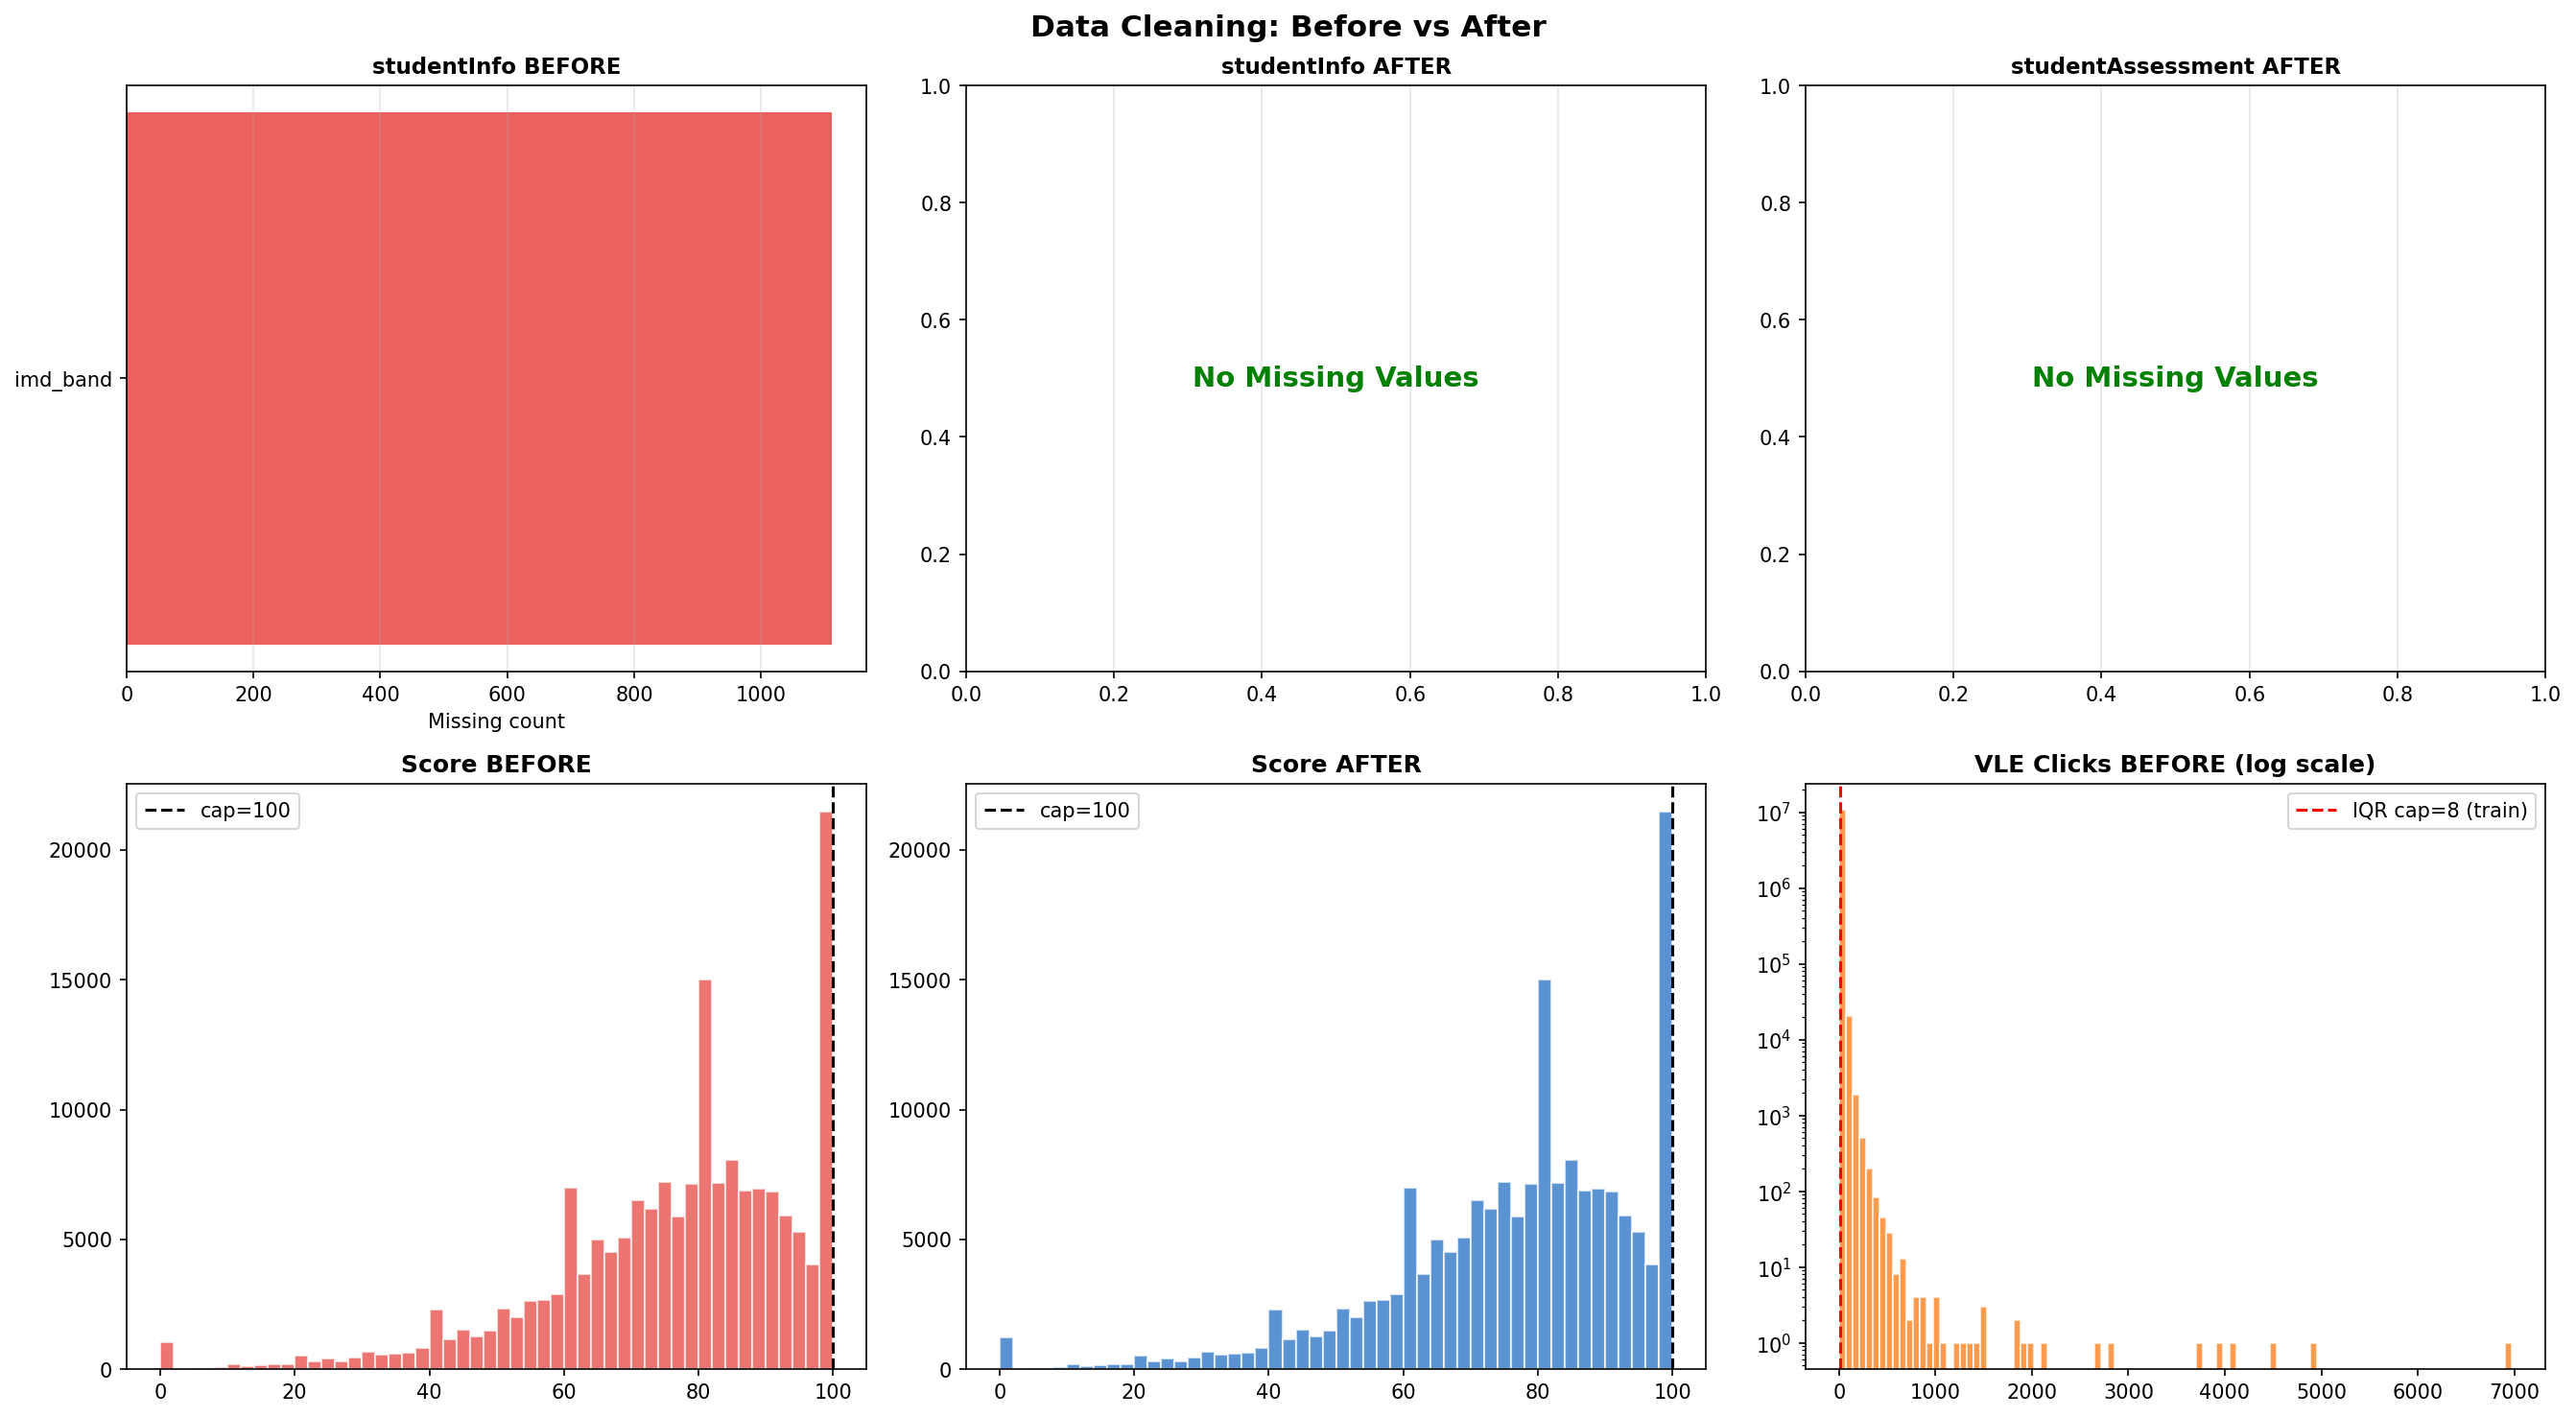

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 3 — DATA CLEANING  [LEAKAGE-CORRECTED VERSION]
# All imputation constants and clipping boundaries are estimated from the
# TRAINING presentations only, then applied to all rows.
# ════════════════════════════════════════════════════════════════════════════
info    = raw_info.copy();   assess  = raw_assess.copy()
vle     = raw_vle.copy();    asmeta  = raw_asmeta.copy()
vlemeta = raw_vlemeta.copy()

# ── Held-out presentation, defined BEFORE any statistic is computed ──────────
TEST_PRES = sorted(raw_info['code_presentation'].unique())[-1]      # -> '2014J'
print(f'Held-out test presentation: {TEST_PRES}')

def tr(df):
    """Boolean mask selecting training-pool rows (all presentations except TEST_PRES)."""
    return df['code_presentation'] != TEST_PRES

cleaning_log = []
def clog(action, table, n, detail=''):
    cleaning_log.append({'Action':action,'Table':table,'N_affected':n,'Detail':detail})
    print(f'  [{table}] {action}: {n:,}  | {detail}')

# STEP 1 — Duplicates
print('STEP 1: Duplicate removal')
for nm, df_r in [('info',info),('assess',assess),('vle',vle)]:
    n = len(df_r); df_r.drop_duplicates(inplace=True)
    clog('drop_duplicates', nm, n-len(df_r))

# STEP 2 — studentInfo categoricals
print('\nSTEP 2: studentInfo categoricals')
info['imd_band'] = info['imd_band'].astype(str).str.strip().str.replace(' ','')
def map_imd(val):
    s = str(val).lower()
    if s in ['nan','unknown','none','']: return np.nan
    try: lo=int(s.split('-')[0].replace('%','')); return max(1,min(10,lo//10+1))
    except: return np.nan
info['imd_band_ordinal'] = info['imd_band'].apply(map_imd)
n_nan_imd = info['imd_band_ordinal'].isna().sum()
imd_med   = info.loc[tr(info),'imd_band_ordinal'].median()          # [FIX] train only
info['imd_band_ordinal'] = info['imd_band_ordinal'].fillna(imd_med)
clog('imd_band->ordinal, NaN->median','info',n_nan_imd,f'median={imd_med} (train only)')
for col in ['gender','disability']:
    n = info[col].isna().sum()
    if n > 0:
        mode_tr = info.loc[tr(info),col].mode()[0]                  # [FIX] train only
        info[col] = info[col].fillna(mode_tr)
        clog(f'{col} NaN->mode','info',n,f'mode={mode_tr} (train only)')
valid_ages = ['0-35','35-55','55<=']
n_bad_age  = (~info['age_band'].isin(valid_ages)).sum()
age_mode_tr = info.loc[tr(info) & info['age_band'].isin(valid_ages),
                       'age_band'].mode()[0]                        # [FIX] train only
info.loc[~info['age_band'].isin(valid_ages),'age_band'] = age_mode_tr
clog('age_band invalid->mode','info',n_bad_age,f'mode={age_mode_tr} (train only)')
info_tr      = info.loc[tr(info)]                                   # [FIX] train only
thresh       = 0.01*len(info_tr)
rare_regions = info_tr['region'].value_counts()[lambda x: x<thresh].index.tolist()
n_rare       = info['region'].isin(rare_regions).sum()
info.loc[info['region'].isin(rare_regions),'region'] = 'Other'
clog('rare region->Other','info',n_rare,str(rare_regions)+' (train-derived)')

# STEP 3 — studentAssessment
print('\nSTEP 3: studentAssessment validation')
n_over  = (assess['score']>100).sum(); n_under = (assess['score']<0).sum()
assess.loc[assess['score']>100,'score'] = 100
assess.loc[assess['score']<0,  'score'] = 0
clog('score cap [0,100]','assess',n_over+n_under)
n_null = assess['score'].isna().sum()
assess['score'] = assess['score'].fillna(0)
clog('score NaN->0 (non-submission)','assess',n_null)
asmeta_cols = ['id_assessment','date','weight','assessment_type']
for c in ['code_module','code_presentation']:
    if c in asmeta.columns: asmeta_cols.append(c)
assess = assess.merge(asmeta[asmeta_cols], on='id_assessment', how='left')
assess['date_submitted'] = pd.to_numeric(assess['date_submitted'],errors='coerce')
assess['date']           = pd.to_numeric(assess['date'],errors='coerce')
n_null_dates = assess['date'].isna().sum()+assess['date_submitted'].isna().sum()
# [FIX] median of assessment due-date computed on training presentations only.
#       Must run AFTER the asmeta merge, which is what supplies code_presentation.
if 'code_presentation' in assess.columns:
    date_med_tr = assess.loc[tr(assess),'date'].median()
else:
    date_med_tr = assess['date'].median()
    print('  [warn] assess has no code_presentation; date median computed on all rows')
assess['date']           = assess['date'].fillna(date_med_tr)
assess['date_submitted'] = assess['date_submitted'].fillna(assess['date'])
clog('date/date_submitted NaN','assess',n_null_dates,
     f'median={date_med_tr} (train only) / due')
assess['days_early_late'] = assess['date']-assess['date_submitted']
assess['is_late']         = (assess['days_early_late']<0).astype(int)

# STEP 4 — studentVle
print('\nSTEP 4: studentVle validation')
n_neg2 = (vle['sum_click']<0).sum()
vle.loc[vle['sum_click']<0,'sum_click'] = 0
clog('sum_click<0->0','vle',n_neg2)
vle['sum_click'] = vle['sum_click'].fillna(0)
vle_tr    = vle.loc[tr(vle),'sum_click']                            # [FIX] train only
Q1,Q3     = vle_tr.quantile(0.25), vle_tr.quantile(0.75)
cap_upper = Q3+1.5*(Q3-Q1)
n_out     = (vle['sum_click']>cap_upper).sum()                      # applied to ALL rows
vle['sum_click'] = vle['sum_click'].clip(upper=cap_upper)
clog('sum_click IQR cap','vle',n_out,
     f'Q3+1.5IQR={cap_upper:.1f} (train presentations only)')
vle = vle.merge(raw_courses[['code_module','code_presentation','module_presentation_length']],
                on=['code_module','code_presentation'],how='left')
mpl_med_tr = vle.loc[tr(vle),'module_presentation_length'].median() # [FIX] train only
vle['module_presentation_length'] = vle['module_presentation_length'].fillna(mpl_med_tr)
n_bad_d = (vle['date']>vle['module_presentation_length']+30).sum()
vle     = vle[vle['date']<=vle['module_presentation_length']+30].copy()
clog('vle date > module_len+30 removed','vle',n_bad_d)
vle = vle.merge(vlemeta[['id_site','activity_type']],on='id_site',how='left')
vle['activity_type'] = vle['activity_type'].fillna('unknown')

# STEP 5 — Save log & plot
clean_df = pd.DataFrame(cleaning_log)
clean_df.to_csv(CSV_DIR/'data_cleaning_log.csv',index=False)
print(f'\nCleaning done. {len(clean_df)} operations logged.')

# ── Train-only statistics — record these for Section 3.4.1 of the thesis ────
print('\n--- Train-only statistics (report in Section 3.4.1) ---')
print(f'  Statistics estimated on : {sorted(set(raw_info["code_presentation"]))} minus {TEST_PRES}')
print(f'  IQR cap (sum_click)     : {cap_upper:.1f}')
print(f'  Rows clipped            : {n_out:,}')
print(f'  IMD ordinal median      : {imd_med}')
print(f'  Assessment date median  : {date_med_tr}')
print(f'  Rare regions merged     : {rare_regions}')

fig, axes = plt.subplots(2,3,figsize=(18,10))
for ax,df_p,title in [(axes[0][0],raw_info,'studentInfo BEFORE'),
                       (axes[0][1],info,   'studentInfo AFTER'),
                       (axes[0][2],assess, 'studentAssessment AFTER')]:
    miss = df_p.isnull().sum(); miss = miss[miss>0]
    if len(miss):
        ax.barh(miss.index,miss.values,color='#E53935',alpha=0.8); ax.set_xlabel('Missing count')
    else:
        ax.text(0.5,0.5,'No Missing Values',ha='center',va='center',transform=ax.transAxes,
                fontsize=14,color='green',fontweight='bold')
    ax.set_title(title,fontweight='bold',fontsize=11); ax.grid(axis='x',alpha=0.3)
axes[1][0].hist(raw_assess['score'].dropna(),bins=50,color='#E53935',alpha=0.7,edgecolor='white')
axes[1][0].axvline(100,color='black',ls='--',label='cap=100')
axes[1][0].set_title('Score BEFORE',fontweight='bold'); axes[1][0].legend()
axes[1][1].hist(assess['score'],bins=50,color='#1565C0',alpha=0.7,edgecolor='white')
axes[1][1].axvline(100,color='black',ls='--',label='cap=100')
axes[1][1].set_title('Score AFTER',fontweight='bold'); axes[1][1].legend()
axes[1][2].hist(raw_vle['sum_click'].clip(0),bins=100,color='#FF6F00',alpha=0.7,edgecolor='white')
axes[1][2].axvline(cap_upper,color='red',ls='--',label=f'IQR cap={cap_upper:.0f} (train)')
axes[1][2].set_title('VLE Clicks BEFORE (log scale)',fontweight='bold')
axes[1][2].set_yscale('log'); axes[1][2].legend()
plt.suptitle('Data Cleaning: Before vs After',fontsize=15,fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'data_cleaning_summary.png',dpi=150,bbox_inches='tight')
plt.show()

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 4 — EARLY WARNING WINDOW (30 days) + FEATURE ENGINEERING
# ════════════════════════════════════════════════════════════════════════════
EARLY_WINDOW = 30
print(f'Early Warning Mode: first {EARLY_WINDOW} days only')

info['target'] = info['final_result'].map(
    {'Fail':1,'Withdrawn':1,'Pass':0,'Distinction':0})
info.dropna(subset=['target'],inplace=True)
info['target'] = info['target'].astype(int)
print(f'Target: {info["target"].value_counts().to_dict()}  '
      f'at-risk={info["target"].mean()*100:.1f}%')

assess_early = assess[assess['date']<=EARLY_WINDOW].copy()
vle_early    = vle[vle['date']<=EARLY_WINDOW].copy()
print(f'assess rows: {len(assess)} -> {len(assess_early)}')
print(f'vle rows   : {len(vle)}    -> {len(vle_early)}')

def clean_suffix_cols(df):
    for cx in [c for c in df.columns if c.endswith('_x')]:
        base=cx[:-2]; cy=base+'_y'
        df[base]=df[cx].combine_first(df[cy]) if cy in df.columns else df[cx]
        df.drop(columns=[cx]+([cy] if cy in df.columns else []),inplace=True)
    return df

assess_early = clean_suffix_cols(assess_early)
if 'code_module' not in assess_early.columns or assess_early['code_module'].isna().all():
    sm = (info[['id_student','code_module','code_presentation']]
          .drop_duplicates(subset='id_student',keep='first'))
    assess_early = assess_early.merge(sm,on='id_student',how='left')
    assess_early = clean_suffix_cols(assess_early)
for col in ['code_module','code_presentation']:
    if assess_early[col].isna().any(): assess_early.dropna(subset=[col],inplace=True)
print(f'assess_early shape: {assess_early.shape}')

# ── Assessment features ───────────────────────────────────────────────────────
first_scores = (assess_early.sort_values('date')
    .groupby(['id_student','code_module','code_presentation'])['score']
    .first().reset_index().rename(columns={'score':'first_assessment_score'}))

def wtd_avg(g):
    w = g['weight'].fillna(1).replace(0,1)
    return np.average(g['score'],weights=w) if w.sum()>0 else g['score'].mean()

assess_feats = (assess_early.groupby(['id_student','code_module','code_presentation'])
    .apply(lambda g: pd.Series({
        'avg_assessment_score'     : g['score'].mean(),
        'std_assessment_score'     : g['score'].std(ddof=0),
        'min_assessment_score'     : g['score'].min(),
        'max_assessment_score'     : g['score'].max(),
        'num_assessments_completed': len(g),
        'pct_late_submissions'     : g['is_late'].mean(),
        'num_late_submissions'     : g['is_late'].sum(),
        'weighted_avg_score'       : wtd_avg(g),
        'avg_days_early'           : g['days_early_late'].mean(),
        'n_zeros'                  : (g['score']==0).sum(),
        'pct_zeros'                : (g['score']==0).mean(),
    }), include_groups=False).reset_index())
assess_feats = assess_feats.merge(first_scores,
    on=['id_student','code_module','code_presentation'],how='left').fillna(0)

# ── VLE features ──────────────────────────────────────────────────────────────
week1  = (vle_early[vle_early['date']<=7]
    .groupby(['id_student','code_module','code_presentation'])['sum_click']
    .sum().reset_index().rename(columns={'sum_click':'clicks_week_1'}))
week2  = (vle_early[(vle_early['date']>7)&(vle_early['date']<=14)]
    .groupby(['id_student','code_module','code_presentation'])['sum_click']
    .sum().reset_index().rename(columns={'sum_click':'clicks_week_2'}))
divers = (vle_early.groupby(['id_student','code_module','code_presentation'])['activity_type']
    .nunique().reset_index().rename(columns={'activity_type':'activity_diversity'}))
max_d  = (vle_early.groupby(['id_student','code_module','code_presentation'])['date']
    .max().reset_index().rename(columns={'date':'max_date'}))
vle2   = vle_early.merge(max_d,on=['id_student','code_module','code_presentation'],how='left')
vle2['half'] = np.where(vle2['date']<=vle2['max_date']/2,'first','second')
half   = (vle2.groupby(['id_student','code_module','code_presentation','half'])['sum_click']
    .sum().unstack(fill_value=0).reset_index())
half.columns.name = None
for c in ['first','second']:
    if c not in half.columns: half[c]=0
half['engagement_trend'] = half['second']/(half['first']+1)

vle_feats = (vle_early.groupby(['id_student','code_module','code_presentation'])
    .apply(lambda g: pd.Series({
        'total_clicks'      : g['sum_click'].sum(),
        'num_active_days'   : g['date'].nunique(),
        'avg_clicks_per_day': g['sum_click'].mean(),
        'max_clicks_day'    : g['sum_click'].max(),
        'std_clicks'        : g['sum_click'].std(ddof=0),
        'last_active_day'   : g['date'].max(),
        'first_active_day'  : g['date'].min(),
        'n_sessions'        : len(g),
    }), include_groups=False).reset_index())
vle_feats['active_span']   = vle_feats['last_active_day']-vle_feats['first_active_day']
vle_feats['late_start']    = (vle_feats['first_active_day']>14).astype(int)
vle_feats['early_dropout'] = (vle_feats['last_active_day']<20).astype(int)
for ex in [week1,week2,divers,
           half[['id_student','code_module','code_presentation','engagement_trend']]]:
    vle_feats = vle_feats.merge(ex,on=['id_student','code_module','code_presentation'],how='left')
vle_feats = vle_feats.fillna(0)

print(f'Assessment features: {assess_feats.shape[1]-3}')
print(f'VLE features       : {vle_feats.shape[1]-3}')


Early Warning Mode: first 30 days only
Target: {1: 17208, 0: 15385}  at-risk=52.8%
assess rows: 173912 -> 22043
vle rows   : 9868110    -> 2796330
assess_early shape: (22043, 12)
Assessment features: 12
VLE features       : 15


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 5 — MERGE, ENCODE & TEMPORAL SPLIT  [LEAKAGE-CORRECTED VERSION]
# ════════════════════════════════════════════════════════════════════════════
df = info.merge(assess_feats,on=['id_student','code_module','code_presentation'],how='left')
df = df.merge(vle_feats,    on=['id_student','code_module','code_presentation'],how='left')
for col in vle_feats.columns.drop(['id_student','code_module','code_presentation']):
    df[col] = df[col].fillna(0)
for col in assess_feats.columns.drop(['id_student','code_module','code_presentation']):
    df[col] = df[col].fillna(0)

nan_check = df.isnull().sum()
print('NaN audit:','PASSED' if not nan_check[nan_check>0].any() else nan_check[nan_check>0])
num_cols  = df.select_dtypes(include=np.number).columns
inf_check = np.isinf(df[num_cols]).sum()
if inf_check[inf_check>0].any():
    df[num_cols] = df[num_cols].replace([np.inf,-np.inf],0); print('Inf replaced')
else: print('Inf audit: PASSED')
print(f'Dataset: {df.shape[0]:,} students x {df.shape[1]} cols')

if 'imd_band' in df.columns: df.drop(columns=['imd_band'],inplace=True)
CAT_COLS = [c for c in ['gender','age_band','disability','highest_education',
                         'region','code_module'] if c in df.columns]
for c in CAT_COLS: df[c] = df[c].fillna('Unknown').astype(str)
df_enc = pd.get_dummies(df,columns=CAT_COLS,drop_first=False,dtype=int)
DROP   = [c for c in ['id_student','code_presentation','final_result',
                       'date_registration','date_unregistration',
                       'id_presentation','module_presentation_length'] if c in df_enc.columns]
df_enc.drop(columns=DROP,inplace=True)

X = df_enc.drop(columns=['target'])
y = df_enc['target']
FEATURE_NAMES = list(X.columns)
print(f'Feature matrix: {X.shape[0]:,} x {X.shape[1]}')

# Temporal split
if 'code_presentation' in df.columns:
    pres_values = df['code_presentation'].values
    unique_pres = sorted(set(pres_values))
    print(f'Presentations: {unique_pres}')
    test_pres  = unique_pres[-1]
    train_mask = np.array([p!=test_pres for p in pres_values])
    test_mask  = ~train_mask
    X_train = X[train_mask];  X_test = X[test_mask]
    y_train = pd.Series(y.values[train_mask],name='target')
    y_test  = pd.Series(y.values[test_mask], name='target')
    print(f'Temporal split | Test presentation: {test_pres}')
    # [FIX] the split rule must match the rule used for cleaning statistics in Cell 3
    assert test_pres == TEST_PRES, (
        f'Split presentation ({test_pres}) differs from the presentation used for '
        f'cleaning statistics ({TEST_PRES}) - statistics would leak into the test set.'
    )
else:
    X_train,X_test,y_train,y_test = train_test_split(
        X,y,test_size=0.2,stratify=y,random_state=SEED)

y_train_arr = np.array(y_train,dtype=np.int64)
y_test_arr  = np.array(y_test, dtype=np.int64)
print(f'Train: {X_train.shape}  at-risk={y_train.mean()*100:.1f}%')
print(f'Test : {X_test.shape}   at-risk={y_test.mean()*100:.1f}%')

# [FIX] cache the split so later re-analysis (e.g. the cohort table for Section 4.1)
#       never requires retraining the models
import joblib
joblib.dump({'X_train': X_train, 'X_test': X_test,
             'y_train': y_train, 'y_test': y_test,
             'TEST_PRES': TEST_PRES},
            CSV_DIR/'split_cache.joblib')
print('Split cached ->', CSV_DIR/'split_cache.joblib')

NaN audit: PASSED
Inf audit: PASSED
Dataset: 32,593 students x 41 cols
Feature matrix: 32,593 x 62
Presentations: ['2013B', '2013J', '2014B', '2014J']
Temporal split | Test presentation: 2014J
Train: (21333, 62)  at-risk=53.5%
Test : (11260, 62)   at-risk=51.5%
Split cached -> results_XGB/split_cache.joblib


═══════════════════════════════════════════════════════
CLASS IMBALANCE SUMMARY
═══════════════════════════════════════════════════════
  Negative (Success) : 9,928  (46.5%)
  Positive (At-Risk) : 11,405  (53.5%)
  Imbalance ratio    : 0.87:1
  scale_pos_weight   : 0.8705  (XGBoost)
  Strategy (others)  : class_weight="balanced"
═══════════════════════════════════════════════════════


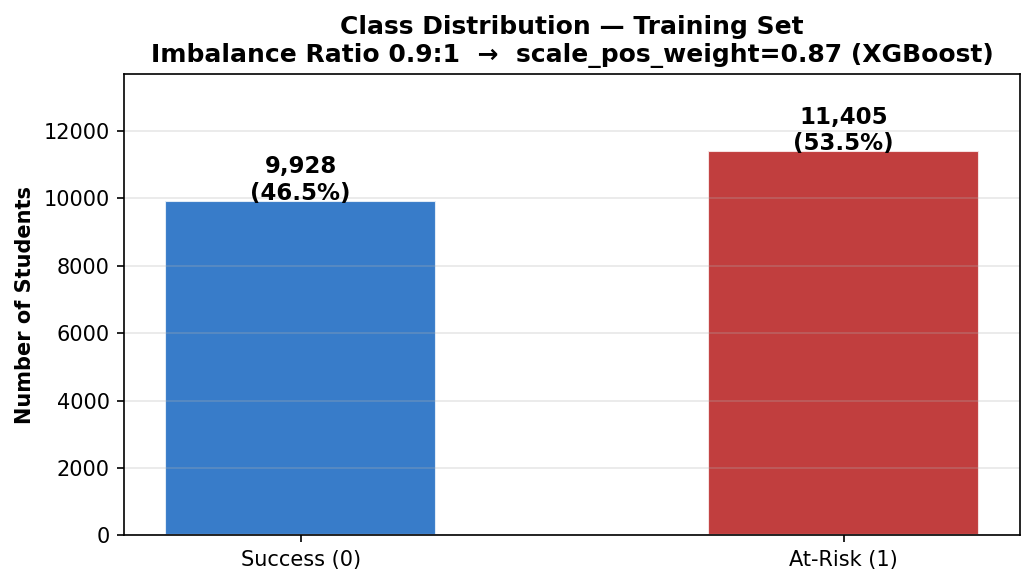

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 6 — CLASS IMBALANCE ANALYSIS & scale_pos_weight COMPUTATION
# ════════════════════════════════════════════════════════════════════════════
n_neg_cls = int((y_train==0).sum())
n_pos_cls = int((y_train==1).sum())
spw       = n_neg_cls / n_pos_cls

print('═'*55)
print('CLASS IMBALANCE SUMMARY')
print('═'*55)
print(f'  Negative (Success) : {n_neg_cls:,}  ({n_neg_cls/(n_neg_cls+n_pos_cls)*100:.1f}%)')
print(f'  Positive (At-Risk) : {n_pos_cls:,}  ({n_pos_cls/(n_neg_cls+n_pos_cls)*100:.1f}%)')
print(f'  Imbalance ratio    : {spw:.2f}:1')
print(f'  scale_pos_weight   : {spw:.4f}  (XGBoost)')
print(f'  Strategy (others)  : class_weight="balanced"')
print('═'*55)

fig,ax = plt.subplots(figsize=(7,4))
bars = ax.bar(['Success (0)','At-Risk (1)'],[n_neg_cls,n_pos_cls],
              color=['#1565C0','#B71C1C'],alpha=0.85,edgecolor='white',width=0.5)
for bar,val in zip(bars,[n_neg_cls,n_pos_cls]):
    ax.text(bar.get_x()+bar.get_width()/2,val+30,
            f'{val:,}\n({val/(n_neg_cls+n_pos_cls)*100:.1f}%)',
            ha='center',fontsize=11,fontweight='bold')
ax.set_ylabel('Number of Students',fontweight='bold')
ax.set_title(f'Class Distribution — Training Set\n'
             f'Imbalance Ratio {spw:.1f}:1  →  scale_pos_weight={spw:.2f} (XGBoost)',
             fontweight='bold')
ax.grid(axis='y',alpha=0.3); ax.set_ylim(0,max(n_neg_cls,n_pos_cls)*1.2)
plt.tight_layout()
plt.savefig(FIGURES_DIR/'class_distribution.png',dpi=150,bbox_inches='tight')
plt.show()


MI selected:       17 features
ANOVA selected:    14 features
Spearman selected: 16 features

Auto-selected (≥2 methods agree): 16 features
                        MI_Rank  ANOVA_Rank  Spearman_Rank  Vote_Count  Avg_Rank
num_active_days               1           3              1           3    1.6667
last_active_day               2           1              2           3    1.6667
min_assessment_score          7           4              7           3    6.0000
active_span                   5           2             11           3    6.0000
total_clicks                  3          14              3           3    6.6667
n_sessions                    4          13              4           3    7.0000
avg_assessment_score         10           6              5           3    7.0000
first_assessment_score        9           5              8           3    7.3333
max_assessment_score          8           8              9           3    8.3333
weighted_avg_score           12           7       

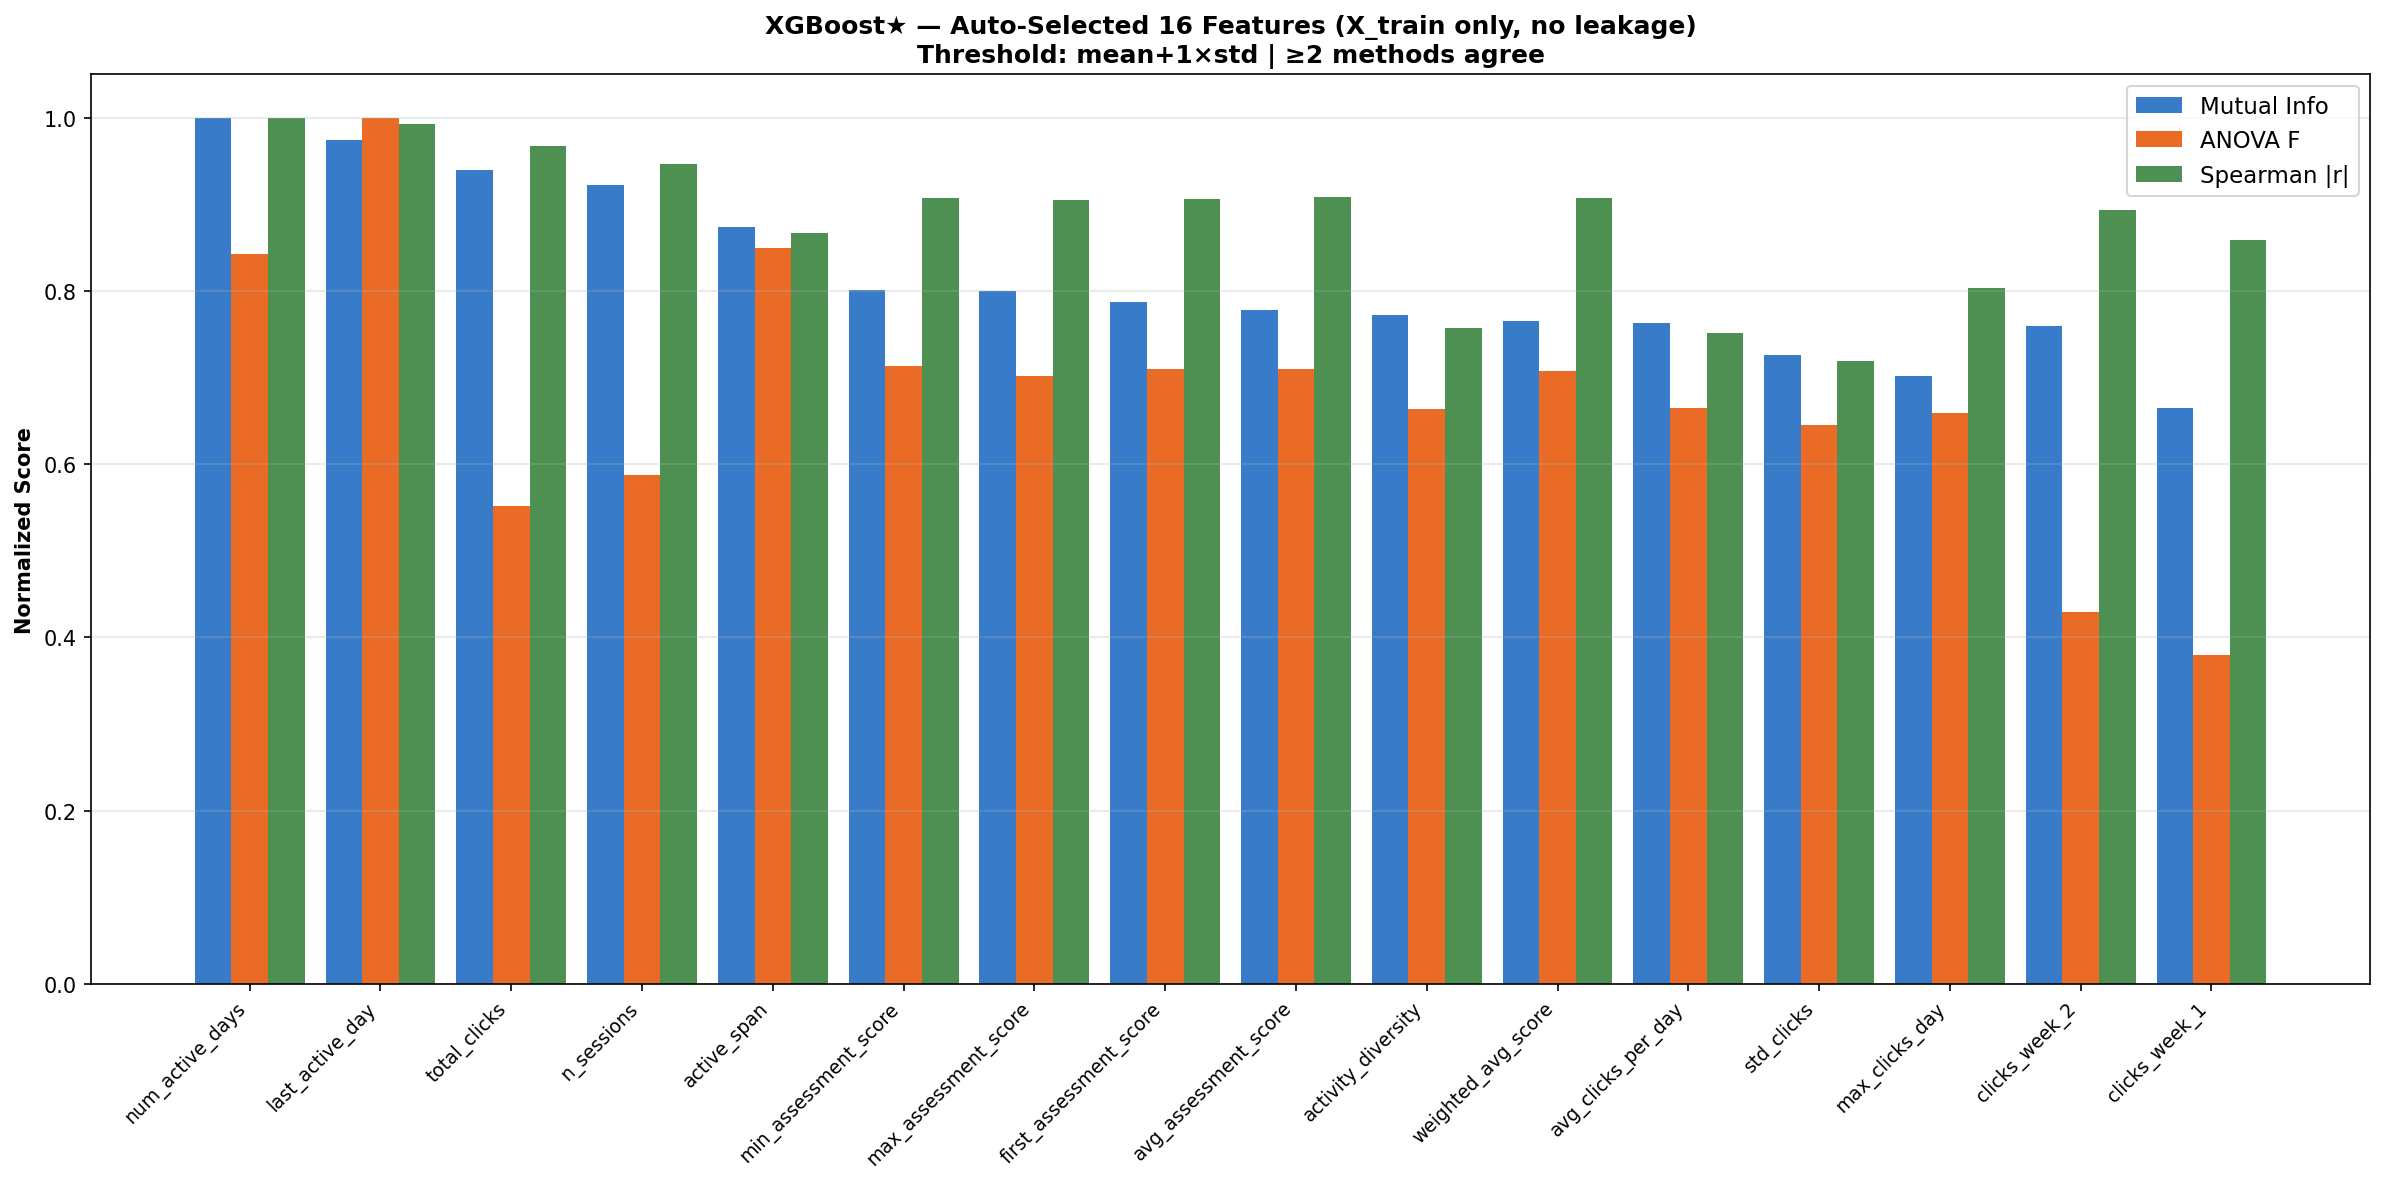

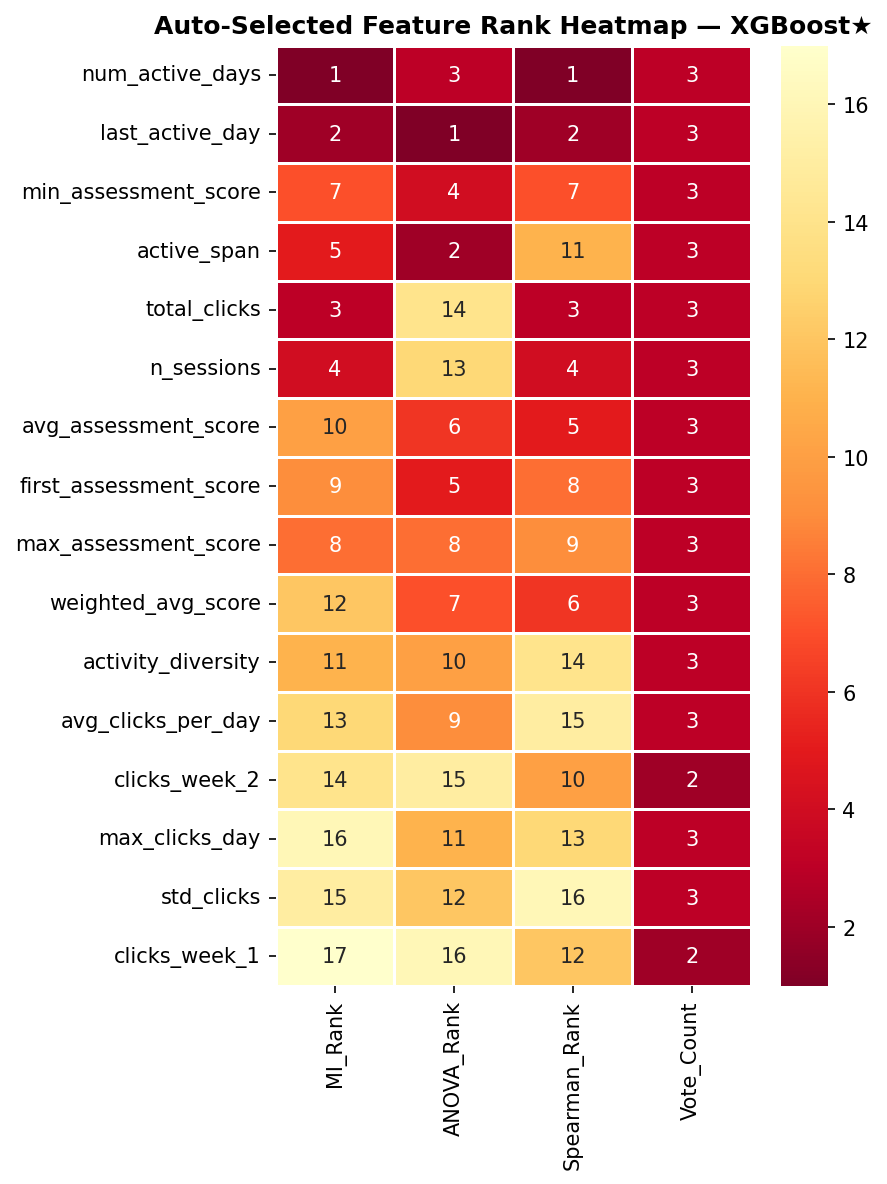

Feature selection done.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 7 — FEATURE SELECTION  (X_train only — no data leakage)
# Three complementary filters: MI, ANOVA F, Spearman |r|
# Auto-threshold: mean + 1×std per method  |  consensus ≥ 2 methods
# ════════════════════════════════════════════════════════════════════════════
mi_scores = mutual_info_classif(X_train,y_train,random_state=SEED)
mi_series = pd.Series(mi_scores,index=FEATURE_NAMES).sort_values(ascending=False)

f_scores,_ = f_classif(X_train,y_train)
f_series   = pd.Series(f_scores,index=FEATURE_NAMES).sort_values(ascending=False)

sp_scores = {col:abs(spearmanr(X_train[col],y_train)[0]) for col in FEATURE_NAMES}
sp_series = pd.Series(sp_scores).sort_values(ascending=False)

mi_sel = mi_series[mi_series >= mi_series.mean()+mi_series.std()].index.tolist()
f_sel  = f_series[f_series   >= f_series.mean() +f_series.std() ].index.tolist()
sp_sel = sp_series[sp_series >= sp_series.mean()+sp_series.std()].index.tolist()

print(f'MI selected:       {len(mi_sel)} features')
print(f'ANOVA selected:    {len(f_sel)} features')
print(f'Spearman selected: {len(sp_sel)} features')

vote_count = Counter(mi_sel+f_sel+sp_sel)
auto_top   = [f for f,c in vote_count.items() if c>=2]
auto_top   = sorted(auto_top,key=lambda f:vote_count[f],reverse=True)
TOP_N      = len(auto_top); top_feats = auto_top

rank_table = pd.DataFrame({
    'MI_Rank'      :[list(mi_series.index).index(f)+1 for f in auto_top],
    'ANOVA_Rank'   :[list(f_series.index).index(f)+1  for f in auto_top],
    'Spearman_Rank':[list(sp_series.index).index(f)+1 for f in auto_top],
    'Vote_Count'   :[vote_count[f] for f in auto_top],
},index=auto_top)
rank_table['Avg_Rank'] = rank_table[['MI_Rank','ANOVA_Rank','Spearman_Rank']].mean(axis=1)
rank_table = rank_table.sort_values('Avg_Rank')
rank_table.to_csv(CSV_DIR/'feature_ranking_XGB.csv')
print(f'\nAuto-selected (≥2 methods agree): {TOP_N} features')
print(rank_table[['MI_Rank','ANOVA_Rank','Spearman_Rank','Vote_Count','Avg_Rank']].to_string())

def norm(s): return (s-s.min())/(s.max()-s.min()+1e-9)
comp_df = pd.DataFrame({
    'Mutual Info' :norm(mi_series)[top_feats],
    'ANOVA F'     :norm(f_series)[top_feats],
    'Spearman |r|':norm(sp_series)[top_feats],
}).fillna(0)

fig,ax = plt.subplots(figsize=(max(14,len(top_feats)),8))
x = np.arange(len(top_feats)); w = 0.28
for i,(col,color) in enumerate(zip(comp_df.columns,['#1565C0','#E65100','#2E7D32'])):
    ax.bar(x+i*w,comp_df[col],width=w,label=col,color=color,alpha=0.85)
ax.set_xticks(x+w)
ax.set_xticklabels([f[:22] for f in top_feats],rotation=45,ha='right',fontsize=9)
ax.set_ylabel('Normalized Score',fontweight='bold')
ax.set_title(f'XGBoost★ — Auto-Selected {TOP_N} Features (X_train only, no leakage)\n'
             f'Threshold: mean+1×std | ≥2 methods agree',fontsize=12,fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR/'feature_importance_XGB.png',dpi=150,bbox_inches='tight')
plt.show()

# Heatmap
fig,ax = plt.subplots(figsize=(6,max(6,len(top_feats)*0.5)))
sns.heatmap(rank_table.sort_values('Avg_Rank')[['MI_Rank','ANOVA_Rank','Spearman_Rank','Vote_Count']],
            annot=True,fmt='.0f',cmap='YlOrRd_r',linewidths=0.5,ax=ax)
ax.set_title('Auto-Selected Feature Rank Heatmap — XGBoost★',fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'feature_rank_heatmap_XGB.png',dpi=150,bbox_inches='tight')
plt.show()
print('Feature selection done.')


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 8 — MODEL TRAINING  (Class-Imbalance Aware)
# PRIMARY: XGBoost  |  Baseline: Logistic Regression  |  Supporting: DT, RF, SVM
# ════════════════════════════════════════════════════════════════════════════
def build_pipeline(clf):
    return Pipeline([('imp',SimpleImputer(strategy='median')),
                     ('scl',StandardScaler()),
                     ('clf',clf)])

def evaluate(pipe, Xt, yt, name):
    yp  = pipe.predict(Xt)
    ypr = pipe.predict_proba(Xt)[:,1]
    yt_arr = np.array(yt,dtype=np.int64)
    return {
        'Model'        : name,
        'Accuracy'     : accuracy_score(yt_arr,yp),
        'Precision_W'  : precision_score(yt_arr,yp,average='weighted',zero_division=0),
        'Recall_W'     : recall_score(yt_arr,yp,average='weighted',zero_division=0),
        'F1_W'         : f1_score(yt_arr,yp,average='weighted',zero_division=0),
        'Precision_M'  : precision_score(yt_arr,yp,average='macro',zero_division=0),
        'Recall_M'     : recall_score(yt_arr,yp,average='macro',zero_division=0),
        'F1_M'         : f1_score(yt_arr,yp,average='macro',zero_division=0),
        'AUC_ROC'      : roc_auc_score(yt_arr,ypr),
        'Cohen_Kappa'  : cohen_kappa_score(yt_arr,yp),
        'MCC'          : matthews_corrcoef(yt_arr,yp),
        'Brier_Score'  : brier_score_loss(yt_arr,ypr),
        'Log_Loss'     : log_loss(yt_arr,ypr),
        'Avg_Precision': average_precision_score(yt_arr,ypr),
    }, yp, ypr

# ── Feature Selection Filter ─────────────────────────────────────────────
# Train and evaluate all models ONLY on the consensus features selected
# by ≥2 methods (MI ∩ ANOVA ∩ Spearman)
# This avoids training on noisy/irrelevant features and ensures that
# feature selection is applied consistently across all 5 classifiers.
X_train_sel = X_train[top_feats].reset_index(drop=True)
X_test_sel  = X_test[top_feats].reset_index(drop=True)
FEATURE_NAMES_SEL = top_feats
print(f'Feature-selected training: {X_train_sel.shape[1]} features '
      f'(from {X_train.shape[1]} total, consensus ≥2 methods)')

# Global preprocessors fitted on selected features (needed for SHAP/LIME alignment)
imp_global = SimpleImputer(strategy='median')
scl_global = StandardScaler()
imp_global.fit(X_train_sel); scl_global.fit(imp_global.transform(X_train_sel))

MODEL_CONFIGS = {
    'XGBoost': {
        'pipe': build_pipeline(XGBClassifier(
            random_state=SEED, eval_metric='logloss', n_jobs=-1,
            scale_pos_weight=spw)),           # ← class imbalance correction
        'params': {'clf__n_estimators':[100,200],'clf__max_depth':[4,6],
                   'clf__learning_rate':[0.05,0.1],'clf__subsample':[0.8,1.0]},
        'is_primary': True,
    },
    'Logistic Regression': {
        'pipe': build_pipeline(LogisticRegression(
            random_state=SEED,max_iter=1000,solver='saga',
            class_weight='balanced')),
        'params': {'clf__C':[0.01,0.1,1,10],'clf__penalty':['l1','l2']},
        'is_primary': False,
    },
    'Decision Tree': {
        'pipe': build_pipeline(DecisionTreeClassifier(
            random_state=SEED,class_weight='balanced')),
        'params': {'clf__max_depth':[5,10,15,None],
                   'clf__min_samples_split':[2,10,20],
                   'clf__criterion':['gini','entropy']},
        'is_primary': False,
    },
    'Random Forest': {
        'pipe': build_pipeline(RandomForestClassifier(
            random_state=SEED,n_jobs=-1,class_weight='balanced')),
        'params': {'clf__n_estimators':[100,200],
                   'clf__max_depth':[10,20,None],
                   'clf__min_samples_split':[2,5]},
        'is_primary': False,
    },
    'SVM': {
        'pipe': build_pipeline(SVC(
            random_state=SEED,probability=True,class_weight='balanced')),
        'params': {'clf__C':[0.1,1,10],'clf__kernel':['rbf','linear'],
                   'clf__gamma':['scale','auto']},
        'is_primary': False,
    },
}

cv               = StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED)
trained_models   = {}
performance_rows = []

for name,cfg in MODEL_CONFIGS.items():
    tag = ' ★ PRIMARY' if cfg['is_primary'] else ''
    print(f'\n{name}{tag} …')
    t0 = time.time()
    gs = GridSearchCV(cfg['pipe'],cfg['params'],cv=cv,
                      scoring='roc_auc',n_jobs=-1,refit=True,verbose=0)
    gs.fit(X_train_sel,y_train)
    elapsed = time.time()-t0
    best = gs.best_estimator_
    trained_models[name] = best
    joblib.dump(best,MODELS_DIR/f'{name.replace(" ","_")}.pkl')
    res,_,_ = evaluate(best,X_test_sel,y_test,name)
    res.update({'CV_AUC':gs.best_score_,'Time_s':elapsed,
                'Best_Params':str(gs.best_params_)})
    performance_rows.append(res)
    print(f'  CV={gs.best_score_:.4f}  AUC={res["AUC_ROC"]:.4f}  '
          f'F1={res["F1_W"]:.4f}  Kappa={res["Cohen_Kappa"]:.4f}  [{elapsed:.0f}s]')

print('\nAll models trained.')
primary_model = trained_models['XGBoost']


Feature-selected training: 16 features (from 62 total, consensus ≥2 methods)

XGBoost ★ PRIMARY …
  CV=0.8084  AUC=0.8034  F1=0.7228  Kappa=0.4486  [28s]

Logistic Regression …
  CV=0.7707  AUC=0.7690  F1=0.6892  Kappa=0.3842  [23s]

Decision Tree …
  CV=0.7823  AUC=0.7807  F1=0.6979  Kappa=0.4012  [17s]

Random Forest …
  CV=0.8063  AUC=0.8028  F1=0.7203  Kappa=0.4439  [237s]

SVM …
  CV=0.7924  AUC=0.7826  F1=0.7221  Kappa=0.4540  [3524s]

All models trained.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 9 — ENSEMBLE METHODS
# Soft Voting (LR+RF+XGB+DT) | Stacking (all 5 → LR meta)
# ════════════════════════════════════════════════════════════════════════════
voting = VotingClassifier(
    estimators=[('lr',trained_models['Logistic Regression']),
                ('rf',trained_models['Random Forest']),
                ('xg',trained_models['XGBoost']),
                ('dt',trained_models['Decision Tree'])],
    voting='soft',n_jobs=-1)
voting.fit(X_train_sel,y_train)
r_v,_,_ = evaluate(voting,X_test_sel,y_test,'Voting Ensemble')
performance_rows.append(r_v)
trained_models['Voting Ensemble'] = voting
joblib.dump(voting,MODELS_DIR/'Voting_Ensemble.pkl')
print(f'Voting   AUC={r_v["AUC_ROC"]:.4f}  F1={r_v["F1_W"]:.4f}')

stacking_pipe = Pipeline([
    ('imp',SimpleImputer(strategy='median')),
    ('scl',StandardScaler()),
    ('clf',StackingClassifier(
        estimators=[
            ('lr', LogisticRegression(C=1,max_iter=1000,random_state=SEED,class_weight='balanced')),
            ('rf', RandomForestClassifier(n_estimators=100,random_state=SEED,n_jobs=-1,class_weight='balanced')),
            ('xgb',XGBClassifier(n_estimators=100,random_state=SEED,eval_metric='logloss',
                                  n_jobs=-1,scale_pos_weight=spw)),
            ('dt', DecisionTreeClassifier(max_depth=10,random_state=SEED,class_weight='balanced')),
            ('svm',SVC(probability=True,kernel='rbf',random_state=SEED,class_weight='balanced')),
        ],
        final_estimator=LogisticRegression(C=1,random_state=SEED,max_iter=1000),
        cv=5,n_jobs=-1)
)])
stacking_pipe.fit(X_train_sel,y_train)
r_s,_,_ = evaluate(stacking_pipe,X_test_sel,y_test,'Stacking Ensemble')
performance_rows.append(r_s)
trained_models['Stacking Ensemble'] = stacking_pipe
joblib.dump(stacking_pipe,MODELS_DIR/'Stacking_Ensemble.pkl')
print(f'Stacking AUC={r_s["AUC_ROC"]:.4f}  F1={r_s["F1_W"]:.4f}')

perf_df = pd.DataFrame(performance_rows)
perf_df.to_csv(CSV_DIR/'model_performance_XGB.csv',index=False)
print('\n── Standard Metrics (sorted by AUC-ROC) ──')
print(perf_df[['Model','Accuracy','F1_W','F1_M','AUC_ROC']]
      .sort_values('AUC_ROC',ascending=False).to_string(index=False))
print('\n── Extended Metrics ──')
print(perf_df[['Model','Cohen_Kappa','MCC','Brier_Score','Avg_Precision']]
      .sort_values('Cohen_Kappa',ascending=False).to_string(index=False))


Voting   AUC=0.8008  F1=0.7154
Stacking AUC=0.7977  F1=0.7197

── Standard Metrics (sorted by AUC-ROC) ──
              Model  Accuracy   F1_W   F1_M  AUC_ROC
            XGBoost    0.7234 0.7228 0.7231   0.8034
      Random Forest    0.7210 0.7203 0.7206   0.8028
    Voting Ensemble    0.7163 0.7154 0.7158   0.8008
  Stacking Ensemble    0.7202 0.7197 0.7199   0.7977
                SVM    0.7252 0.7221 0.7229   0.7826
      Decision Tree    0.6993 0.6979 0.6984   0.7807
Logistic Regression    0.6908 0.6892 0.6898   0.7690

── Extended Metrics ──
              Model  Cohen_Kappa    MCC  Brier_Score  Avg_Precision
                SVM       0.4540 0.4682       0.1856         0.8020
            XGBoost       0.4486 0.4525       0.1786         0.8334
      Random Forest       0.4439 0.4482       0.1789         0.8311
  Stacking Ensemble       0.4419 0.4451       0.1850         0.8298
    Voting Ensemble       0.4344 0.4389       0.1797         0.8308
      Decision Tree       0.4012 0.407

══════════════════════════════════════════════════════════════
McNemar's Test — XGBoost★ PRIMARY vs Logistic Regression BASELINE
══════════════════════════════════════════════════════════════
  b  (XGB correct, LR wrong) = 1,125
  c  (XGB wrong, LR correct) = 757
  χ² statistic               = 71.5670
  p-value                    = 0.000000
  → Significant (p < 0.05): XGBoost and LR make systematically
    different errors — performance difference is statistically real.

Bootstrap 95% CI for AUC-ROC  (N=1000, stratified, reproducible)
══════════════════════════════════════════════════════════════
  XGBoost                ★
    AUC = 0.8033 | 95% CI: [0.7946, 0.8112] | width = 0.0166
  Logistic Regression     (baseline)
    AUC = 0.7689 | 95% CI: [0.7603, 0.7774] | width = 0.0171
  Decision Tree         
    AUC = 0.7808 | 95% CI: [0.7722, 0.7895] | width = 0.0173
  Random Forest         
    AUC = 0.8028 | 95% CI: [0.7942, 0.8107] | width = 0.0164
  SVM                   
    AUC = 0.7

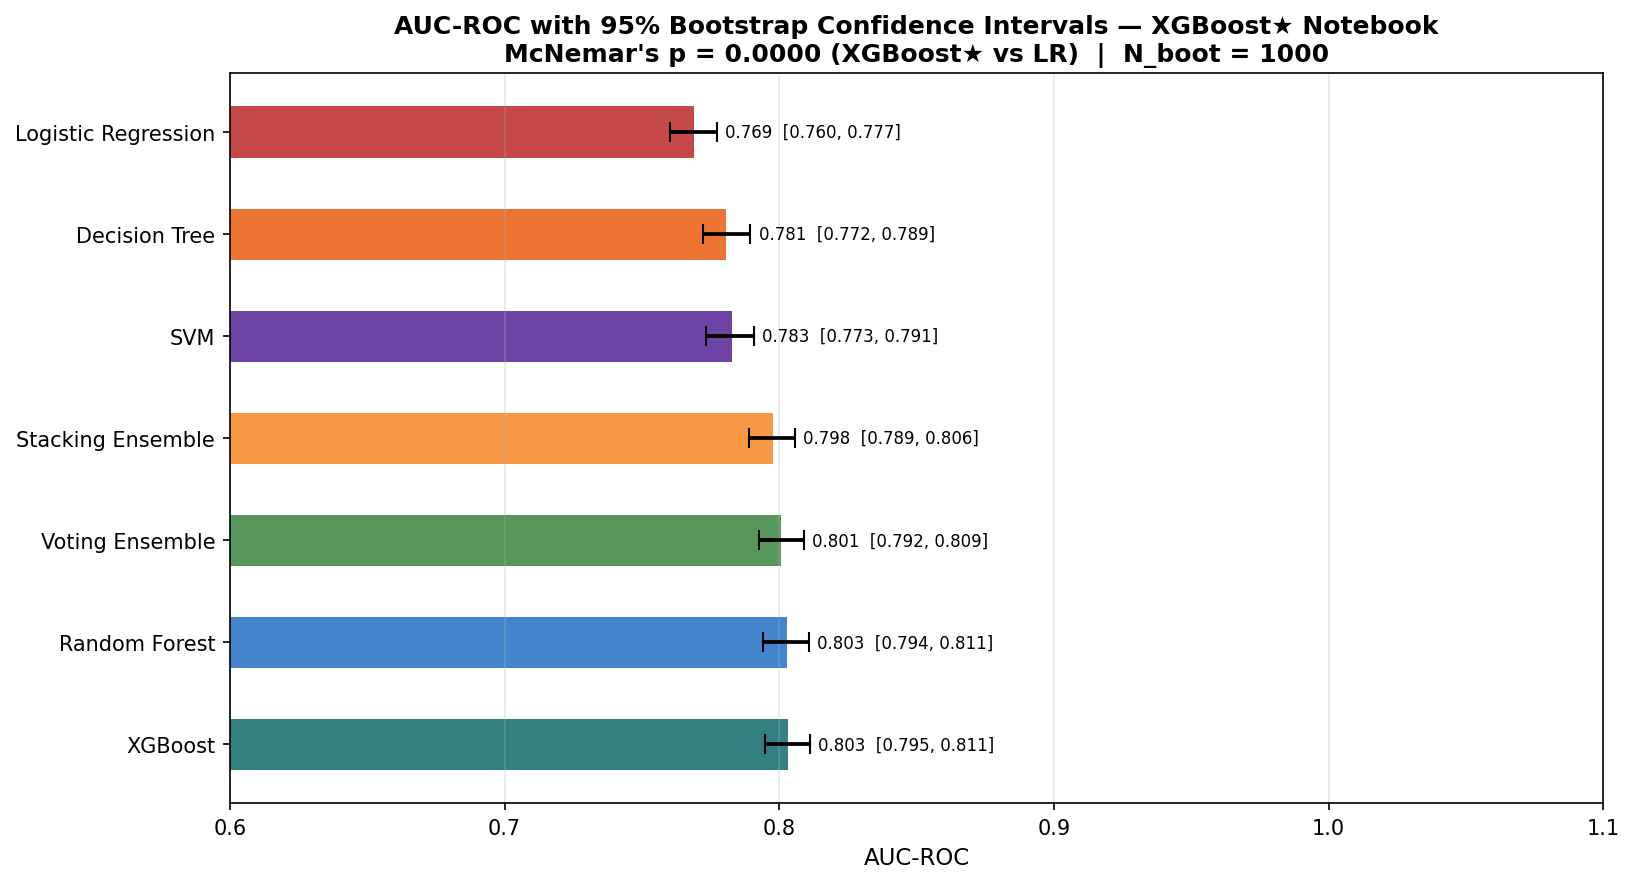

Statistical tests saved.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 9b — STATISTICAL SIGNIFICANCE TESTS + BOOTSTRAP CONFIDENCE INTERVALS

# ════════════════════════════════════════════════════════════════════════════
from statsmodels.stats.contingency_tables import mcnemar

# ── 1. McNemar's Test: XGBoost★ vs Logistic Regression ───────────────────
y_pred_xgb_mc = trained_models['XGBoost'].predict(X_test_sel)
y_pred_lr_mc  = trained_models['Logistic Regression'].predict(X_test_sel)

correct_xgb = (y_pred_xgb_mc == y_test_arr)
correct_lr  = (y_pred_lr_mc  == y_test_arr)

# b = XGB correct & LR wrong | c = XGB wrong & LR correct
b = int(( correct_xgb & ~correct_lr).sum())
c = int((~correct_xgb &  correct_lr).sum())

mc_result = mcnemar([[0, b], [c, 0]], exact=False, correction=True)

print('═' * 62)
print("McNemar's Test — XGBoost★ PRIMARY vs Logistic Regression BASELINE")
print('═' * 62)
print(f'  b  (XGB correct, LR wrong) = {b:,}')
print(f'  c  (XGB wrong, LR correct) = {c:,}')
print(f'  χ² statistic               = {mc_result.statistic:.4f}')
print(f'  p-value                    = {mc_result.pvalue:.6f}')
if mc_result.pvalue < 0.05:
    print('  → Significant (p < 0.05): XGBoost and LR make systematically')
    print('    different errors — performance difference is statistically real.')
else:
    print('  → Not significant (p ≥ 0.05): error patterns are similar.')
print()

# ── 2. Bootstrap CI 95% for AUC-ROC — All 7 Models ───────────────────────
def bootstrap_auc_ci(y_true, y_prob, n_boot=1000, ci=95, seed=42):
    """
    Stratified bootstrap percentile CI for AUC-ROC.
    random_state=seed+i ensures full reproducibility (RQ2: reproducible framework).
    Reference: Efron & Hastie (2016). Computer Age Statistical Inference.
    """
    from sklearn.utils import resample as _resample
    aucs, idx_all = [], np.arange(len(y_true))
    for i in range(n_boot):
        idx = _resample(idx_all, stratify=y_true, random_state=seed + i)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    lo = np.percentile(aucs, (100 - ci) / 2)
    hi = np.percentile(aucs, 100 - (100 - ci) / 2)
    return float(np.mean(aucs)), float(lo), float(hi)

N_BOOT_CI = 1000
print(f'Bootstrap 95% CI for AUC-ROC  (N={N_BOOT_CI}, stratified, reproducible)')
print('═' * 62)

ci_rows = []
for mname, mdl in trained_models.items():
    yp = mdl.predict_proba(X_test_sel)[:, 1]
    mean_auc, lo, hi = bootstrap_auc_ci(y_test_arr, yp,
                                         n_boot=N_BOOT_CI, seed=SEED)
    ci_rows.append({'Model': mname, 'AUC_Mean': mean_auc,
                    'CI_Low': lo, 'CI_High': hi, 'CI_Width': hi - lo})
    tag = ' ★' if mname == 'XGBoost' else ('  (baseline)' if mname == 'Logistic Regression' else '')
    print(f'  {mname:<22}{tag}')
    print(f'    AUC = {mean_auc:.4f} | 95% CI: [{lo:.4f}, {hi:.4f}] | width = {hi-lo:.4f}')

ci_df = pd.DataFrame(ci_rows).sort_values('AUC_Mean', ascending=False)
ci_df.to_csv(CSV_DIR / 'auc_bootstrap_ci_XGB.csv', index=False)

# ── Visualise ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
y_pos      = np.arange(len(ci_df))
bar_colors = [MODEL_COLORS.get(m, 'grey') for m in ci_df['Model']]
ax.barh(y_pos, ci_df['AUC_Mean'], color=bar_colors, alpha=0.80, height=0.50)
ax.errorbar(
    ci_df['AUC_Mean'], y_pos,
    xerr=[ci_df['AUC_Mean'] - ci_df['CI_Low'],
          ci_df['CI_High']  - ci_df['AUC_Mean']],
    fmt='none', color='black', capsize=5, linewidth=1.8)
for i, (_, row) in enumerate(ci_df.iterrows()):
    ax.text(row['CI_High'] + 0.003, i,
            f'{row["AUC_Mean"]:.3f}  [{row["CI_Low"]:.3f}, {row["CI_High"]:.3f}]',
            va='center', fontsize=8)
ax.set_yticks(y_pos)
ax.set_yticklabels(ci_df['Model'], fontsize=10)
ax.set_xlabel('AUC-ROC', fontsize=11)
ax.set_xlim(0.60, 1.10)
ax.set_title(
    'AUC-ROC with 95% Bootstrap Confidence Intervals — XGBoost★ Notebook\n'
    f"McNemar's p = {mc_result.pvalue:.4f} (XGBoost★ vs LR)  |  N_boot = {N_BOOT_CI}",
    fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'auc_bootstrap_ci_XGB.png', dpi=150, bbox_inches='tight')
plt.show()
print('Statistical tests saved.')


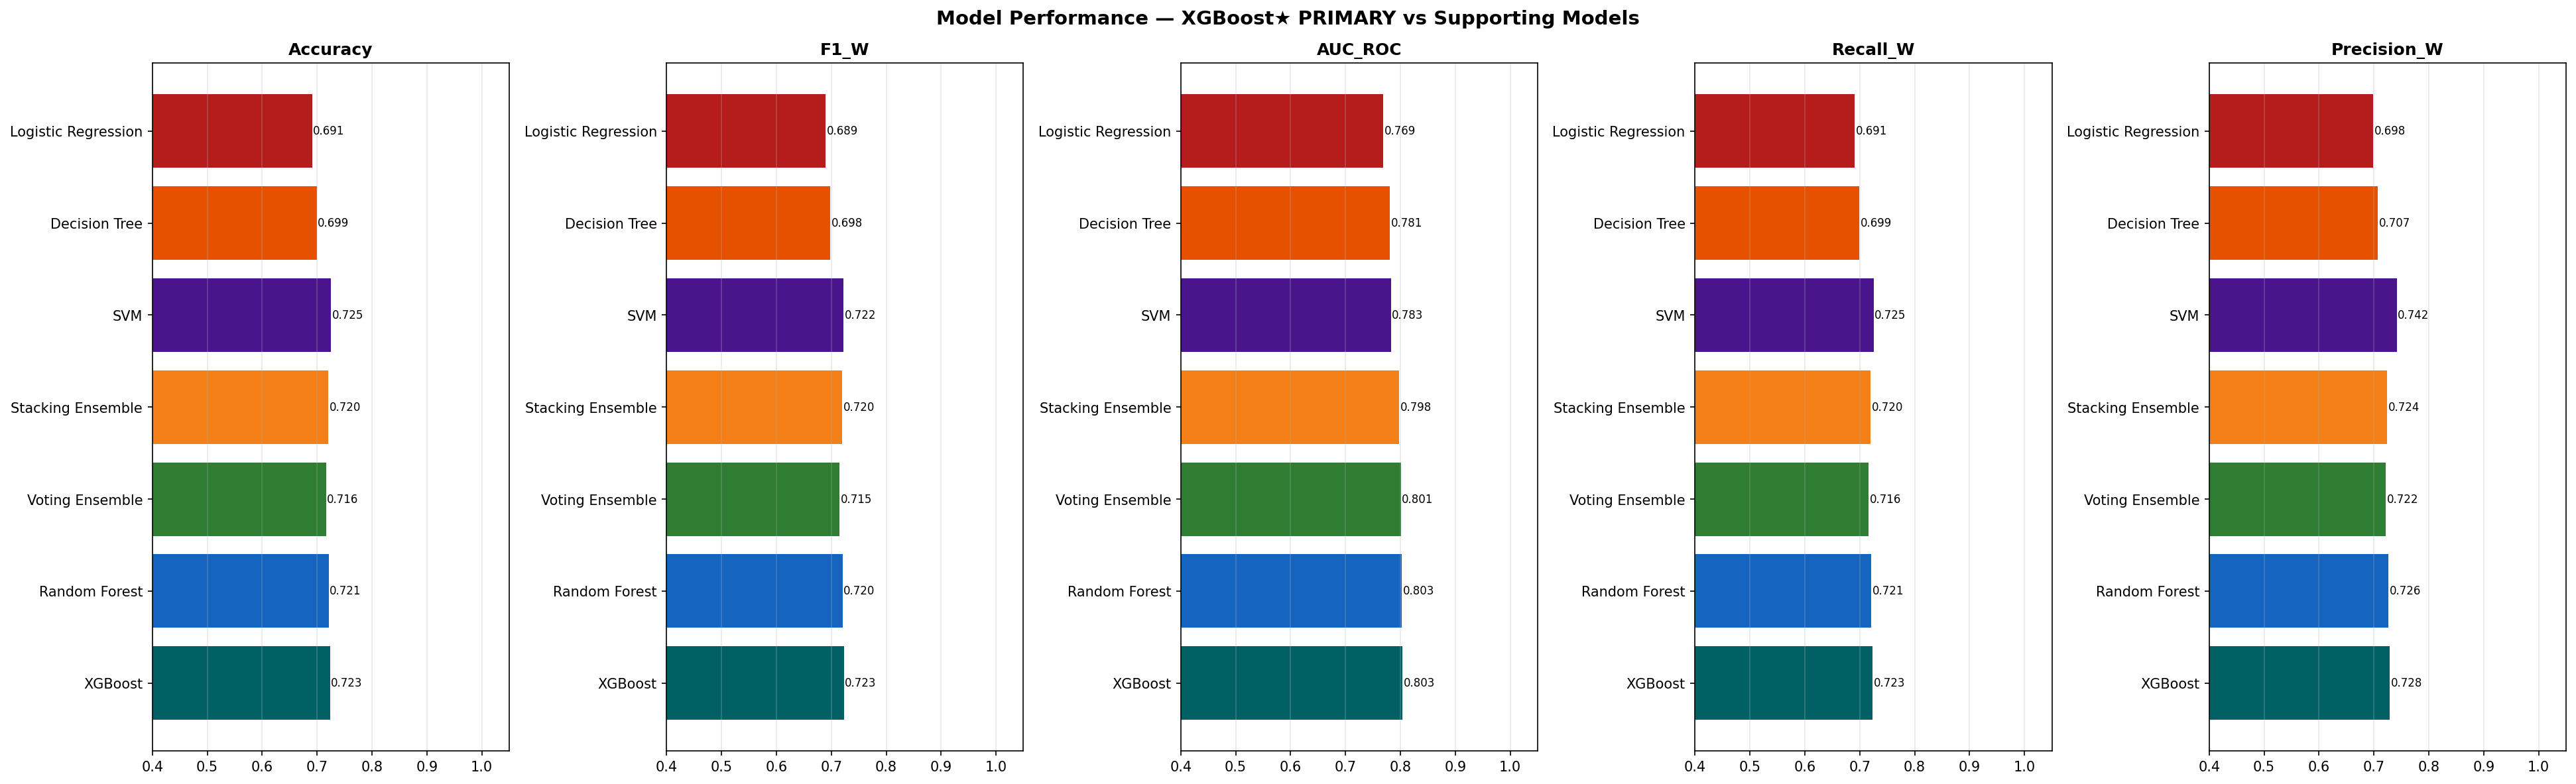

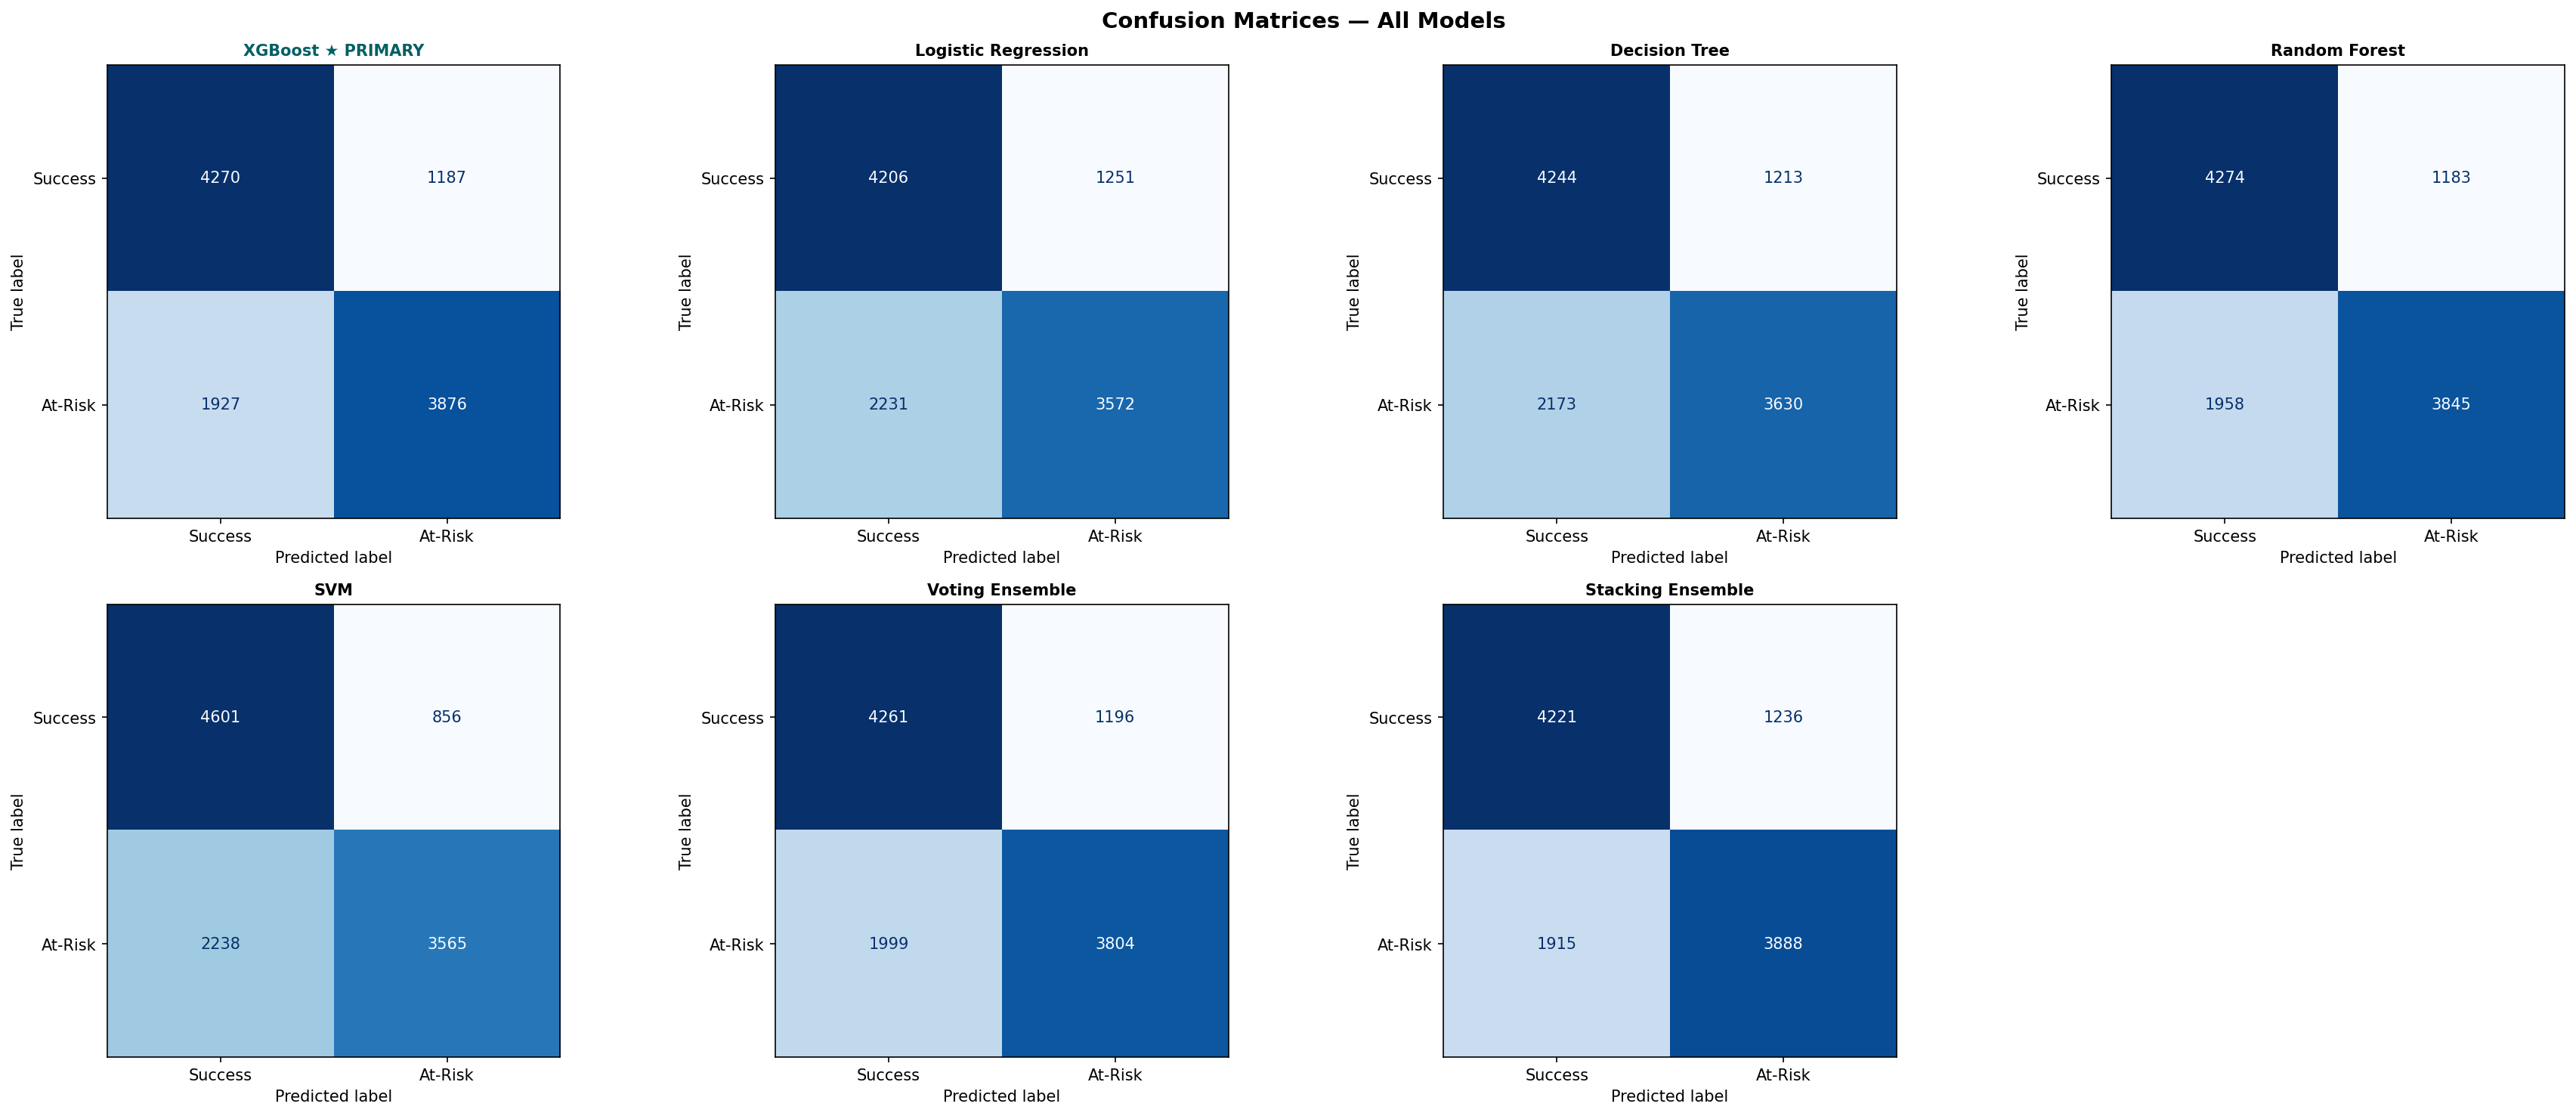

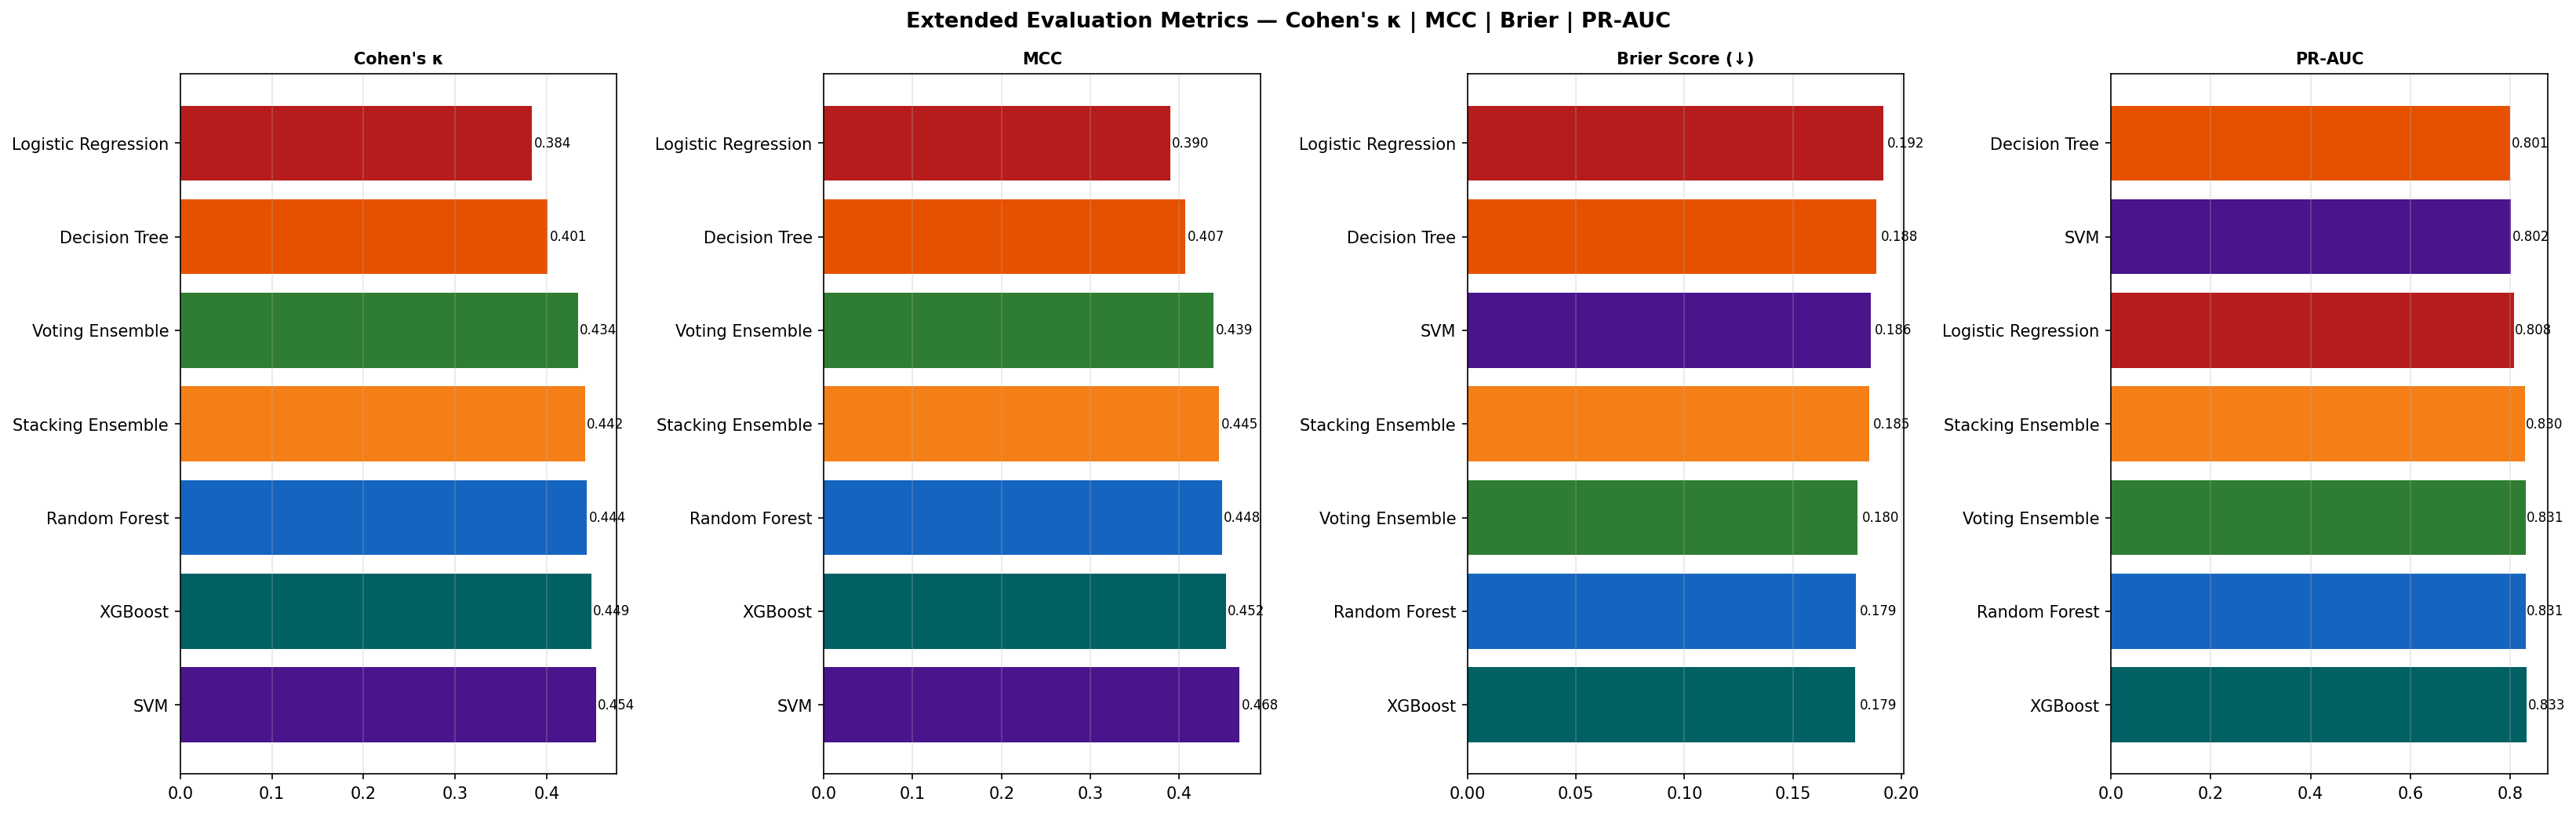

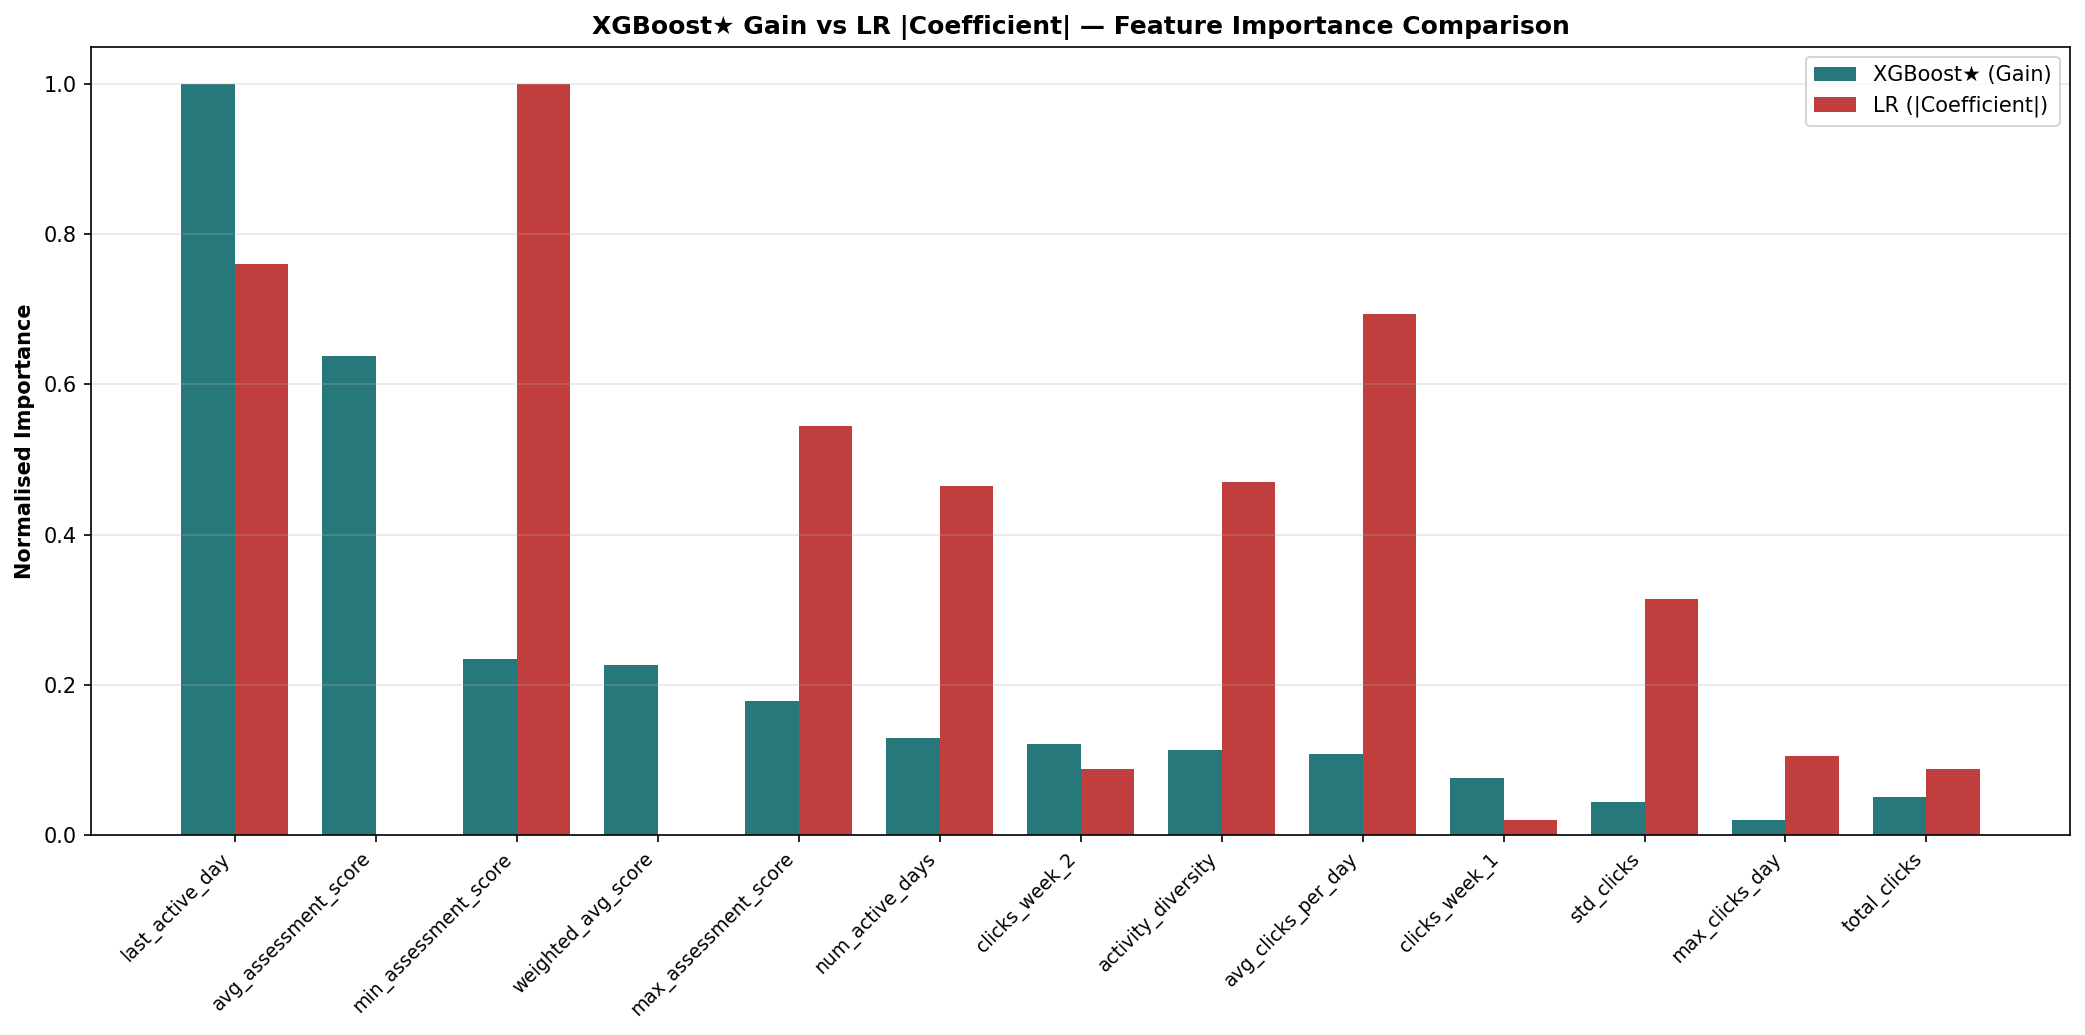

Performance charts saved.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 10 — PERFORMANCE VISUALISATION
# ════════════════════════════════════════════════════════════════════════════
metrics  = ['Accuracy','F1_W','AUC_ROC','Recall_W','Precision_W']
plot_df  = perf_df[['Model']+metrics].sort_values('AUC_ROC',ascending=False)
colors   = [MODEL_COLORS.get(m,'grey') for m in plot_df['Model']]

fig,axes = plt.subplots(1,5,figsize=(26,8))
for ax,metric in zip(axes,metrics):
    bars = ax.barh(plot_df['Model'],plot_df[metric],color=colors)
    ax.set_xlim(0.4,1.05); ax.set_title(metric,fontweight='bold')
    for bar,v in zip(bars,plot_df[metric]):
        ax.text(v+0.002,bar.get_y()+bar.get_height()/2,
                f'{v:.3f}',va='center',fontsize=8)
    ax.grid(axis='x',alpha=0.3)
plt.suptitle('Model Performance — XGBoost★ PRIMARY vs Supporting Models',
             fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'model_comparison_XGB.png',dpi=150,bbox_inches='tight')
plt.show()

# Confusion matrices — all 7 models
n_m  = len(trained_models); ncol = 4; nrow = (n_m+ncol-1)//ncol
fig,axes = plt.subplots(nrow,ncol,figsize=(ncol*6,nrow*5))
axes = axes.flatten()
for i,(nm,mdl) in enumerate(trained_models.items()):
    preds = mdl.predict(X_test_sel)
    ConfusionMatrixDisplay(confusion_matrix(y_test_arr,preds),
                           display_labels=['Success','At-Risk']).plot(
        ax=axes[i],colorbar=False,cmap='Blues')
    tc = PRIMARY_COLOR if nm==PRIMARY_NAME else 'black'
    axes[i].set_title(nm+(' ★ PRIMARY' if nm==PRIMARY_NAME else ''),
                      fontsize=10,fontweight='bold',color=tc)
for i in range(n_m,len(axes)): axes[i].set_visible(False)
plt.suptitle('Confusion Matrices — All Models',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'confusion_matrices_XGB.png',dpi=150,bbox_inches='tight')
plt.show()

# Extended metrics chart
fig,axes = plt.subplots(1,4,figsize=(22,7))
ext_metrics = [('Cohen_Kappa',"Cohen's κ"),('MCC','MCC'),
               ('Brier_Score','Brier Score (↓)'),('Avg_Precision','PR-AUC')]
for ax,(metric,ylabel) in zip(axes,ext_metrics):
    asc = metric=='Brier_Score'
    od  = perf_df.sort_values(metric,ascending=asc)
    bc  = [MODEL_COLORS.get(m,'grey') for m in od['Model']]
    bars = ax.barh(od['Model'],od[metric],color=bc)
    ax.set_title(ylabel,fontweight='bold',fontsize=10)
    for bar,v in zip(bars,od[metric]):
        ax.text(v+0.002,bar.get_y()+bar.get_height()/2,
                f'{v:.3f}',va='center',fontsize=8)
    ax.grid(axis='x',alpha=0.3)
plt.suptitle("Extended Evaluation Metrics — Cohen's κ | MCC | Brier | PR-AUC",
             fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'extended_metrics_XGB.png',dpi=150,bbox_inches='tight')
plt.show()

# XGBoost vs LR feature importance comparison
xgb_fi = pd.Series(trained_models['XGBoost'].named_steps['clf'].feature_importances_,
                   index=FEATURE_NAMES_SEL).sort_values(ascending=False)
lr_clf = trained_models['Logistic Regression'].named_steps['clf']
lr_fi  = pd.Series(np.abs(lr_clf.coef_[0]),index=FEATURE_NAMES_SEL).sort_values(ascending=False)
top_compare = list(dict.fromkeys(list(xgb_fi.index[:10])+list(lr_fi.index[:10])))
xgb_vals = [xgb_fi.get(f,0)/(xgb_fi.max()+1e-9) for f in top_compare]
lr_vals  = [lr_fi.get(f,0) /(lr_fi.max() +1e-9) for f in top_compare]

fig,ax = plt.subplots(figsize=(14,7))
x2 = np.arange(len(top_compare)); w = 0.38
ax.bar(x2-w/2,xgb_vals,w,label='XGBoost★ (Gain)',color=PRIMARY_COLOR,alpha=0.85)
ax.bar(x2+w/2,lr_vals, w,label='LR (|Coefficient|)',color='#B71C1C',alpha=0.85)
ax.set_xticks(x2)
ax.set_xticklabels([f[:22] for f in top_compare],rotation=45,ha='right',fontsize=9)
ax.set_ylabel('Normalised Importance',fontweight='bold')
ax.set_title('XGBoost★ Gain vs LR |Coefficient| — Feature Importance Comparison',
             fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR/'xgb_vs_lr_XGB.png',dpi=150,bbox_inches='tight')
plt.show()
print('Performance charts saved.')


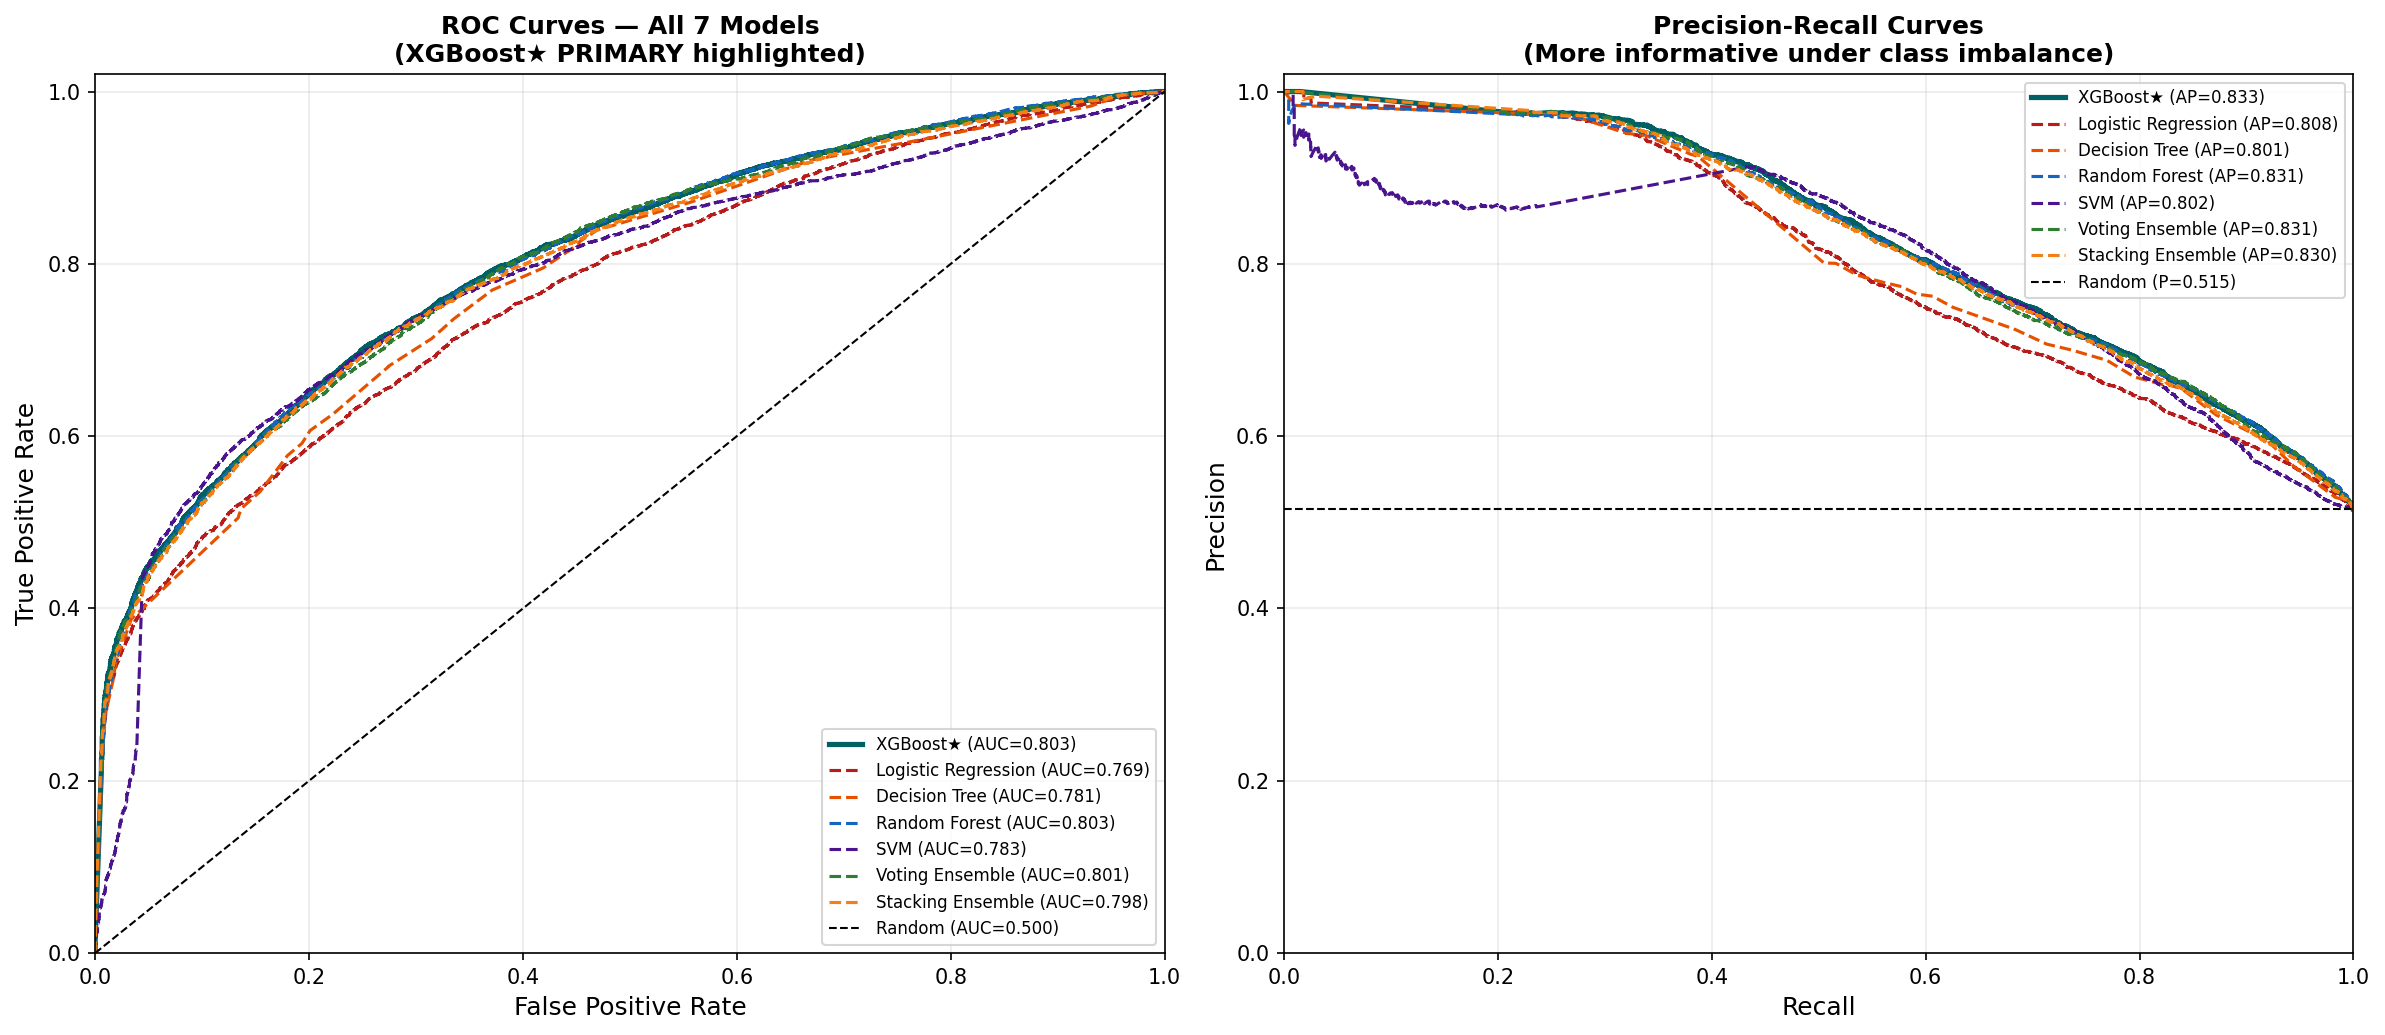

ROC & PR curves saved.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 11 — ROC & PRECISION-RECALL CURVES — All 7 Models
# ════════════════════════════════════════════════════════════════════════════
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(16,7))

for name,model in trained_models.items():
    y_prob = model.predict_proba(X_test_sel)[:,1]
    color  = MODEL_COLORS.get(name,'grey')
    lw     = 2.5 if name==PRIMARY_NAME else 1.5
    ls     = '-'  if name==PRIMARY_NAME else '--'

    fpr,tpr,_ = roc_curve(y_test_arr,y_prob)
    auc_val   = roc_auc_score(y_test_arr,y_prob)
    ax1.plot(fpr,tpr,color=color,lw=lw,ls=ls,
             label=f'{name}{"★" if name==PRIMARY_NAME else ""} (AUC={auc_val:.3f})')

    prec,rec,_ = precision_recall_curve(y_test_arr,y_prob)
    ap_val     = average_precision_score(y_test_arr,y_prob)
    ax2.plot(rec,prec,color=color,lw=lw,ls=ls,
             label=f'{name}{"★" if name==PRIMARY_NAME else ""} (AP={ap_val:.3f})')

ax1.plot([0,1],[0,1],'k--',lw=1,label='Random (AUC=0.500)')
ax1.set_xlabel('False Positive Rate',fontsize=12)
ax1.set_ylabel('True Positive Rate',fontsize=12)
ax1.set_title('ROC Curves — All 7 Models\n(XGBoost★ PRIMARY highlighted)',
              fontweight='bold',fontsize=12)
ax1.legend(fontsize=8,loc='lower right'); ax1.grid(alpha=0.25)
ax1.set_xlim([0,1]); ax1.set_ylim([0,1.02])

baseline_pr = y_test_arr.mean()
ax2.axhline(baseline_pr,color='k',ls='--',lw=1,label=f'Random (P={baseline_pr:.3f})')
ax2.set_xlabel('Recall',fontsize=12); ax2.set_ylabel('Precision',fontsize=12)
ax2.set_title('Precision-Recall Curves\n(More informative under class imbalance)',
              fontweight='bold',fontsize=12)
ax2.legend(fontsize=8,loc='upper right'); ax2.grid(alpha=0.25)
ax2.set_xlim([0,1]); ax2.set_ylim([0,1.02])

plt.tight_layout()
plt.savefig(FIGURES_DIR/'roc_pr_curves_XGB.png',dpi=150,bbox_inches='tight')
plt.show()
print('ROC & PR curves saved.')


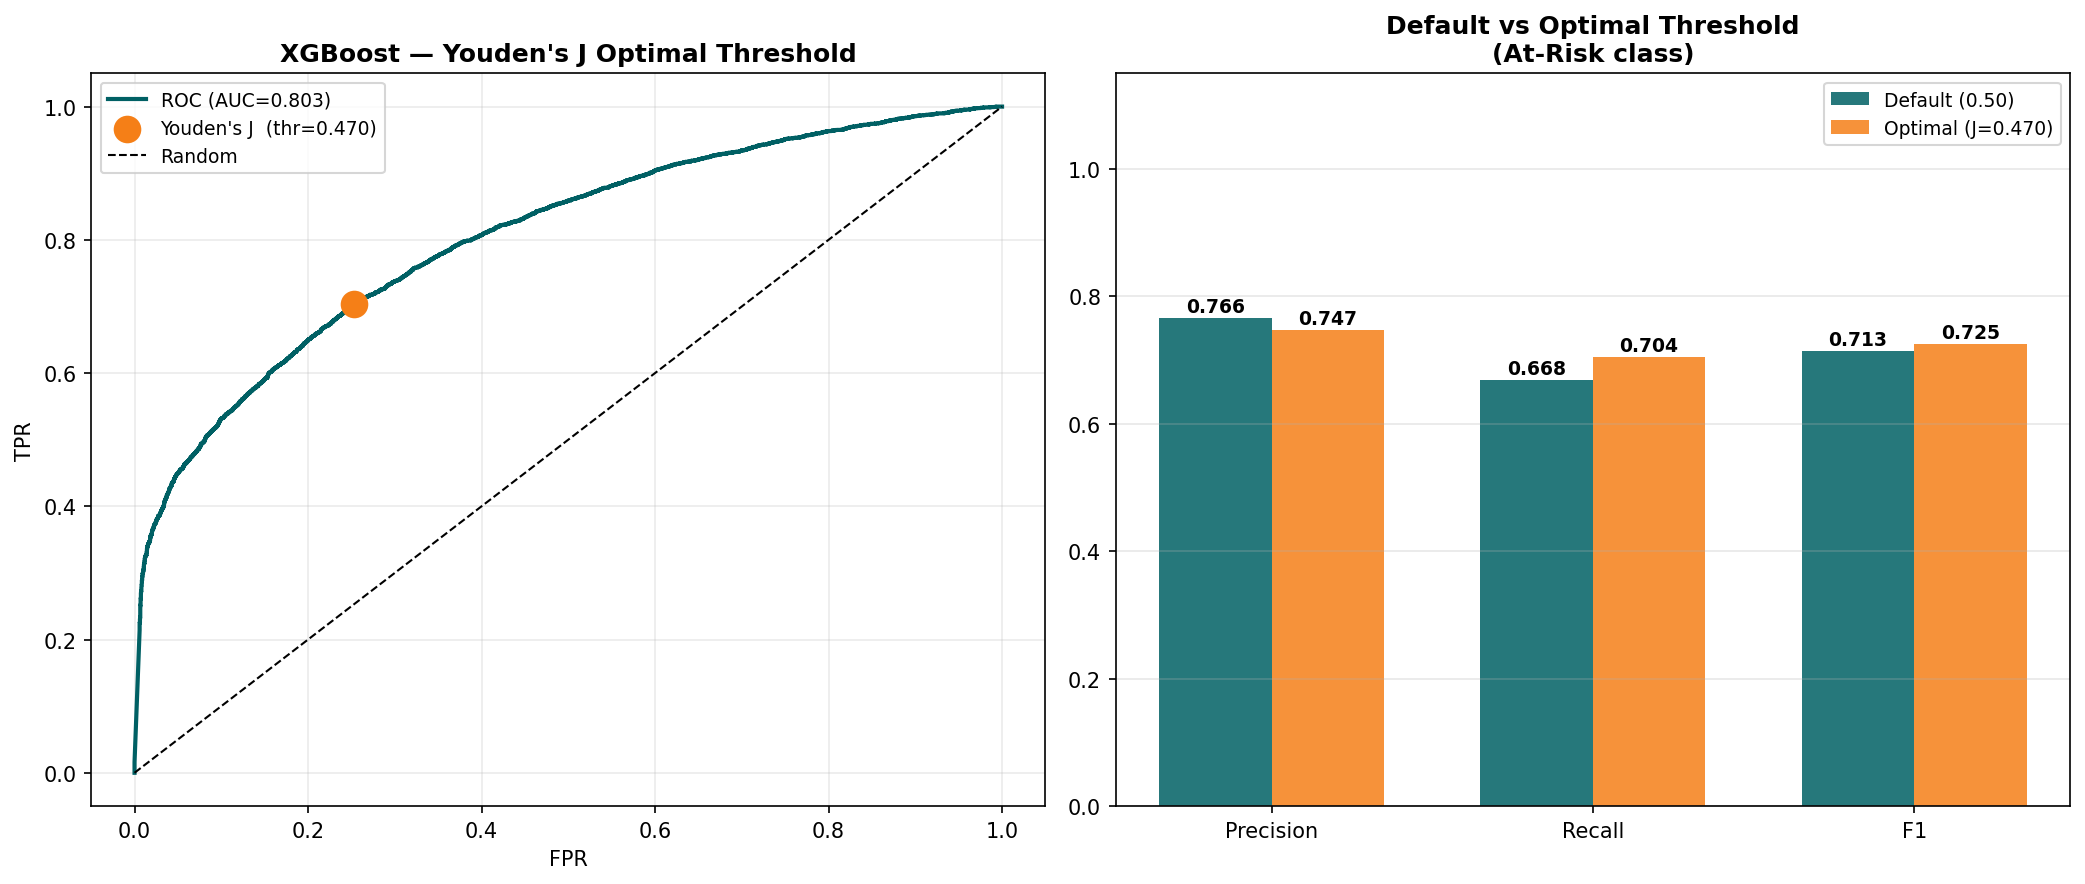

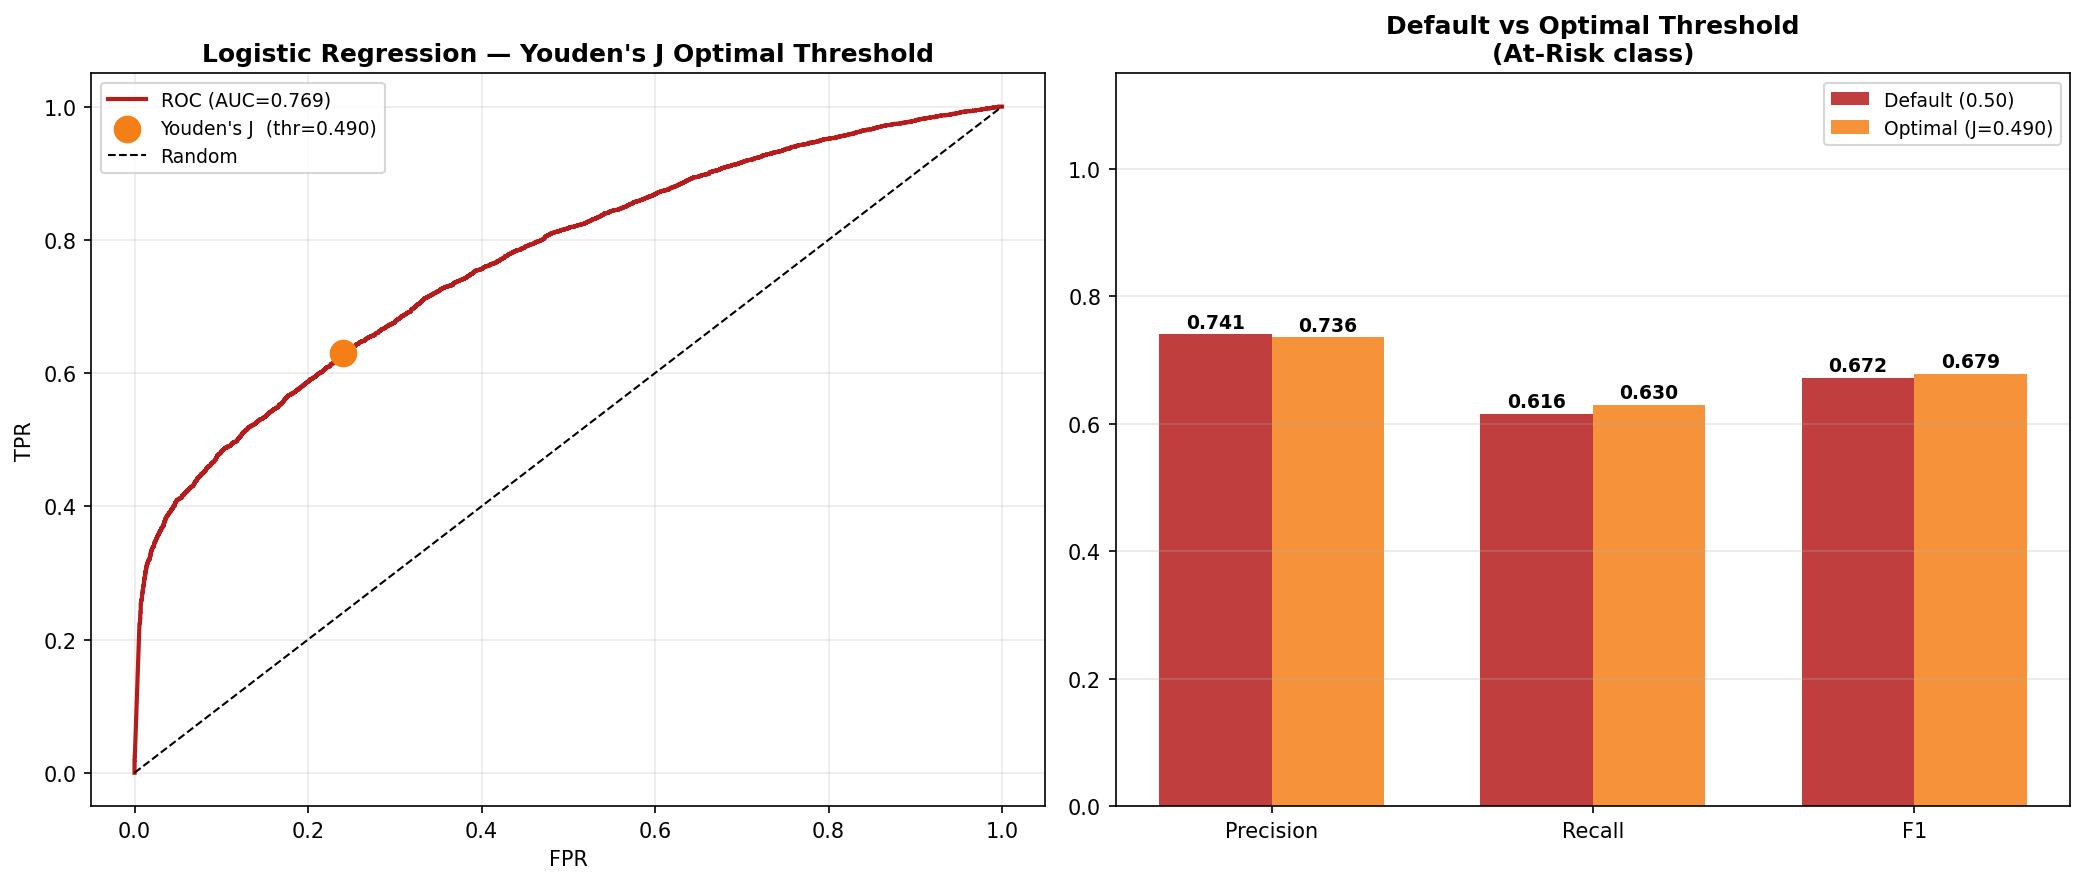

Threshold analysis saved.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 12 — OPTIMAL THRESHOLD (Youden's J) — XGBoost★ & LR Baseline
# ════════════════════════════════════════════════════════════════════════════

y_prob_xgb = primary_model.predict_proba(X_test_sel)[:,1]
_fpr_init, _tpr_init, _thr_init = roc_curve(y_test_arr, y_prob_xgb)
_best_idx_init = np.argmax(_tpr_init - _fpr_init)
best_j_thr_xgb = float(_thr_init[_best_idx_init])
y_pred_xgb = (y_prob_xgb >= best_j_thr_xgb).astype(int)

threshold_results = []

for name in ['XGBoost','Logistic Regression']:
    model  = trained_models[name]
    y_prob = model.predict_proba(X_test_sel)[:,1]
    color  = MODEL_COLORS[name]

    fpr,tpr,thresholds = roc_curve(y_test_arr,y_prob)
    best_idx = np.argmax(tpr-fpr); best_thr = thresholds[best_idx]

    yp_def = (y_prob>=0.50).astype(int)
    yp_opt = (y_prob>=best_thr).astype(int)

    for label,yp in [('Default (0.50)',yp_def),(f'Optimal (J={best_thr:.3f})',yp_opt)]:
        spec = (yp[y_test_arr==0]==0).sum()/(y_test_arr==0).sum()
        threshold_results.append({'Model':name,'Threshold':label,
            'Precision':precision_score(y_test_arr,yp,zero_division=0),
            'Recall'   :recall_score(y_test_arr,yp,zero_division=0),
            'F1'       :f1_score(y_test_arr,yp,zero_division=0),
            'Specificity':spec})

    fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,6))
    ax1.plot(fpr,tpr,color=color,lw=2,
             label=f'ROC (AUC={roc_auc_score(y_test_arr,y_prob):.3f})')
    ax1.scatter(fpr[best_idx],tpr[best_idx],s=150,zorder=5,color='#F57F17',
                label=f"Youden's J  (thr={best_thr:.3f})")
    ax1.plot([0,1],[0,1],'k--',lw=1,label='Random')
    ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
    ax1.set_title(f"{name} — Youden's J Optimal Threshold",fontweight='bold')
    ax1.legend(fontsize=9); ax1.grid(alpha=0.25)

    rows2 = [r for r in threshold_results if r['Model']==name]
    x = np.arange(3); w = 0.35
    for i,(row,off,fc) in enumerate(zip(rows2,[-w/2,w/2],[color,'#F57F17'])):
        vals = [row['Precision'],row['Recall'],row['F1']]
        ax2.bar(x+off,vals,w,label=row['Threshold'],color=fc,alpha=0.85)
        for xi,v in zip(x+off,vals):
            ax2.text(xi,v+0.01,f'{v:.3f}',ha='center',fontsize=9,fontweight='bold')
    ax2.set_xticks(x); ax2.set_xticklabels(['Precision','Recall','F1'])
    ax2.set_ylim(0,1.15)
    ax2.set_title('Default vs Optimal Threshold\n(At-Risk class)',fontweight='bold')
    ax2.legend(fontsize=9); ax2.grid(axis='y',alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR/f'threshold_{name.replace(" ","_")}_XGB.png',dpi=150,bbox_inches='tight')
    plt.show()

pd.DataFrame(threshold_results).to_csv(CSV_DIR/'threshold_comparison_XGB.csv',index=False)
print('Threshold analysis saved.')


  XGBoost★ PRIMARY — Youden's J Optimal Threshold
  Optimal threshold : 0.4703
  Youden's J score : 0.4510
  (J = Sensitivity + Specificity - 1)

── Default Threshold (0.50) ──────────────────────────
              precision    recall  f1-score   support

     Success     0.6890    0.7825    0.7328      5457
     At-Risk     0.7656    0.6679    0.7134      5803

    accuracy                         0.7234     11260
   macro avg     0.7273    0.7252    0.7231     11260
weighted avg     0.7285    0.7234    0.7228     11260

── Optimal Threshold (J=0.4703) ──────────────────
              precision    recall  f1-score   support

     Success     0.7037    0.7467    0.7246      5457
     At-Risk     0.7473    0.7043    0.7252      5803

    accuracy                         0.7249     11260
   macro avg     0.7255    0.7255    0.7249     11260
weighted avg     0.7262    0.7249    0.7249     11260


── Gain from Youden's J Threshold ──────────────────
                     Default  Optimal  Δ

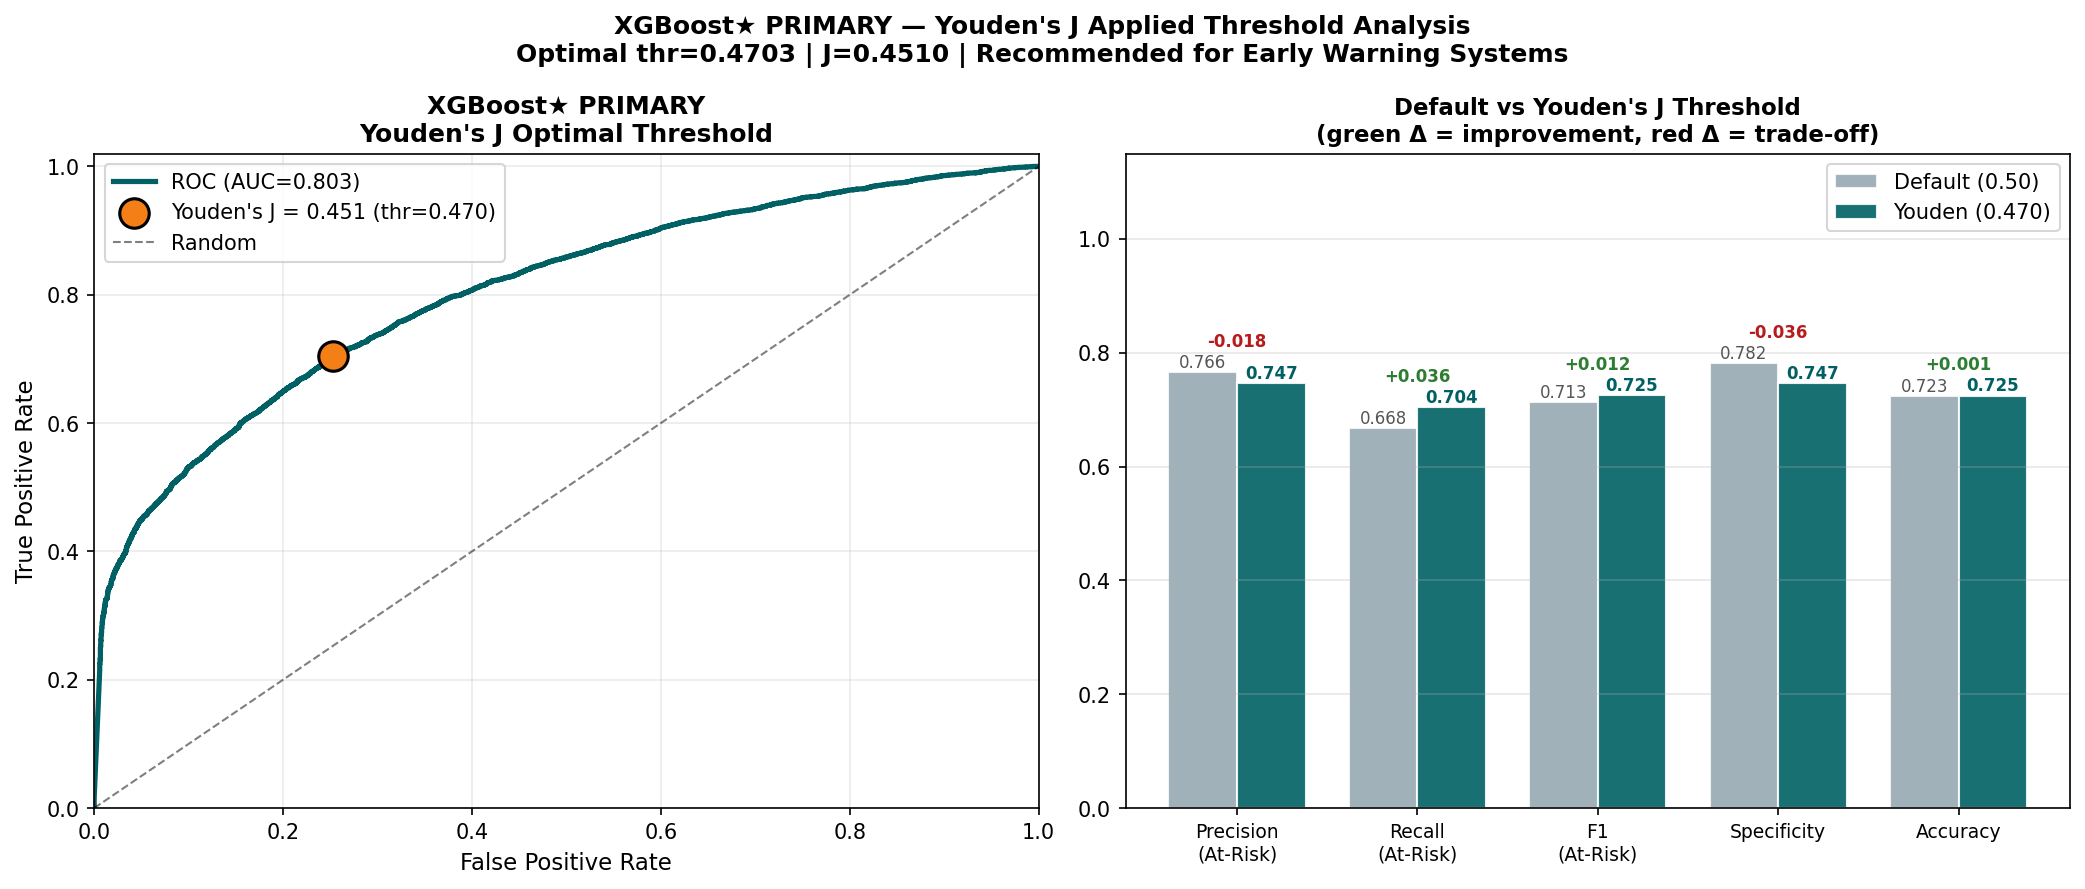

Youden Applied analysis saved.

📌 RECOMMENDATION: Use threshold=0.4703 in production
   This increases At-Risk Recall by +0.036
   at the cost of Specificity -0.036


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# YOUDEN'S J — APPLIED THRESHOLD ANALYSIS
# ════════════════════════════════════════════════════════════════════════════

y_prob_primary = y_prob_xgb
best_j_thr     = best_j_thr_xgb
fpr_j, tpr_j, _ = roc_curve(y_test_arr, y_prob_primary)
best_j_idx = np.argmax(tpr_j - fpr_j)
j_score    = float(tpr_j[best_j_idx] - fpr_j[best_j_idx])

yp_default_j = (y_prob_xgb >= 0.50).astype(int)
yp_optimal_j = (y_prob_xgb >= best_j_thr).astype(int)

print(f"=======================================================")
print(f"  XGBoost★ PRIMARY — Youden\'s J Optimal Threshold")
print(f"=======================================================")
print(f"  Optimal threshold : {best_j_thr:.4f}")
print(f"  Youden\'s J score : {j_score:.4f}")
print(f"  (J = Sensitivity + Specificity - 1)")
print()

# ── Detailed comparison ───────────────────────────────────────────────────
from sklearn.metrics import classification_report
print("── Default Threshold (0.50) ──────────────────────────")
print(classification_report(y_test_arr, yp_default_j,
      target_names=["Success", "At-Risk"], digits=4))

print(f"── Optimal Threshold (J={best_j_thr:.4f}) ──────────────────")
print(classification_report(y_test_arr, yp_optimal_j,
      target_names=["Success", "At-Risk"], digits=4))

# ── Per-metric gain table ─────────────────────────────────────────────────
metrics_compare = {}
for label, yp in [("Default", yp_default_j), ("Optimal", yp_optimal_j)]:
    metrics_compare[label] = {
        "Precision (At-Risk)" : precision_score(y_test_arr, yp, zero_division=0),
        "Recall (At-Risk)"    : recall_score(y_test_arr, yp, zero_division=0),
        "F1 (At-Risk)"        : f1_score(y_test_arr, yp, zero_division=0),
        "Specificity"         : (yp[y_test_arr==0]==0).sum() / (y_test_arr==0).sum(),
        "Accuracy"            : accuracy_score(y_test_arr, yp),
    }


tbl = pd.DataFrame({
    'Default' : metrics_compare['Default'],
    'Optimal' : metrics_compare['Optimal'],
})
tbl['Delta'] = tbl['Optimal'] - tbl['Default']
tbl = tbl.rename(columns={'Delta': 'Δ (Optimal−Default)'})
print("\n── Gain from Youden\'s J Threshold ──────────────────")
print(tbl.to_string(float_format="{:.4f}".format))

# ── Save ──────────────────────────────────────────────────────────────────
tbl.to_csv(CSV_DIR / "youden_threshold_gain_XGBoost_PRIMARY.csv")

# ── Visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: ROC with Youden point
ax = axes[0]
ax.plot(fpr_j, tpr_j, color=PRIMARY_COLOR, lw=2.5,
        label=f"ROC (AUC={roc_auc_score(y_test_arr, y_prob_primary):.3f})")
ax.scatter(fpr_j[best_j_idx], tpr_j[best_j_idx],
           s=200, zorder=6, color="#F57F17", edgecolors="black", linewidths=1.5,
           label=f"Youden\'s J = {j_score:.3f} (thr={best_j_thr:.3f})")
ax.plot([0,1],[0,1],"k--",lw=1,alpha=0.5,label="Random")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title(f"XGBoost★ PRIMARY\nYouden\'s J Optimal Threshold",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=10); ax.grid(alpha=0.25)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

# Plot 2: Metric comparison bar chart
ax = axes[1]
metric_names = ["Precision\n(At-Risk)", "Recall\n(At-Risk)",
                "F1\n(At-Risk)", "Specificity", "Accuracy"]
metric_keys  = list(metrics_compare["Default"].keys())
default_vals = [metrics_compare["Default"][k] for k in metric_keys]
optimal_vals = [metrics_compare["Optimal"][k] for k in metric_keys]
x = np.arange(len(metric_names)); w = 0.38

bars1 = ax.bar(x - w/2, default_vals, w, label="Default (0.50)",
               color="#90A4AE", alpha=0.85, edgecolor="white")
bars2 = ax.bar(x + w/2, optimal_vals, w,
               label=f"Youden ({best_j_thr:.3f})",
               color=PRIMARY_COLOR, alpha=0.90, edgecolor="white")

# Annotate bars
for bar, v in zip(bars1, default_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.008,
            f"{v:.3f}", ha="center", fontsize=8, color="#555")
for bar, v in zip(bars2, optimal_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.008,
            f"{v:.3f}", ha="center", fontsize=8, fontweight="bold",
            color=PRIMARY_COLOR)

# Gain annotations
for i, (d, o) in enumerate(zip(default_vals, optimal_vals)):
    gain = o - d
    if abs(gain) > 0.001:
        color = "#2E7D32" if gain > 0 else "#B71C1C"
        ax.text(i, max(d, o)+0.045, f"{gain:+.3f}",
                ha="center", fontsize=8, fontweight="bold", color=color)

ax.set_xticks(x); ax.set_xticklabels(metric_names, fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_title("Default vs Youden\'s J Threshold\n"
             "(green Δ = improvement, red Δ = trade-off)",
             fontweight="bold", fontsize=11)
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    f"XGBoost★ PRIMARY — Youden\'s J Applied Threshold Analysis\n"
    f"Optimal thr={best_j_thr:.4f} | J={j_score:.4f} | "
    f"Recommended for Early Warning Systems",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "youden_applied_XGBoost_PRIMARY.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Youden Applied analysis saved.")
print(f"\n📌 RECOMMENDATION: Use threshold={best_j_thr:.4f} in production")
print(f"   This increases At-Risk Recall by "
      f"{metrics_compare['Optimal']['Recall (At-Risk)'] - metrics_compare['Default']['Recall (At-Risk)']:+.3f}")
print(f"   at the cost of Specificity "
      f"{metrics_compare['Optimal']['Specificity'] - metrics_compare['Default']['Specificity']:+.3f}")


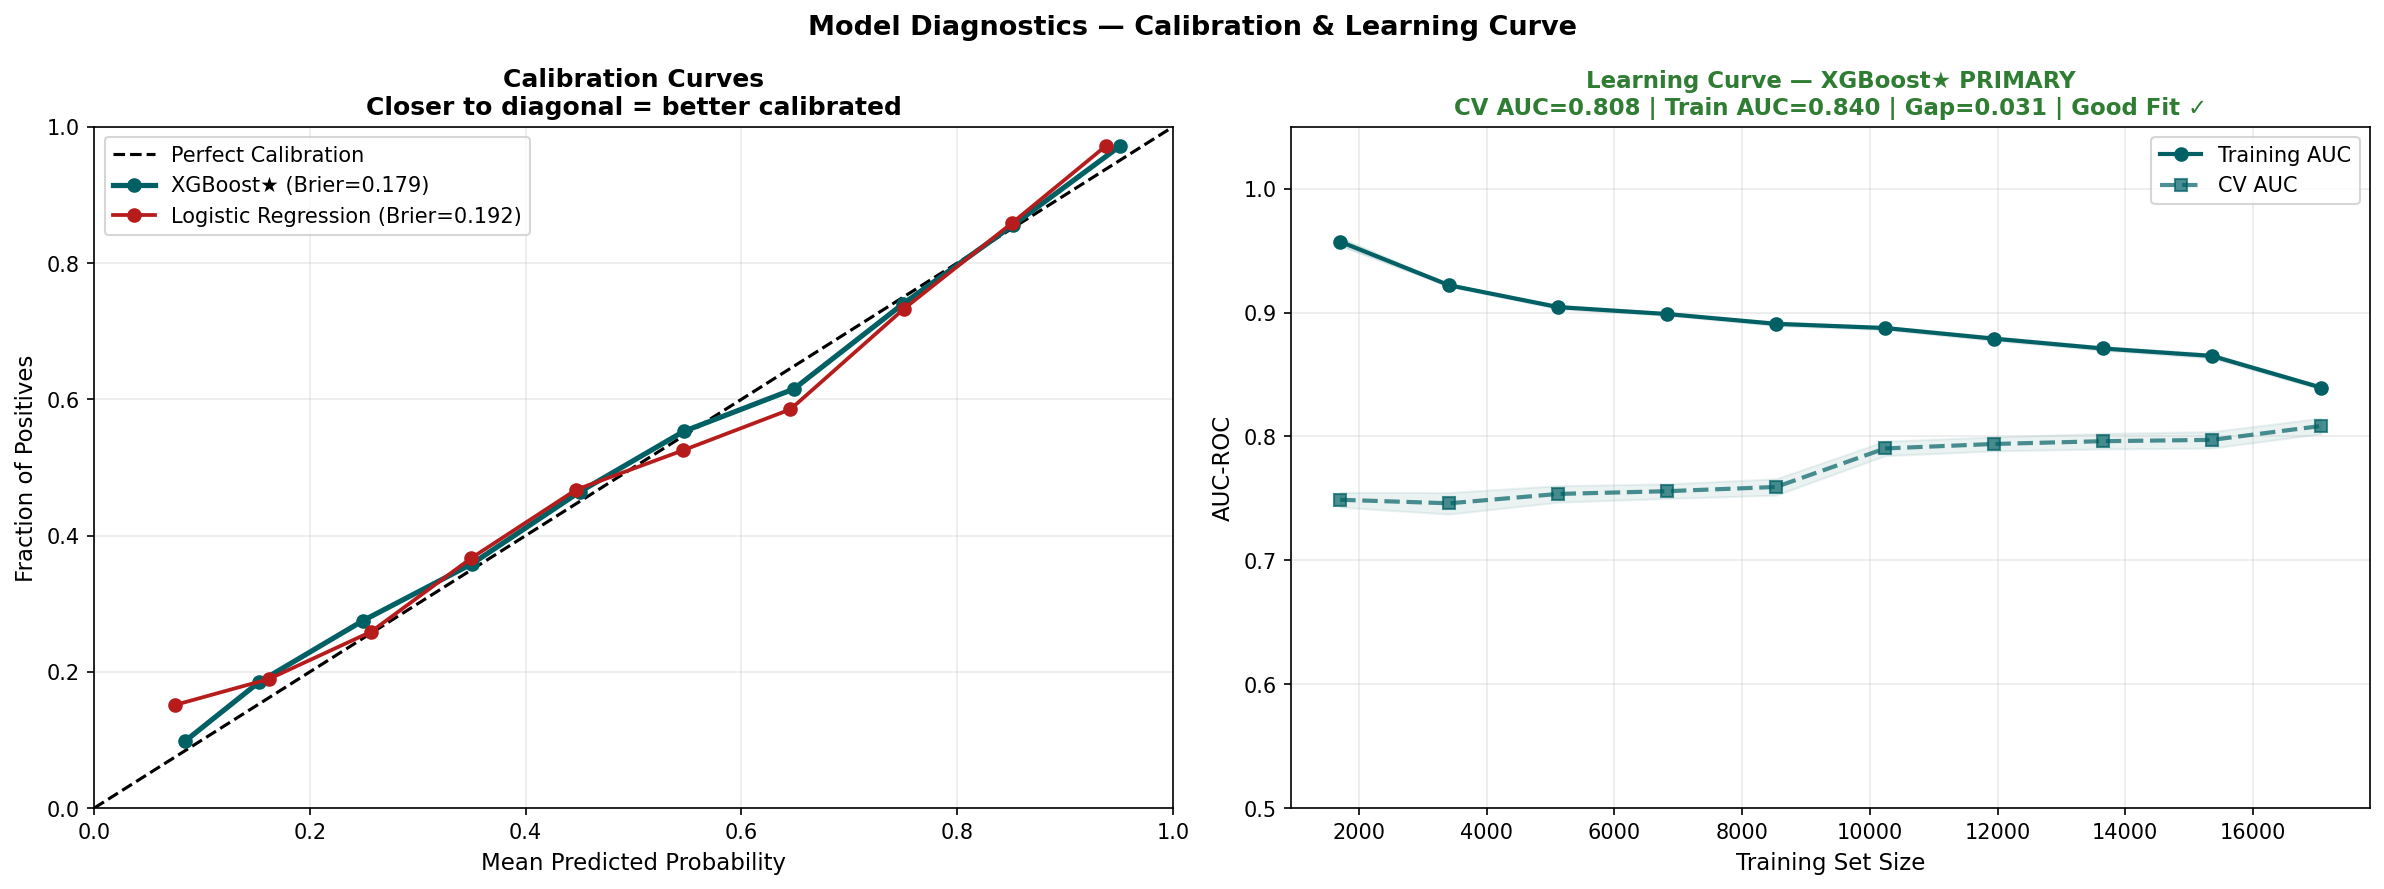

Diagnostics saved.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 13 — CALIBRATION CURVE + LEARNING CURVE
# ════════════════════════════════════════════════════════════════════════════
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(16,6))

# ── Calibration ──────────────────────────────────────────────────────────────
ax1.plot([0,1],[0,1],'k--',lw=1.5,label='Perfect Calibration')
for name in ['XGBoost','Logistic Regression']:
    y_prob = trained_models[name].predict_proba(X_test_sel)[:,1]
    frac_pos,mean_pred = calibration_curve(y_test_arr,y_prob,n_bins=10)
    bs  = brier_score_loss(y_test_arr,y_prob)
    lw  = 2.5 if name==PRIMARY_NAME else 1.8
    ax1.plot(mean_pred,frac_pos,marker='o',color=MODEL_COLORS[name],lw=lw,
             label=f'{name}{"★" if name==PRIMARY_NAME else ""} (Brier={bs:.3f})')
ax1.set_xlabel('Mean Predicted Probability',fontsize=11)
ax1.set_ylabel('Fraction of Positives',fontsize=11)
ax1.set_title('Calibration Curves\nCloser to diagonal = better calibrated',fontweight='bold')
ax1.legend(fontsize=10); ax1.grid(alpha=0.25); ax1.set_xlim([0,1]); ax1.set_ylim([0,1])

# ── Learning Curve — XGBoost PRIMARY ─────────────────────────────────────────
train_sizes,train_scores,val_scores = sk_lc(
    primary_model,X_train_sel,y_train,
    cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED),
    scoring='roc_auc',n_jobs=-1,
    train_sizes=np.linspace(0.1,1.0,10))

t_mean = train_scores.mean(axis=1); t_std = train_scores.std(axis=1)
v_mean = val_scores.mean(axis=1);   v_std = val_scores.std(axis=1)
gap    = t_mean[-1] - v_mean[-1]

# ── Academic Generalisation Assessment ──────────────────────────────────────

cv_adequate  = v_mean[-1] >= 0.70
cv_stable    = (v_mean[-1] - v_mean[0]) > -0.05
gap_growing  = (gap - (t_mean[0] - v_mean[0])) > 0.10
cv_var_ok    = v_std.mean() < 0.10

if not cv_adequate:
    verdict   = 'Underfitting ⚠'
    verdict_c = '#B71C1C'
elif gap_growing and not cv_stable:
    verdict   = 'Progressive Overfitting ⚠'
    verdict_c = '#E65100'
elif gap > 0.05 and cv_stable and not gap_growing:
    verdict   = 'High Variance — Stable Generalisation ✓'
    verdict_c = '#1565C0'
elif gap <= 0.05 and cv_adequate:
    verdict   = 'Good Fit ✓'
    verdict_c = '#2E7D32'
else:
    verdict   = 'Acceptable Fit ✓'
    verdict_c = '#2E7D32'

ax2.plot(train_sizes,t_mean,'o-',color=PRIMARY_COLOR,lw=2,label='Training AUC')
ax2.fill_between(train_sizes,t_mean-t_std,t_mean+t_std,alpha=0.12,color=PRIMARY_COLOR)
ax2.plot(train_sizes,v_mean,'s--',color=PRIMARY_COLOR,lw=2,alpha=0.7,label='CV AUC')
ax2.fill_between(train_sizes,v_mean-v_std,v_mean+v_std,alpha=0.08,color=PRIMARY_COLOR)
ax2.set_xlabel('Training Set Size',fontsize=11); ax2.set_ylabel('AUC-ROC',fontsize=11)
ax2.set_title(
    f'Learning Curve — XGBoost★ PRIMARY\n'
    f'CV AUC={v_mean[-1]:.3f} | Train AUC={t_mean[-1]:.3f} | '
    f'Gap={gap:.3f} | {verdict}',
    fontweight='bold', color=verdict_c, fontsize=11)
ax2.legend(fontsize=10); ax2.grid(alpha=0.25); ax2.set_ylim([0.5,1.05])

plt.suptitle('Model Diagnostics — Calibration & Learning Curve',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'diagnostics_XGB.png',dpi=150,bbox_inches='tight')
plt.show()
print('Diagnostics saved.')


Computing SHAP values …


  XGBoost SHAP: shape=(11260, 16)  E[f(x)]=0.0012


100%|===================| 22509/22520 [19:16<00:00]       WARNING:shap:Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


  RF SHAP: shape=(11260, 16)
  DT SHAP: shape=(11260, 16)
  LR SHAP (KernelExplainer) …


  0%|          | 0/300 [00:00<?, ?it/s]

  LR SHAP: shape=(300, 16)
  SVM SHAP (KernelExplainer) …


  0%|          | 0/300 [00:00<?, ?it/s]

  SVM SHAP: shape=(300, 16)
All SHAP values computed.


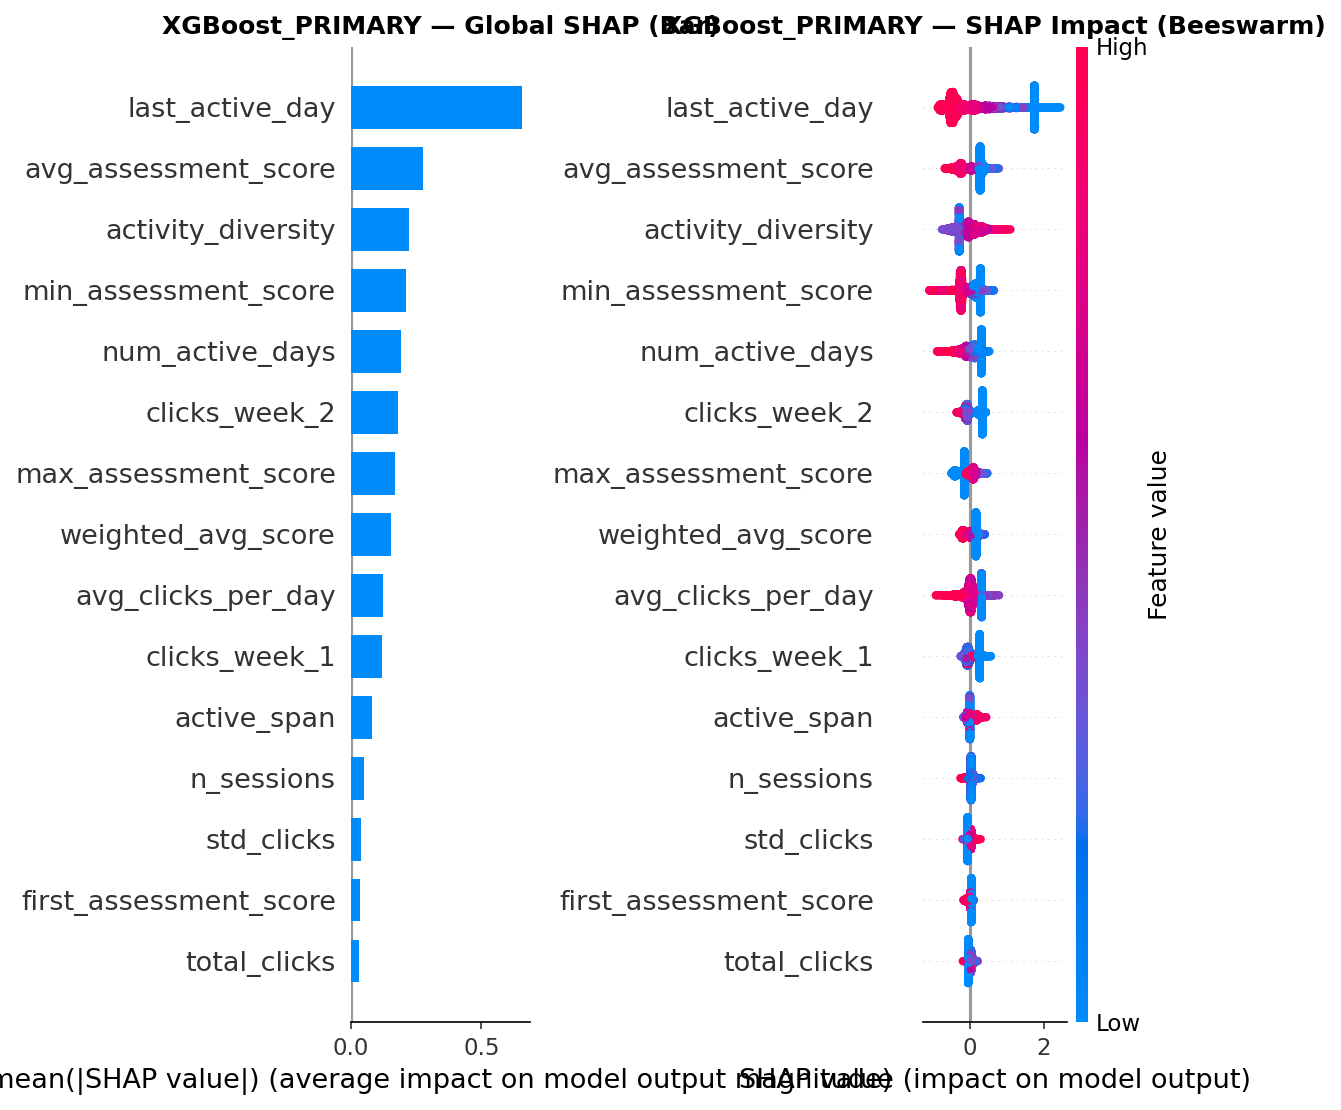

  Saved: shap_global_XGBoost_PRIMARY.png


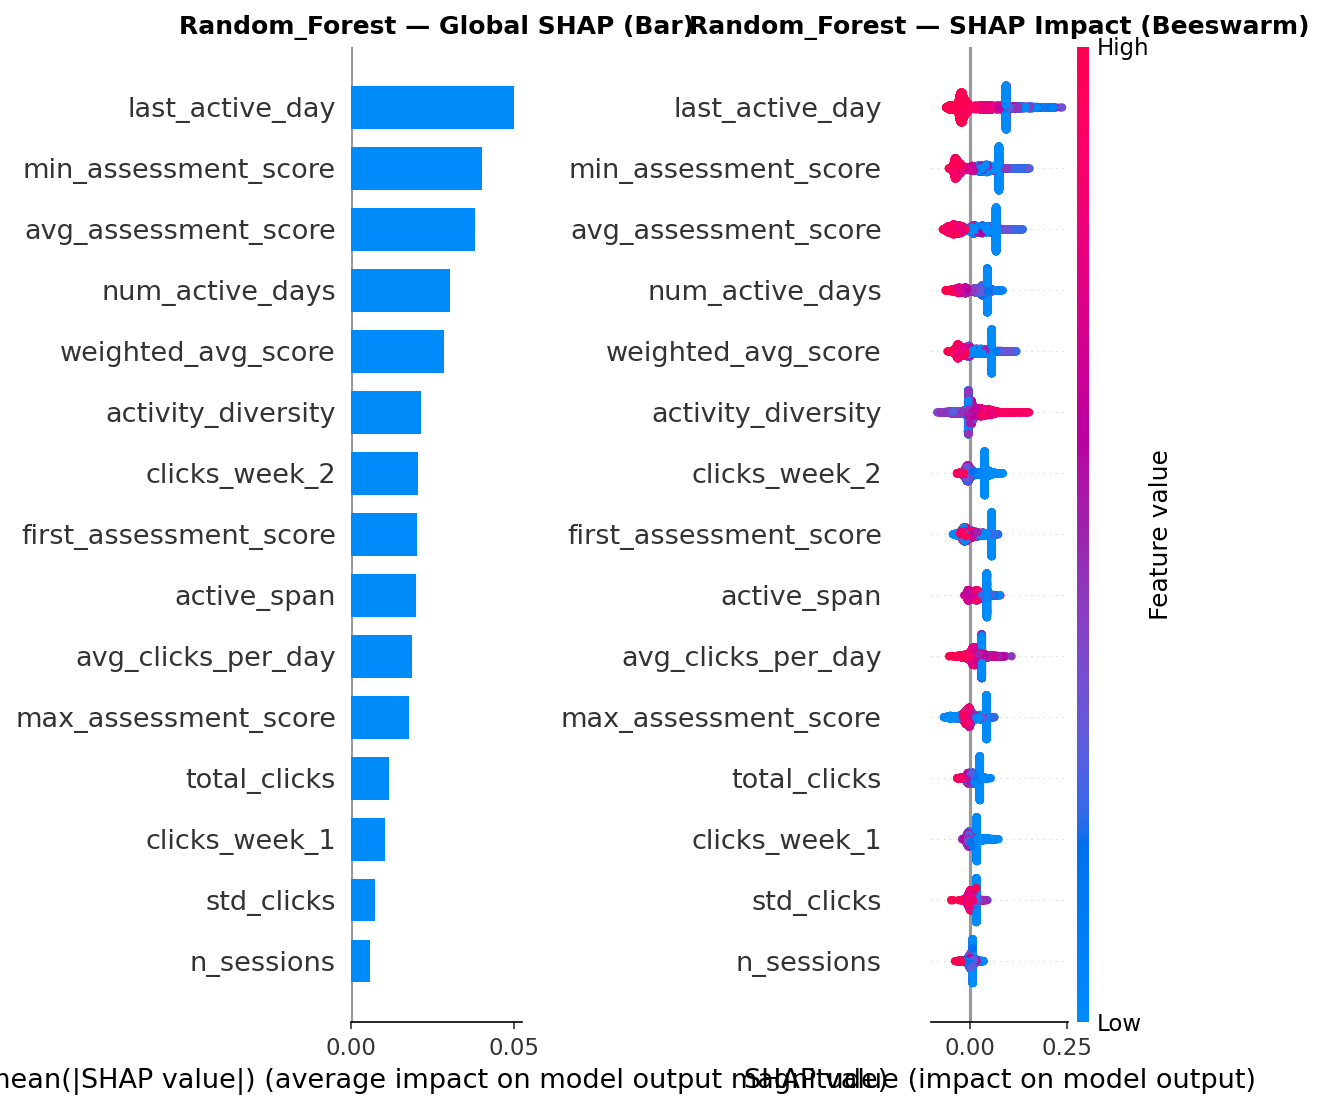

  Saved: shap_global_Random_Forest.png


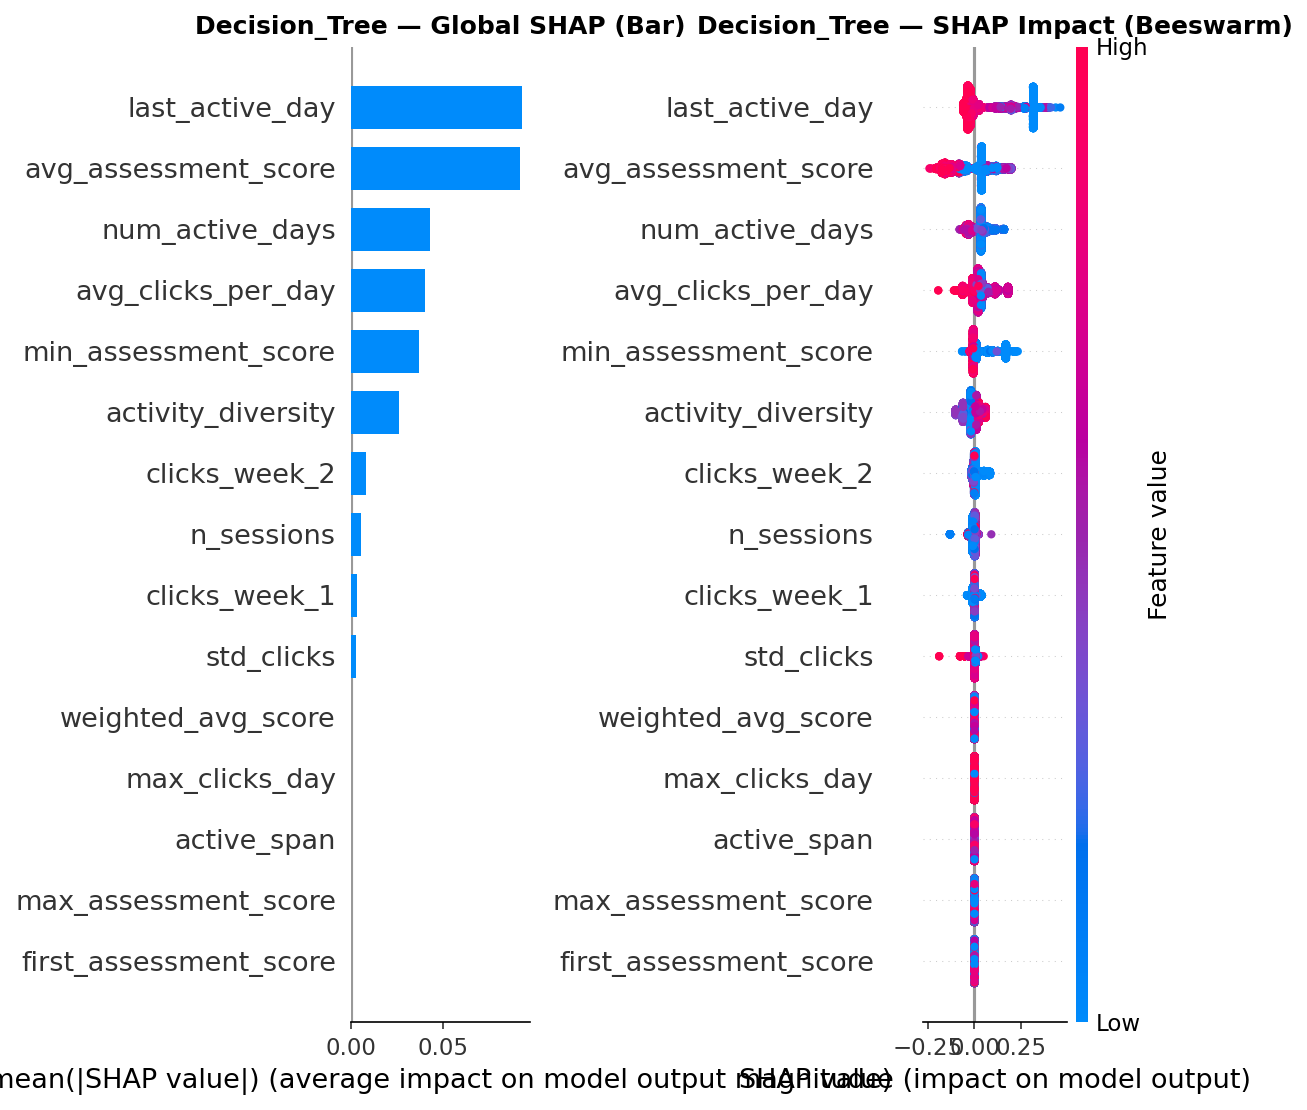

  Saved: shap_global_Decision_Tree.png


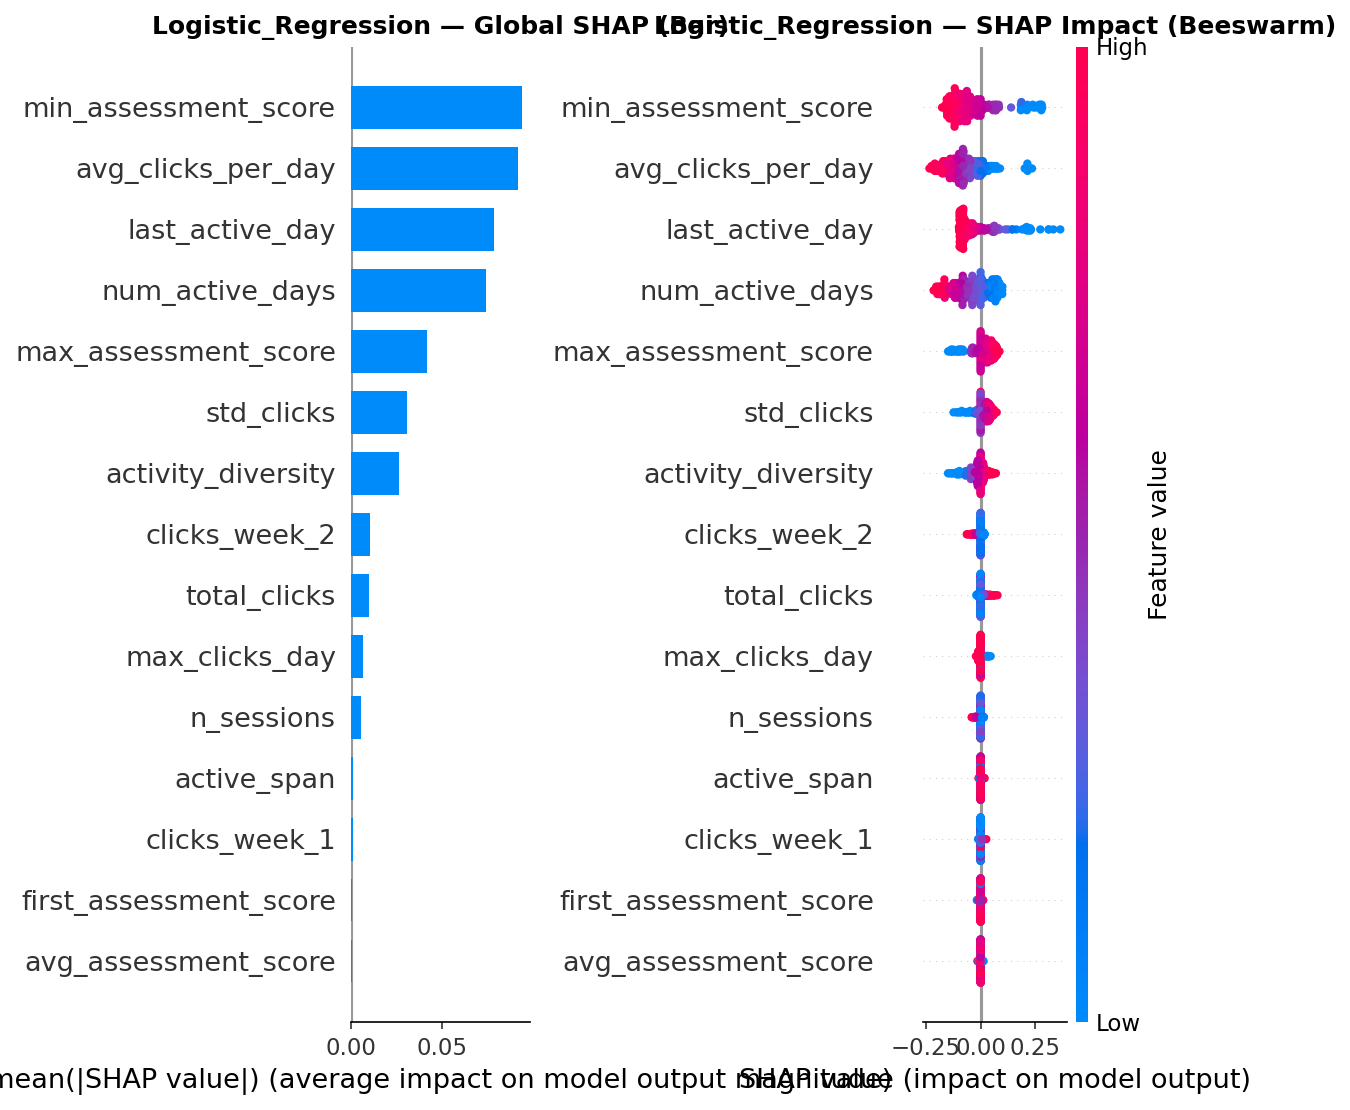

  Saved: shap_global_Logistic_Regression.png


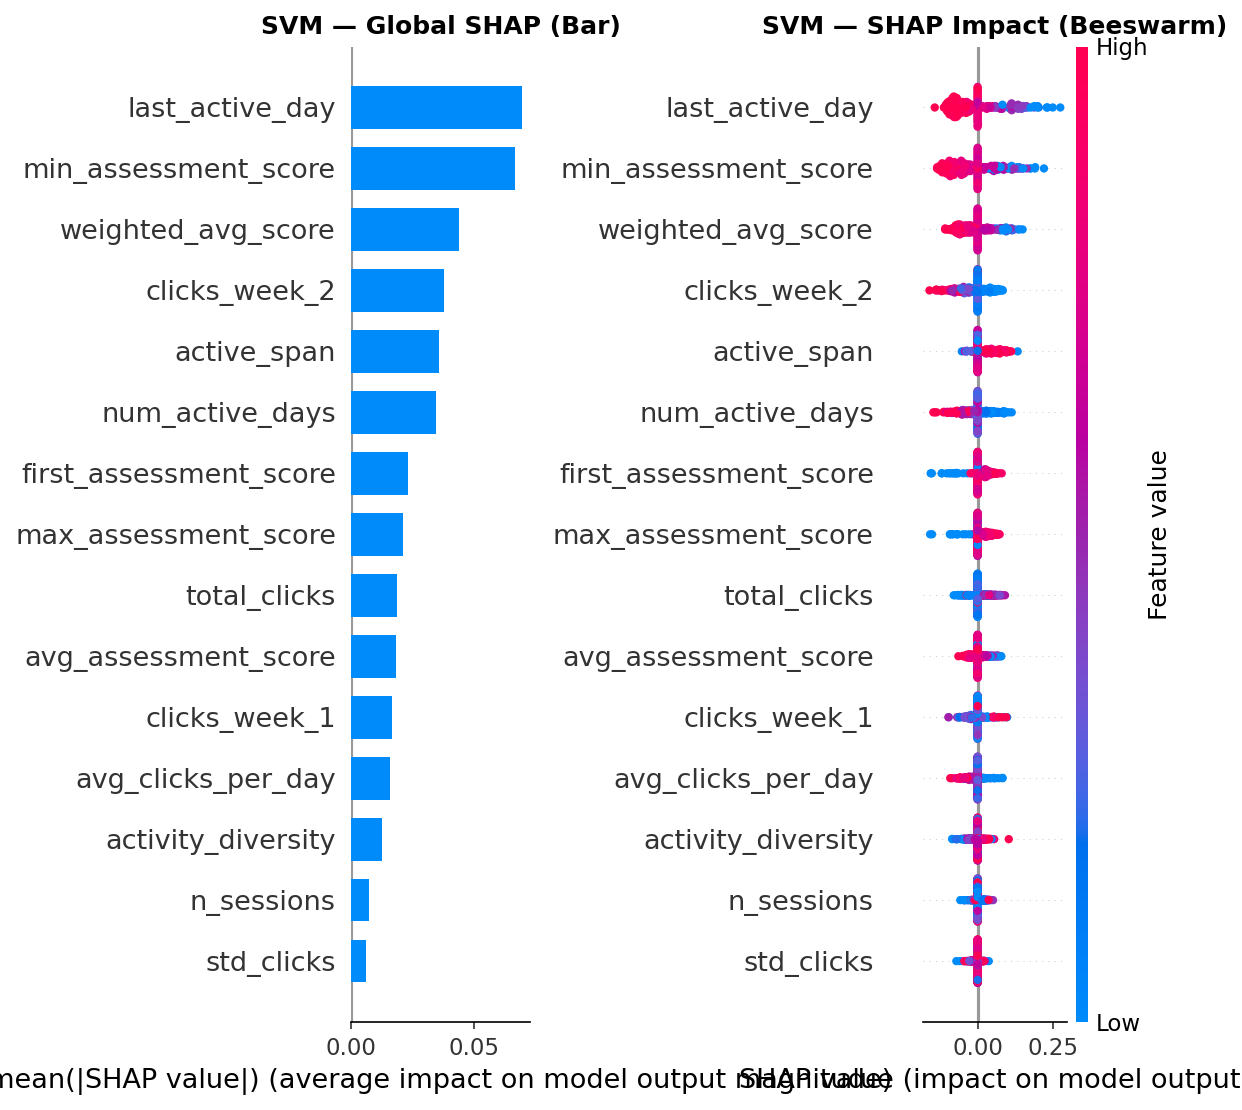

  Saved: shap_global_SVM.png

XGBoost SHAP auto-selected: 8 features


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 14 — SHAP ANALYSIS — XGBoost★ PRIMARY + All Supporting Models
#
# XGBoost, RF, DT → TreeExplainer (exact, fast, probability-space)
# LR, SVM         → KernelExplainer (model-agnostic)

# ════════════════════════════════════════════════════════════════════════════
shap.initjs()

def preprocess(pipe, X):
    Xi = pipe.named_steps['imp'].transform(X)
    return pipe.named_steps['scl'].transform(Xi)

def safe_kernel_shap(raw, n_features):
    arr = np.array(raw,dtype=float)
    if arr.ndim==3:   return arr[1]
    if arr.ndim==2:
        if arr.shape[1]==n_features: return arr
        if arr.shape[0]==n_features: return arr.T
    if arr.ndim==1 and arr.shape[0]==n_features: return arr.reshape(1,-1)
    raise ValueError(f'Unexpected KernelExplainer shape: {arr.shape}')

xgb_pipe = trained_models['XGBoost']; xgb_clf  = xgb_pipe.named_steps['clf']
X_tr_p   = preprocess(xgb_pipe,X_train_sel); X_te_xgb = preprocess(xgb_pipe,X_test_sel)

rf_pipe  = trained_models['Random Forest'];  X_te_rf  = preprocess(rf_pipe,X_test_sel)
dt_pipe  = trained_models['Decision Tree'];  X_te_dt  = preprocess(dt_pipe,X_test_sel)
svm_pipe = trained_models['SVM'];            X_te_svm = preprocess(svm_pipe,X_test_sel)
lr_pipe  = trained_models['Logistic Regression']; X_te_lr = preprocess(lr_pipe,X_test_sel)

print('Computing SHAP values …')

# XGBoost ★ PRIMARY
# tree_path_dependent avoids the SHAP categorical-split limitation for XGBoost;
# it only supports model_output='raw' (log-odds). Feature RANKING (mean|SHAP|) is
# unaffected; only XGBoost's absolute SHAP units differ from RF/DT (probability).
se_xgb   = shap.TreeExplainer(xgb_clf, feature_perturbation='tree_path_dependent')
sv_xgb_p = se_xgb.shap_values(X_te_xgb)
ev_xgb   = float(np.ravel(se_xgb.expected_value)[-1])
print(f'  XGBoost SHAP: shape={sv_xgb_p.shape}  E[f(x)]={ev_xgb:.4f}')

# Random Forest
se_rf     = shap.TreeExplainer(rf_pipe.named_steps['clf'],
                                feature_perturbation='interventional',
                                model_output='probability',data=X_tr_p[:200])
sv_rf_raw = se_rf.shap_values(X_te_rf)
sv_rf_p   = (np.array(sv_rf_raw[1]) if isinstance(sv_rf_raw,list)
             else (sv_rf_raw[:,:,1] if np.array(sv_rf_raw).ndim==3 else sv_rf_raw))
print(f'  RF SHAP: shape={sv_rf_p.shape}')

# Decision Tree
se_dt     = shap.TreeExplainer(dt_pipe.named_steps['clf'],
                                feature_perturbation='interventional',
                                model_output='probability',data=X_tr_p[:200])
sv_dt_raw = se_dt.shap_values(X_te_dt)
sv_dt_p   = (np.array(sv_dt_raw[1]) if isinstance(sv_dt_raw,list)
             else (sv_dt_raw[:,:,1] if np.array(sv_dt_raw).ndim==3 else sv_dt_raw))
print(f'  DT SHAP: shape={sv_dt_p.shape}')

# Logistic Regression — KernelExplainer
print('  LR SHAP (KernelExplainer) …')
bg_lr   = shap.sample(X_tr_p,100,random_state=SEED)
se_lr   = shap.KernelExplainer(lambda x:lr_pipe.named_steps['clf'].predict_proba(x)[:,1],bg_lr)

sv_lr_p = safe_kernel_shap(se_lr.shap_values(X_te_lr[:300],nsamples=100),len(FEATURE_NAMES_SEL))
print(f'  LR SHAP: shape={sv_lr_p.shape}')

# SVM — KernelExplainer
print('  SVM SHAP (KernelExplainer) …')
bg_svm   = shap.sample(X_tr_p,100,random_state=SEED)
se_svm   = shap.KernelExplainer(lambda x:svm_pipe.named_steps['clf'].predict_proba(x)[:,1],bg_svm)
sv_svm_p = safe_kernel_shap(se_svm.shap_values(X_te_svm[:300],nsamples=100),len(FEATURE_NAMES_SEL))
print(f'  SVM SHAP: shape={sv_svm_p.shape}')

print('All SHAP values computed.')

# Global SHAP plots — all 5 models
for mname,sv,Xp in [
    ('XGBoost_PRIMARY',    sv_xgb_p, X_te_xgb),
    ('Random_Forest',      sv_rf_p,  X_te_rf),
    ('Decision_Tree',      sv_dt_p,  X_te_dt),
    ('Logistic_Regression',sv_lr_p,  X_te_lr[:300]),
    ('SVM',                sv_svm_p, X_te_svm[:300]),
]:
    fig,(a1,a2) = plt.subplots(1,2,figsize=(18,8))
    plt.sca(a1)
    shap.summary_plot(sv,Xp,feature_names=FEATURE_NAMES_SEL,plot_type='bar',max_display=15,show=False)
    a1.set_title(f'{mname} — Global SHAP (Bar)',fontweight='bold')
    plt.sca(a2)
    shap.summary_plot(sv,Xp,feature_names=FEATURE_NAMES_SEL,plot_type='dot',max_display=15,show=False)
    a2.set_title(f'{mname} — SHAP Impact (Beeswarm)',fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR/f'shap_global_{mname}.png',dpi=300,bbox_inches='tight')
    plt.show()
    print(f'  Saved: shap_global_{mname}.png')

# Auto-threshold SHAP — XGBoost★
MIN_FEATURES  = 8
shap_rank_xgb = pd.Series(np.abs(sv_xgb_p).mean(0),index=FEATURE_NAMES_SEL).sort_values(ascending=False)
xgb_thresh    = shap_rank_xgb.mean()+shap_rank_xgb.std()
auto_shap_xgb = shap_rank_xgb[shap_rank_xgb>=xgb_thresh]
if len(auto_shap_xgb)<MIN_FEATURES: auto_shap_xgb=shap_rank_xgb.iloc[:MIN_FEATURES]
auto_shap_xgb.to_csv(CSV_DIR/'shap_top_xgb.csv',header=['SHAP_Importance'])
print(f'\nXGBoost SHAP auto-selected: {len(auto_shap_xgb)} features')


Auto-selected: XGB=8 RF=8 DT=8 LR=8 SVM=8
Consensus features (≥3 models): 8


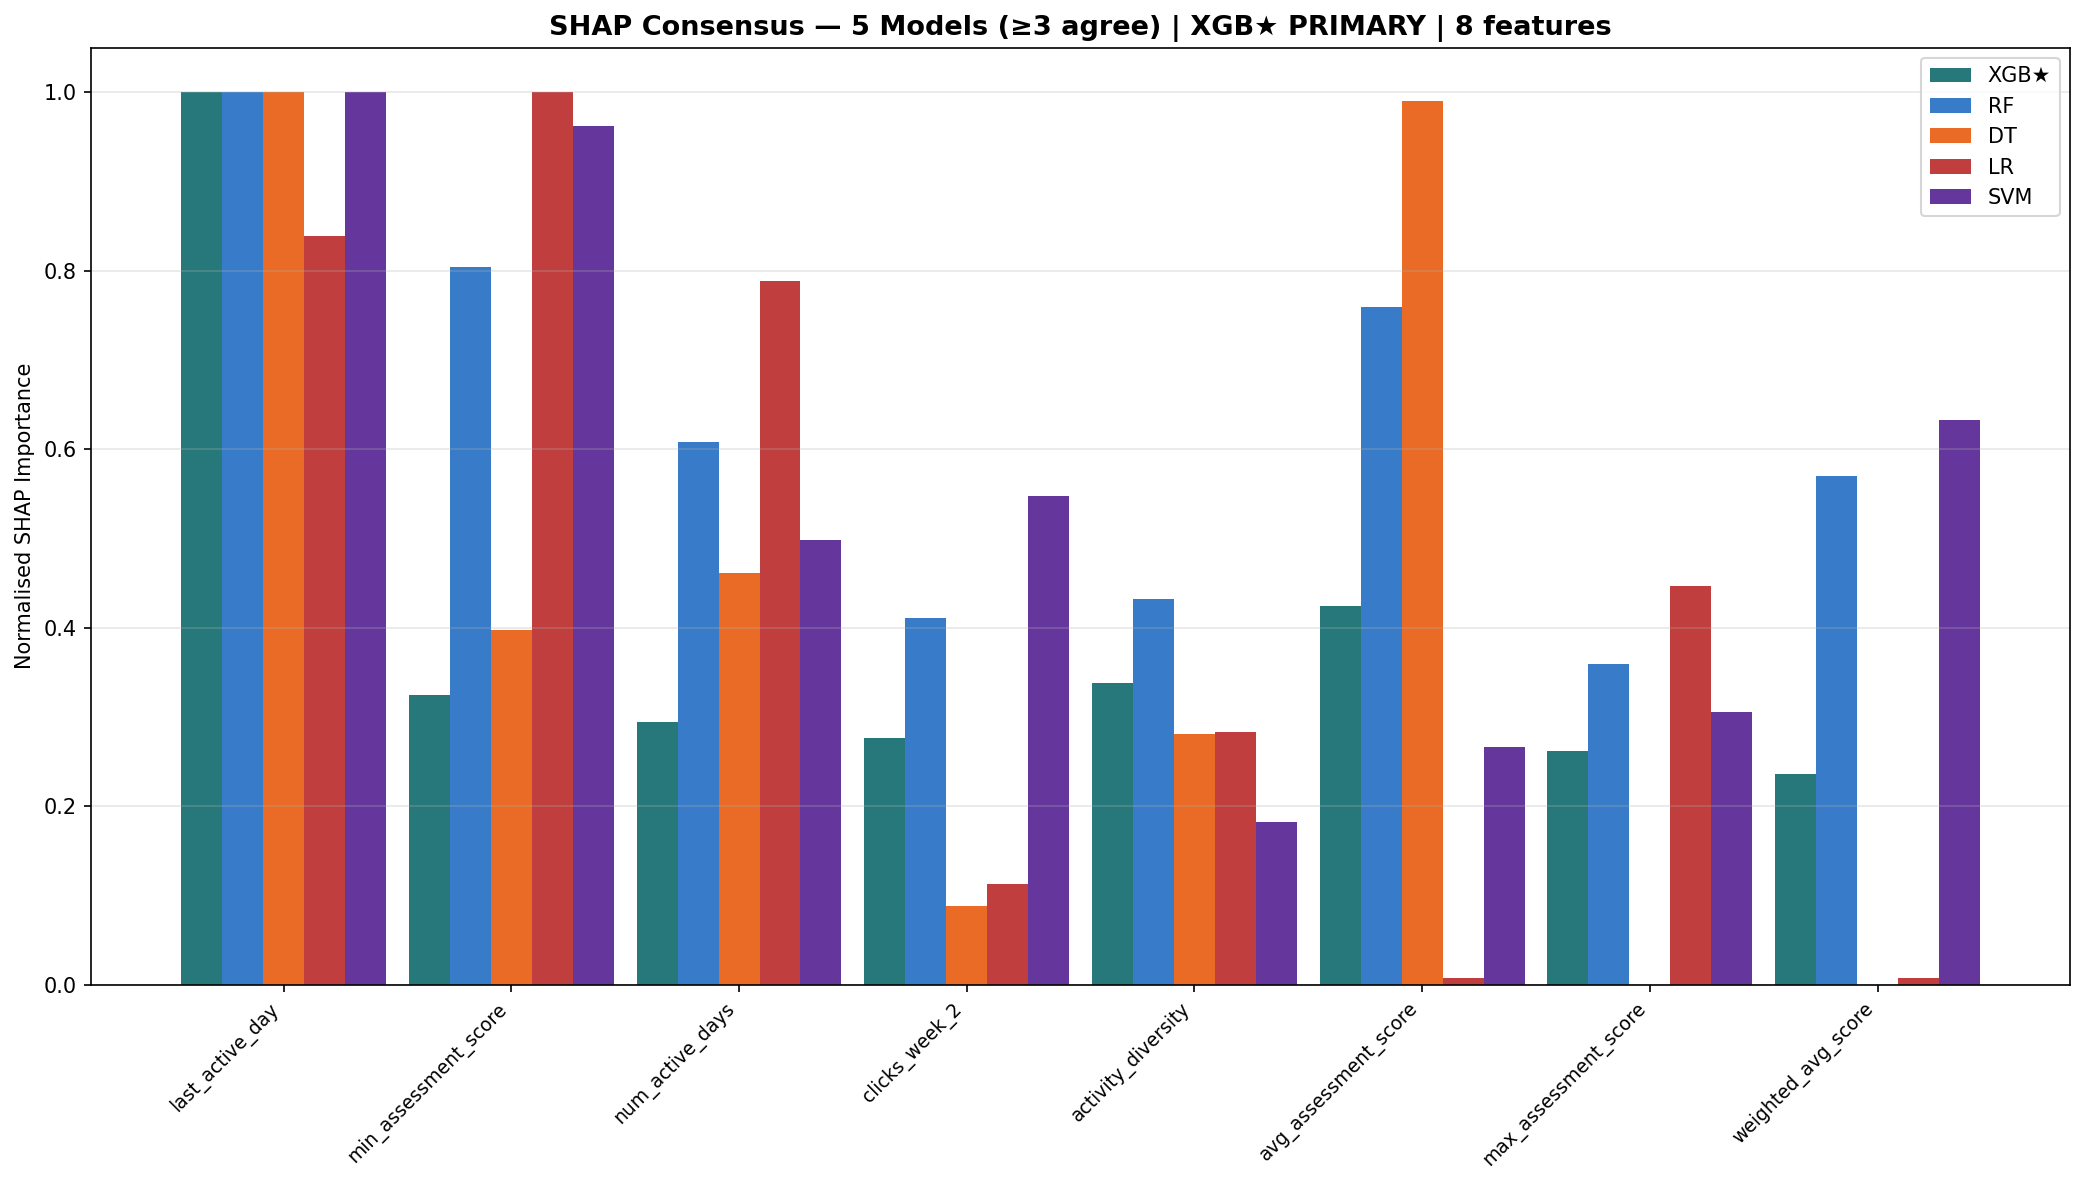

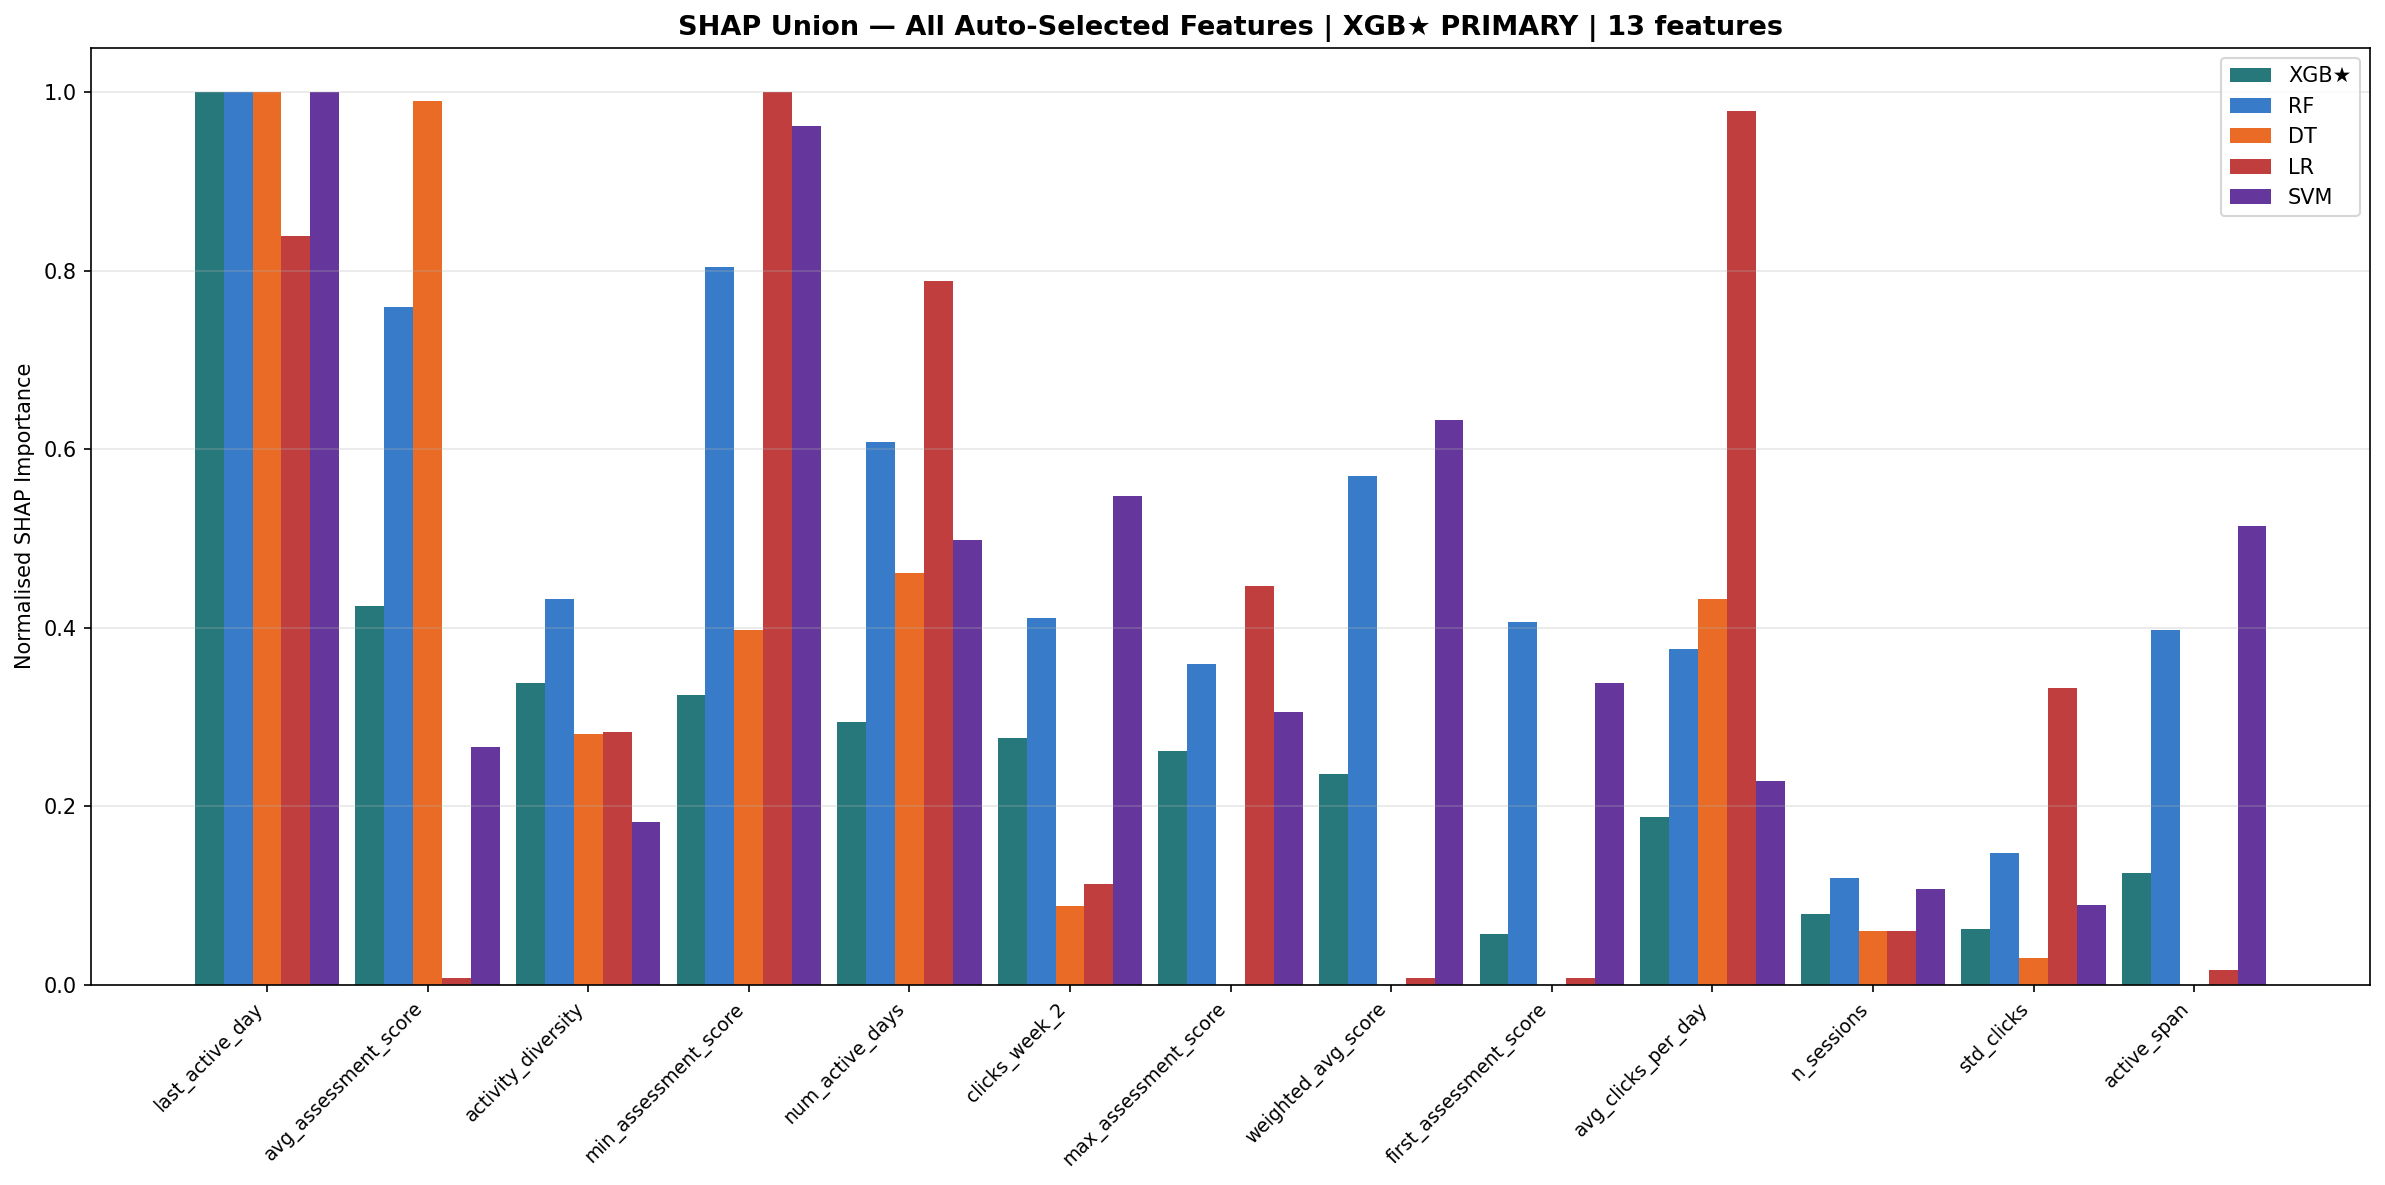

Consensus: 8 | Union: 13


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 15 — SHAP AUTO-SELECTED RANKINGS + CONSENSUS (All 5 Models)
# ════════════════════════════════════════════════════════════════════════════
def safe_shap_rank(sv, feature_names):
    sv = np.array(sv)
    if sv.ndim==1: raise ValueError(f'1D SHAP: {sv.shape}')
    if sv.ndim==2 and sv.shape[1]!=len(feature_names): raise ValueError(f'Shape mismatch: {sv.shape}')
    return pd.Series(np.abs(sv).mean(0),index=feature_names).sort_values(ascending=False)

shap_rank_xgb = safe_shap_rank(sv_xgb_p,FEATURE_NAMES_SEL)
shap_rank_rf  = safe_shap_rank(sv_rf_p, FEATURE_NAMES_SEL)
shap_rank_dt  = safe_shap_rank(sv_dt_p, FEATURE_NAMES_SEL)
shap_rank_lr  = safe_shap_rank(sv_lr_p, FEATURE_NAMES_SEL)
shap_rank_svm = safe_shap_rank(sv_svm_p,FEATURE_NAMES_SEL)

def auto_select_shap(s, min_f=MIN_FEATURES):
    sel = s[s>=s.mean()+s.std()]
    return sel if len(sel)>=min_f else s.iloc[:min_f]

auto_shap_xgb = auto_select_shap(shap_rank_xgb)
auto_shap_rf  = auto_select_shap(shap_rank_rf)
auto_shap_dt  = auto_select_shap(shap_rank_dt)
auto_shap_lr  = auto_select_shap(shap_rank_lr)
auto_shap_svm = auto_select_shap(shap_rank_svm)

print(f'Auto-selected: XGB={len(auto_shap_xgb)} RF={len(auto_shap_rf)} '
      f'DT={len(auto_shap_dt)} LR={len(auto_shap_lr)} SVM={len(auto_shap_svm)}')

for name,s in [('xgb',auto_shap_xgb),('rf',auto_shap_rf),('dt',auto_shap_dt),
               ('lr',auto_shap_lr),('svm',auto_shap_svm)]:
    s.to_csv(CSV_DIR/f'shap_top_{name}.csv',header=['SHAP_Importance'])

all_feats = (list(auto_shap_xgb.index)+list(auto_shap_rf.index)+
             list(auto_shap_dt.index)+list(auto_shap_lr.index)+list(auto_shap_svm.index))
vote_count2  = Counter(all_feats)
consensus_feats = [f for f,c in sorted(vote_count2.items(),key=lambda x:-x[1]) if c>=3]
print(f'Consensus features (≥3 models): {len(consensus_feats)}')

model_ranks = [(shap_rank_xgb,'XGB★','#006064'),(shap_rank_rf,'RF','#1565C0'),
               (shap_rank_dt,'DT','#E65100'),(shap_rank_lr,'LR','#B71C1C'),
               (shap_rank_svm,'SVM','#4A148C')]
w = 0.18

# Consensus plot
fig,ax = plt.subplots(figsize=(max(14,len(consensus_feats)),8))
x = np.arange(len(consensus_feats))
for i,(rank,label,color) in enumerate(model_ranks):
    vals = [rank.get(f,0)/(rank.max()+1e-9) for f in consensus_feats]
    ax.bar(x+(i-2)*w,vals,w,label=label,color=color,alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f[:22] for f in consensus_feats],rotation=45,ha='right',fontsize=9)
ax.set_ylabel('Normalised SHAP Importance')
ax.set_title(f'SHAP Consensus — 5 Models (≥3 agree) | XGB★ PRIMARY | {len(consensus_feats)} features',
             fontsize=13,fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.savefig(FIGURES_DIR/'shap_consensus_features.png',dpi=150,bbox_inches='tight'); plt.show()

# Union plot
all_top_feats = list(dict.fromkeys(all_feats))
fig,ax = plt.subplots(figsize=(max(16,len(all_top_feats)),8))
x = np.arange(len(all_top_feats))
for i,(rank,label,color) in enumerate(model_ranks):
    vals = [rank.get(f,0)/(rank.max()+1e-9) for f in all_top_feats]
    ax.bar(x+(i-2)*w,vals,w,label=label,color=color,alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f[:22] for f in all_top_feats],rotation=45,ha='right',fontsize=9)
ax.set_ylabel('Normalised SHAP Importance')
ax.set_title(f'SHAP Union — All Auto-Selected Features | XGB★ PRIMARY | {len(all_top_feats)} features',
             fontsize=13,fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.savefig(FIGURES_DIR/'shap_all_models_comparison.png',dpi=150,bbox_inches='tight'); plt.show()
print(f'Consensus: {len(consensus_feats)} | Union: {len(all_top_feats)}')


XGBoost — TP=4087  TN=4075  FP=1382  FN=1716
Total cases: 10

Generating XGBoost waterfall plots …


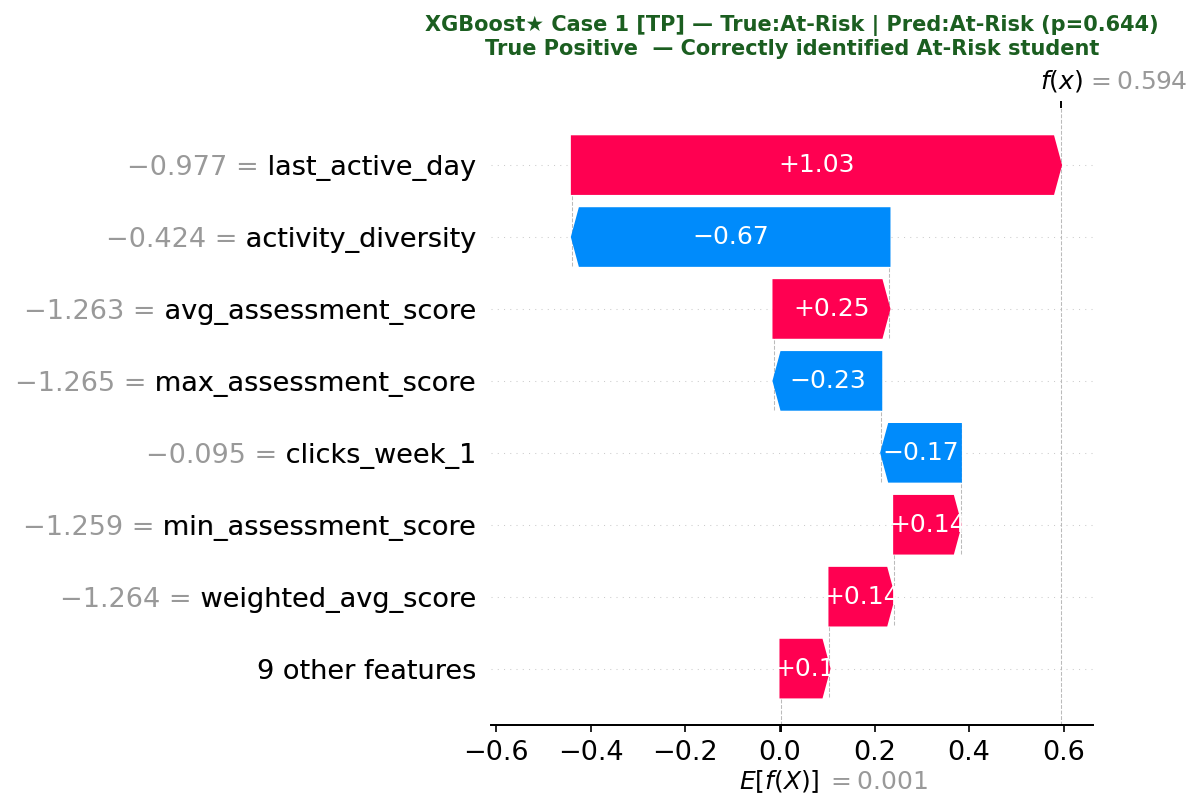

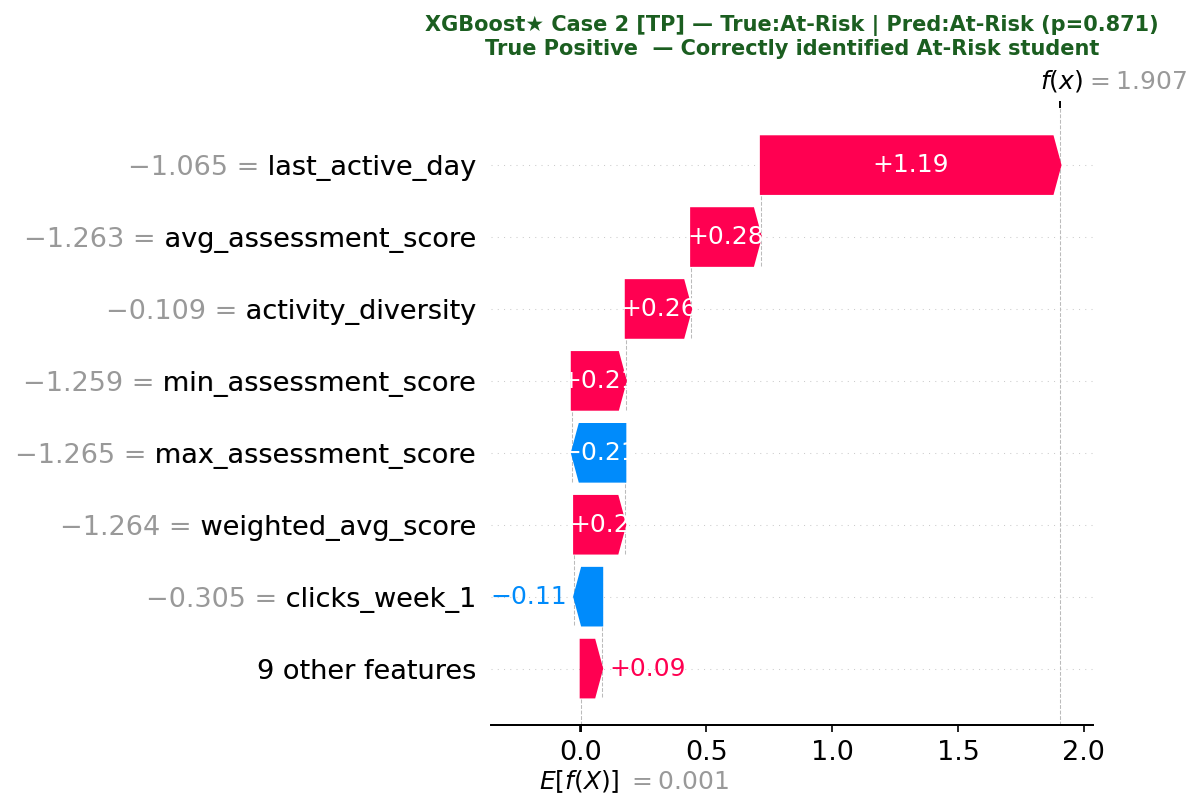

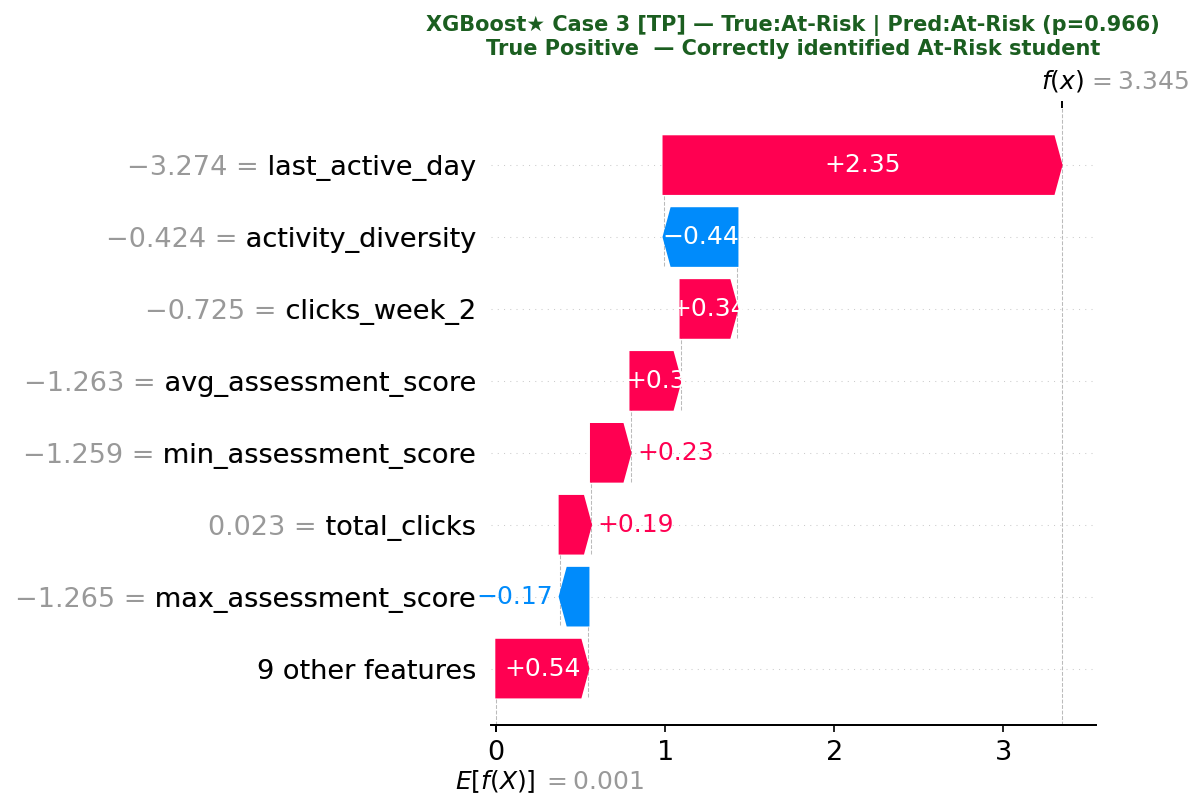

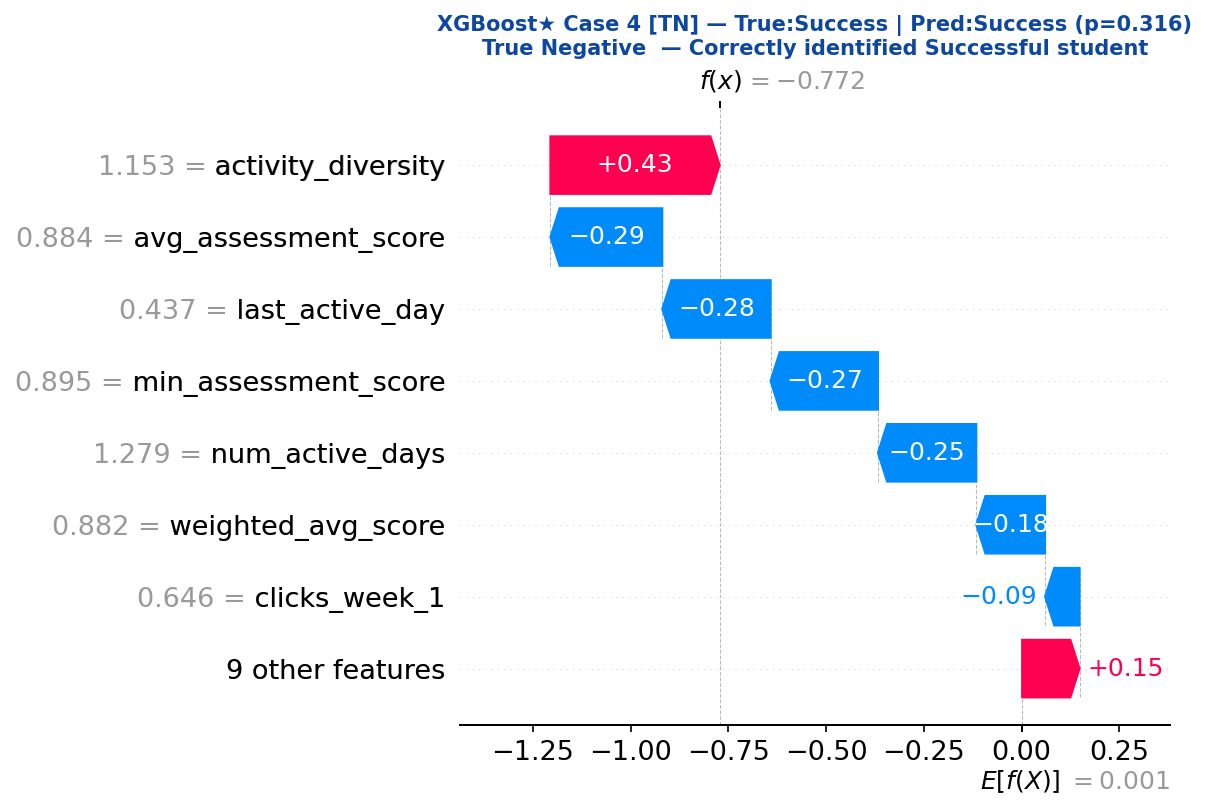

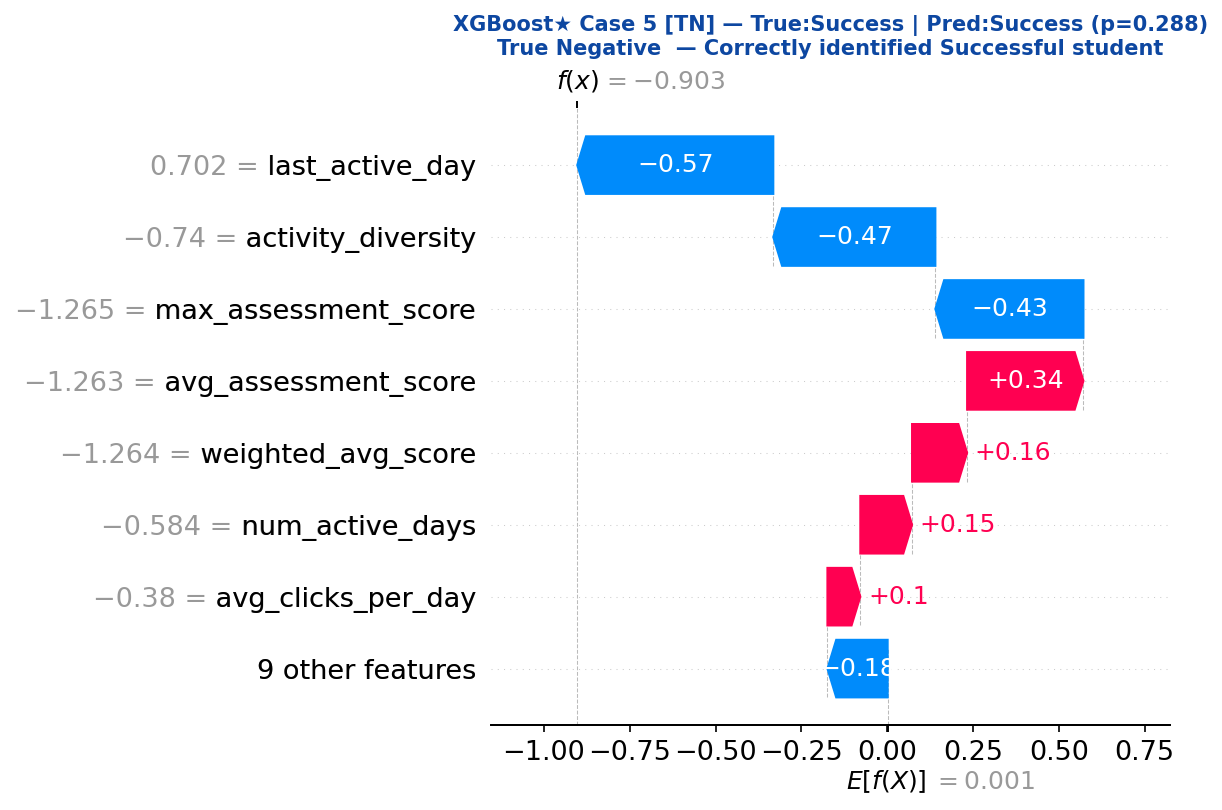

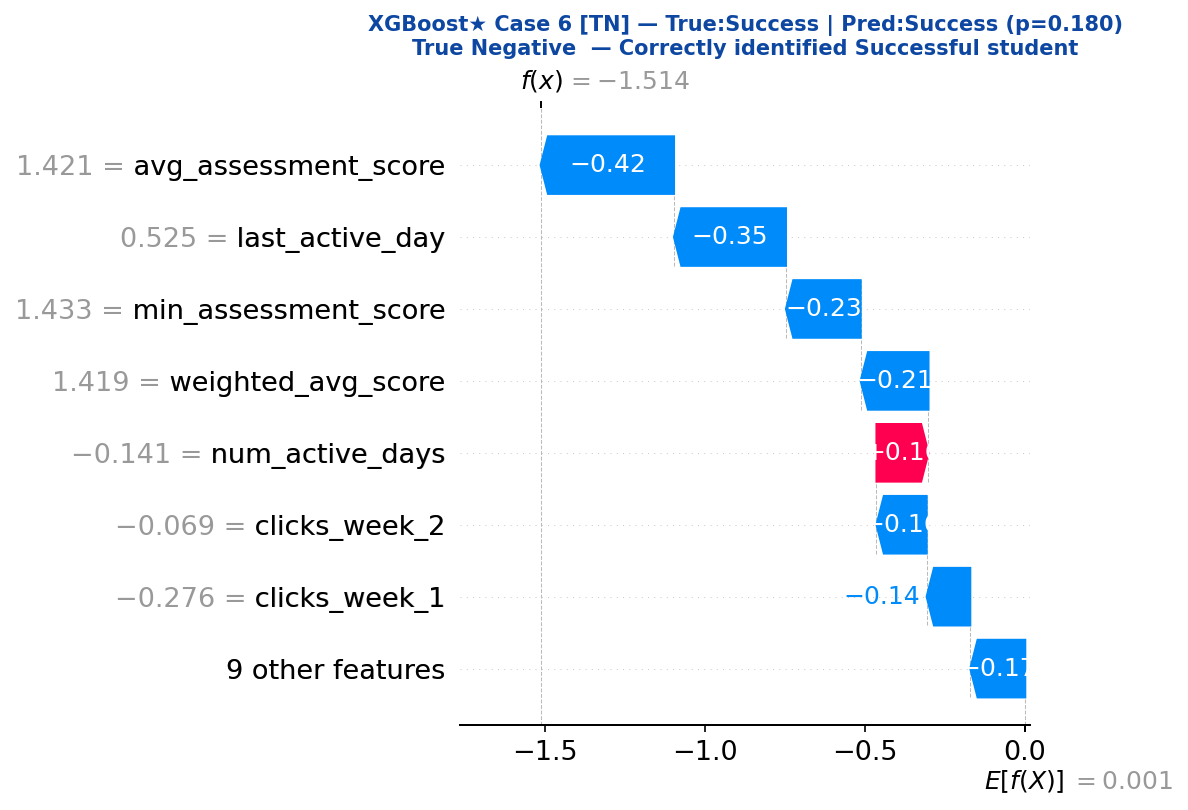

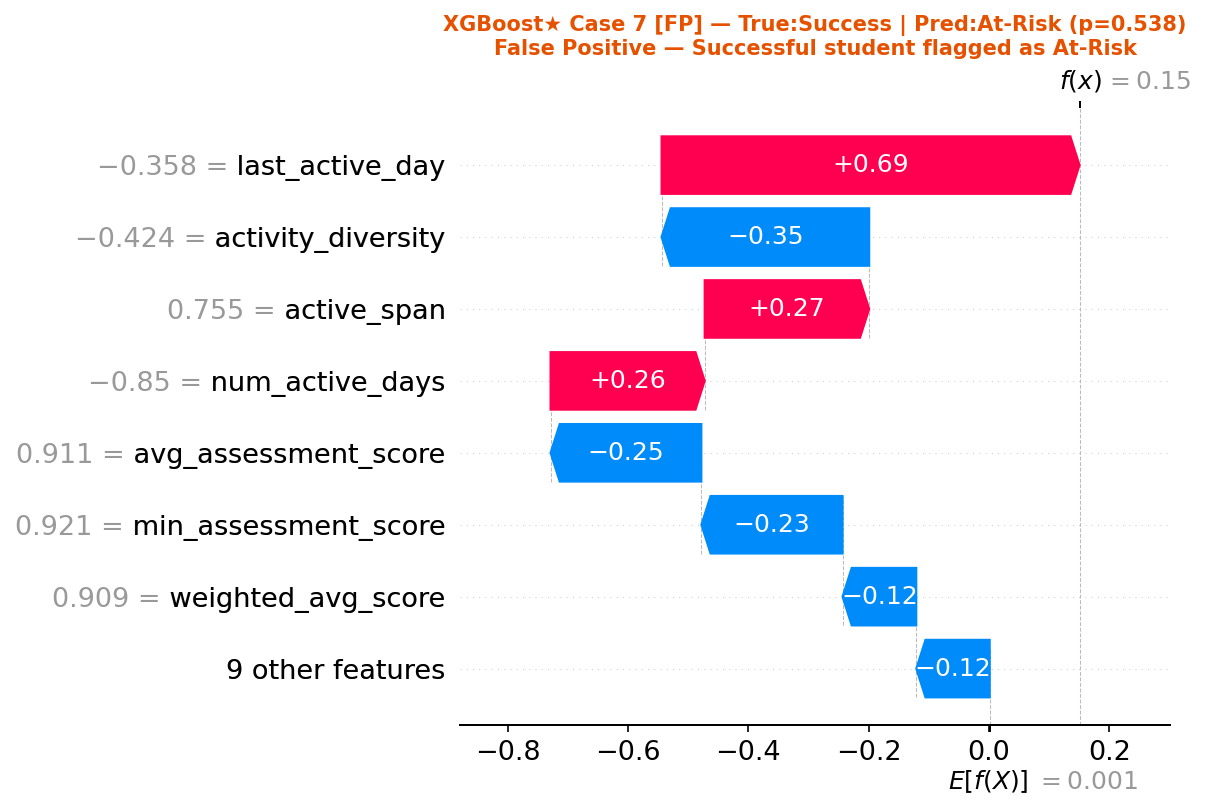

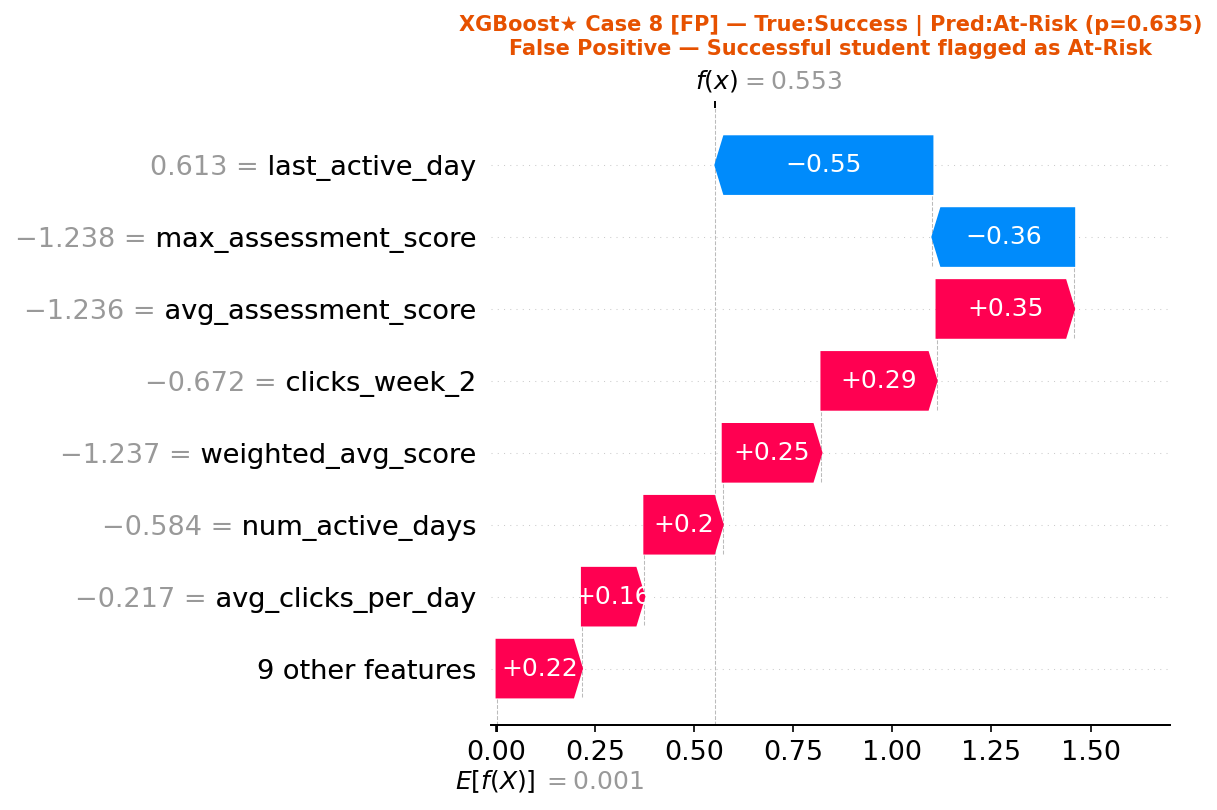

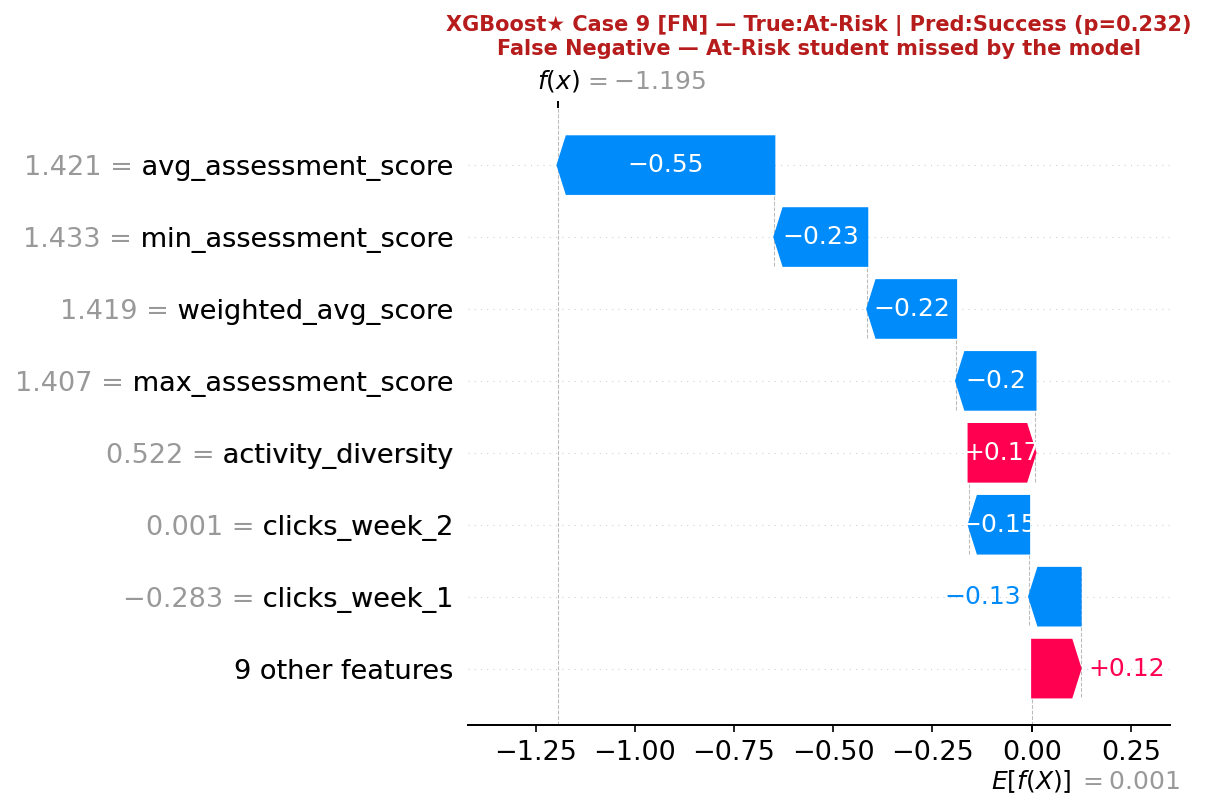

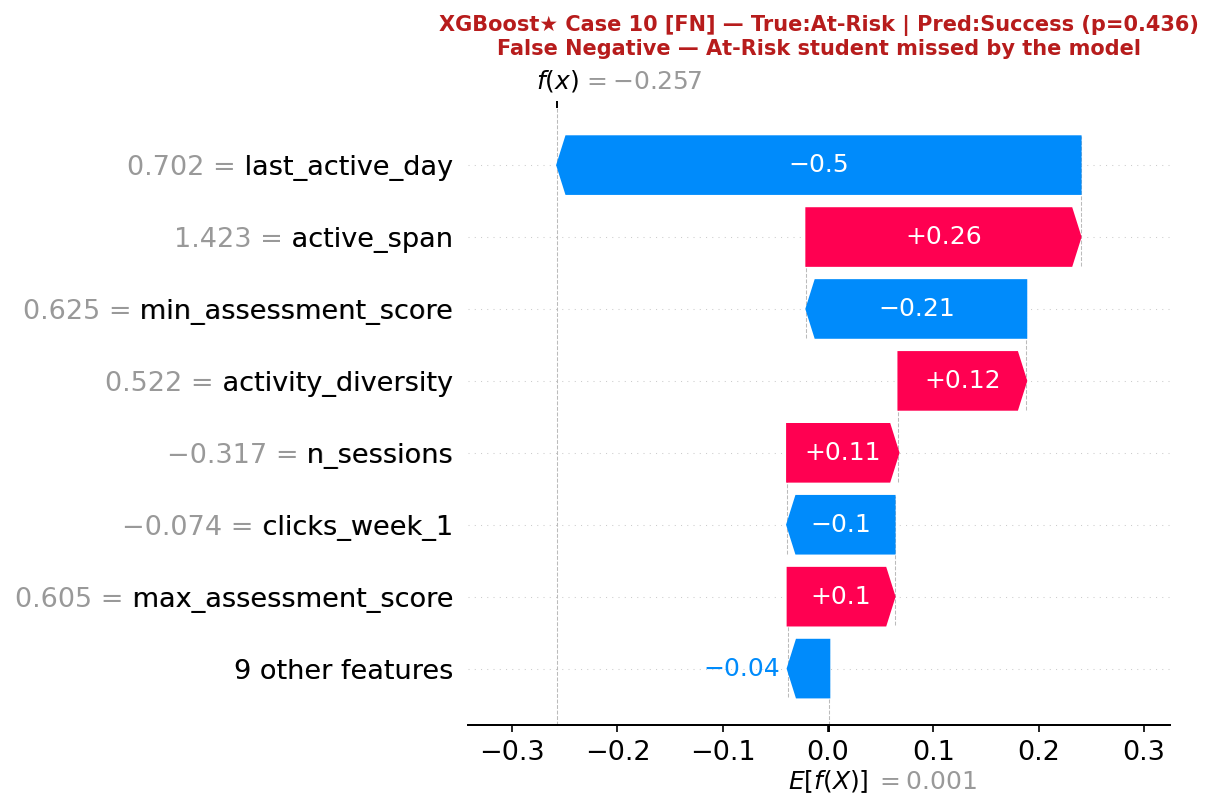

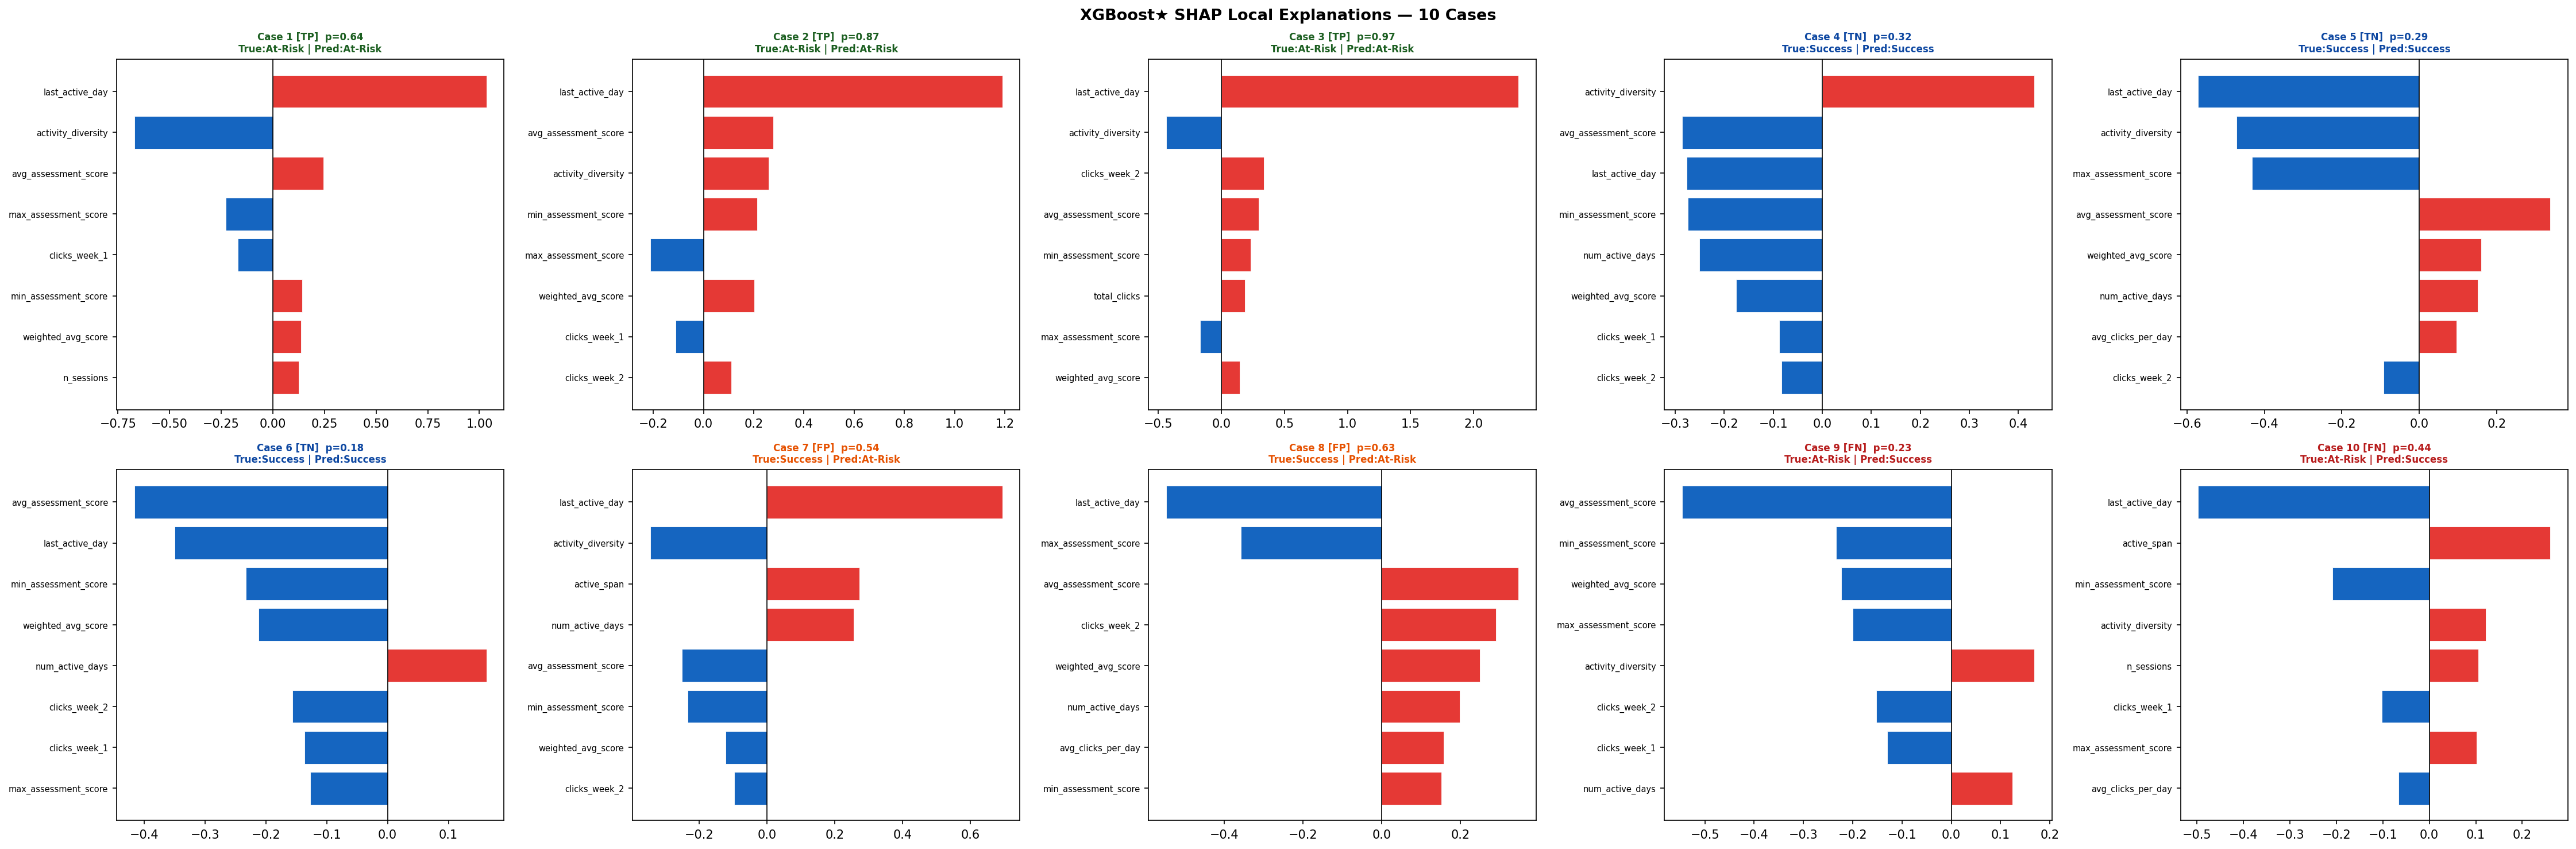

SHAP local done.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 16 — SHAP LOCAL EXPLANATIONS (10 cases: TP/TN/FP/FN)
# ════════════════════════════════════════════════════════════════════════════
np.random.seed(SEED)
# Apply Youden's J optimal threshold

y_prob_xgb = primary_model.predict_proba(X_test_sel)[:,1]
y_pred_xgb = (y_prob_xgb >= best_j_thr).astype(int)  # Youden's J threshold

tp_idx = np.where((y_test_arr==1)&(y_pred_xgb==1))[0]
tn_idx = np.where((y_test_arr==0)&(y_pred_xgb==0))[0]
fp_idx = np.where((y_test_arr==0)&(y_pred_xgb==1))[0]
fn_idx = np.where((y_test_arr==1)&(y_pred_xgb==0))[0]
print(f'XGBoost — TP={len(tp_idx)}  TN={len(tn_idx)}  FP={len(fp_idx)}  FN={len(fn_idx)}')

def stratified_pick(idx_arr,n,probs,seed_offset=0):
    np.random.seed(SEED+seed_offset)
    if len(idx_arr)==0: return []
    if len(idx_arr)<=n: return list(idx_arr)
    order=np.argsort(probs[idx_arr]); bands=np.array_split(order,n)
    return [idx_arr[np.random.choice(b)] for b in bands]

picked_tp = stratified_pick(tp_idx,3,y_prob_xgb,0)
picked_tn = stratified_pick(tn_idx,3,1-y_prob_xgb,1)
picked_fp = stratified_pick(fp_idx,2,y_prob_xgb,2)
picked_fn = stratified_pick(fn_idx,2,y_prob_xgb,3)
local_idx  = picked_tp+picked_tn+picked_fp+picked_fn
case_types = (['TP']*len(picked_tp)+['TN']*len(picked_tn)+
               ['FP']*len(picked_fp)+['FN']*len(picked_fn))
print(f'Total cases: {len(local_idx)}')

type_color = {'TP':'#1B5E20','TN':'#0D47A1','FP':'#E65100','FN':'#B71C1C'}
type_label = {
    'TP':'True Positive  — Correctly identified At-Risk student',
    'TN':'True Negative  — Correctly identified Successful student',
    'FP':'False Positive — Successful student flagged as At-Risk',
    'FN':'False Negative — At-Risk student missed by the model',
}

shap_exp_xgb = shap.Explanation(
    values      = sv_xgb_p,
    base_values = np.full(len(sv_xgb_p),ev_xgb),
    data        = X_te_xgb,
    feature_names = FEATURE_NAMES_SEL)

print('\nGenerating XGBoost waterfall plots …')
for i,(idx,ctype) in enumerate(zip(local_idx,case_types)):
    tl = 'At-Risk' if y_test_arr[idx]==1 else 'Success'
    pl = 'At-Risk' if y_pred_xgb[idx]==1 else 'Success'
    pp = y_prob_xgb[idx]
    plt.figure(figsize=(11,6))
    shap.plots.waterfall(shap_exp_xgb[idx],max_display=8,show=False)
    plt.title(f'XGBoost★ Case {i+1} [{ctype}] — True:{tl} | Pred:{pl} (p={pp:.3f})\n{type_label[ctype]}',
              fontsize=10,fontweight='bold',color=type_color[ctype])
    plt.tight_layout()
    plt.savefig(FIGURES_DIR/f'shap_local_xgb_case_{i+1}_{ctype}.png',dpi=300,bbox_inches='tight')
    plt.show(); plt.close()

# Summary grid
fig,axes = plt.subplots(2,5,figsize=(30,10)); axes=axes.flatten()
for i,(idx,ctype) in enumerate(zip(local_idx,case_types)):
    sv_i = sv_xgb_p[idx]; top8 = np.argsort(np.abs(sv_i))[-8:]
    axes[i].barh([FEATURE_NAMES_SEL[j][:22] for j in top8],[sv_i[j] for j in top8],
                 color=['#E53935' if v>0 else '#1565C0' for v in [sv_i[j] for j in top8]],
                 edgecolor='white',linewidth=0.4)
    axes[i].axvline(0,color='black',lw=0.8)
    axes[i].set_title(f'Case {i+1} [{ctype}]  p={y_prob_xgb[idx]:.2f}\n'
                      f'True:{"At-Risk" if y_test_arr[idx]==1 else "Success"} | '
                      f'Pred:{"At-Risk" if y_pred_xgb[idx]==1 else "Success"}',
                      fontsize=8,fontweight='bold',color=type_color[ctype])
    axes[i].tick_params(axis='y',labelsize=7)
plt.suptitle('XGBoost★ SHAP Local Explanations — 10 Cases',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'shap_local_xgb_10cases.png',dpi=150,bbox_inches='tight')
plt.show()
print('SHAP local done.')


10 LIME explanations: 0.4s
Generating LIME local explanation plots (native LIME style) …


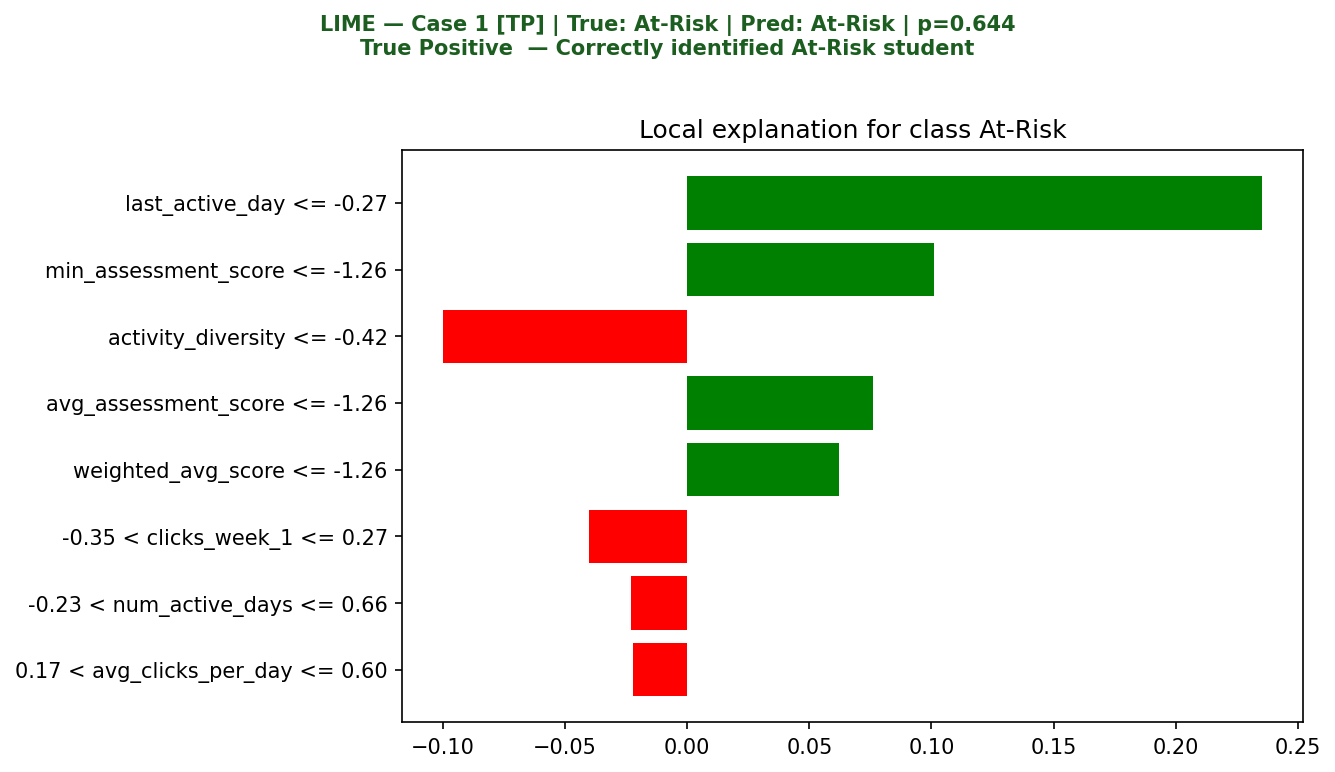

  Case 1 [TP] saved.


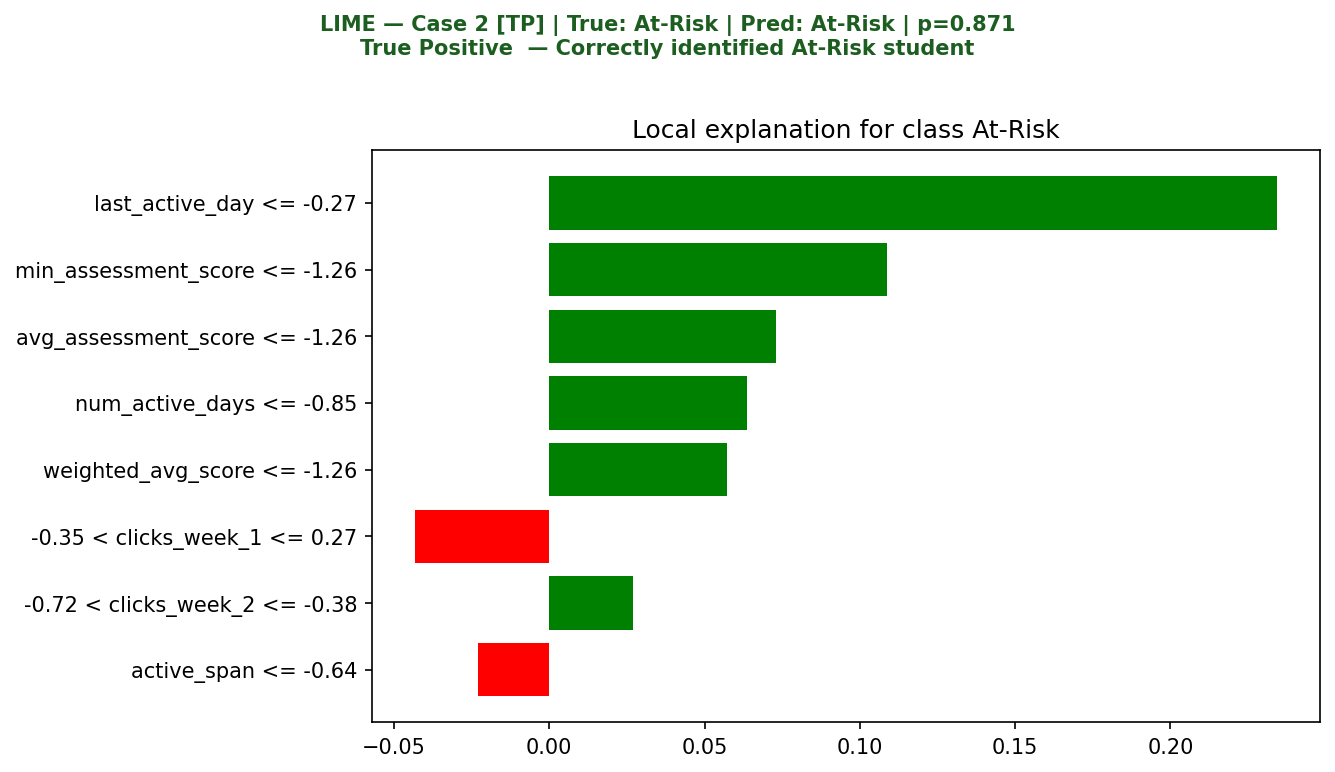

  Case 2 [TP] saved.


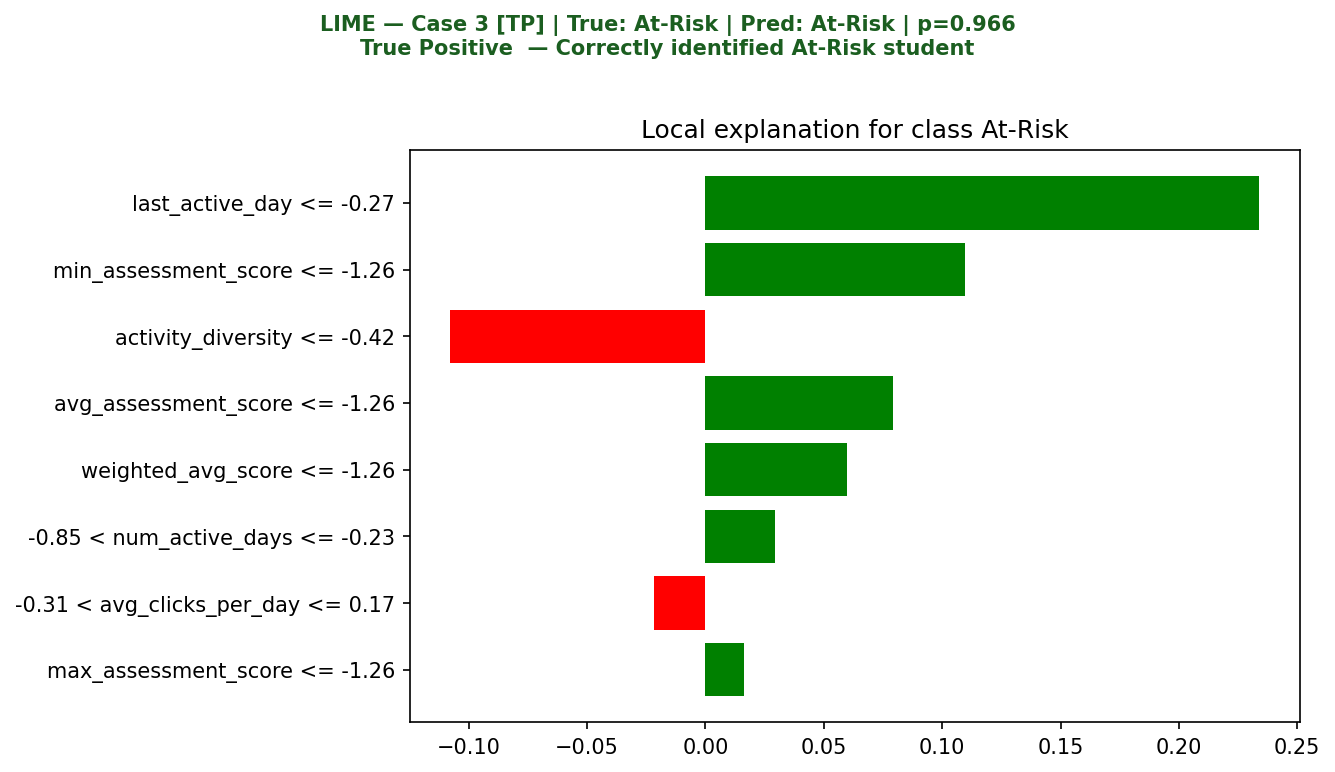

  Case 3 [TP] saved.


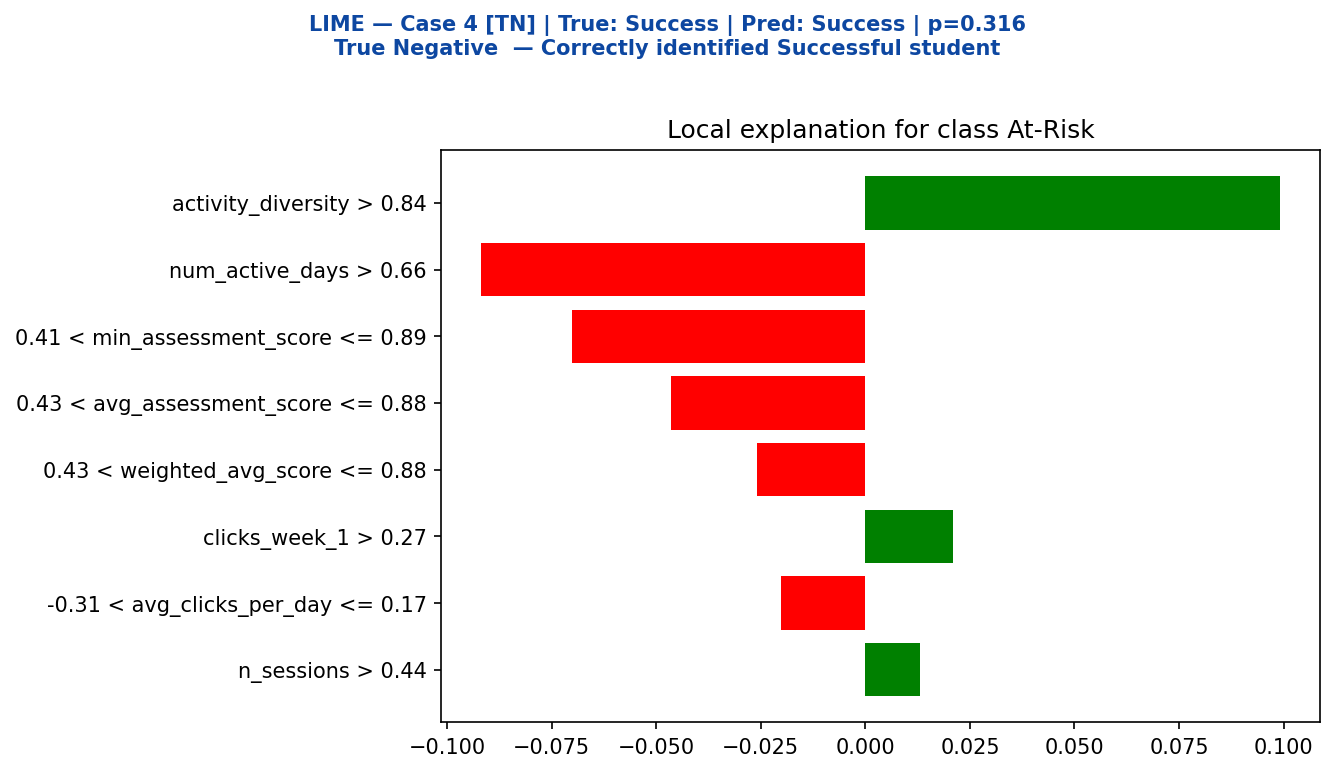

  Case 4 [TN] saved.


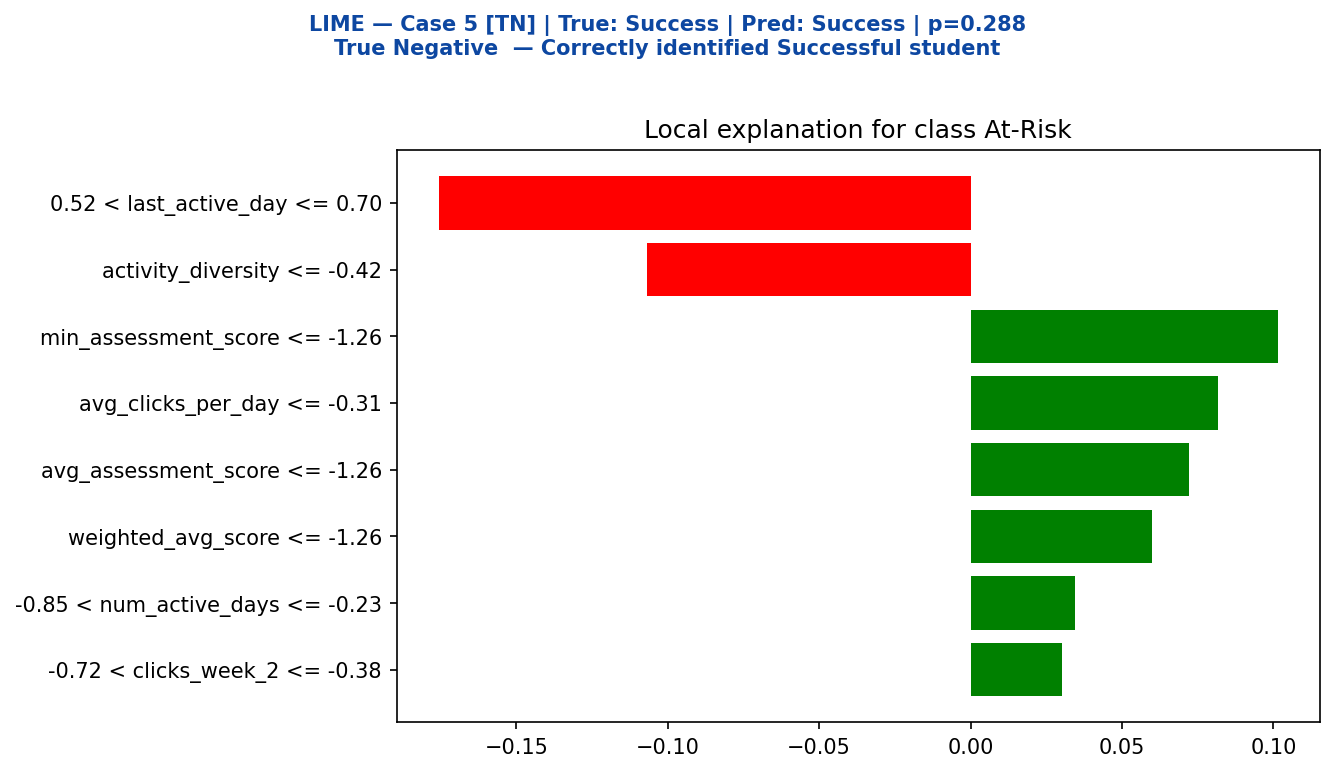

  Case 5 [TN] saved.


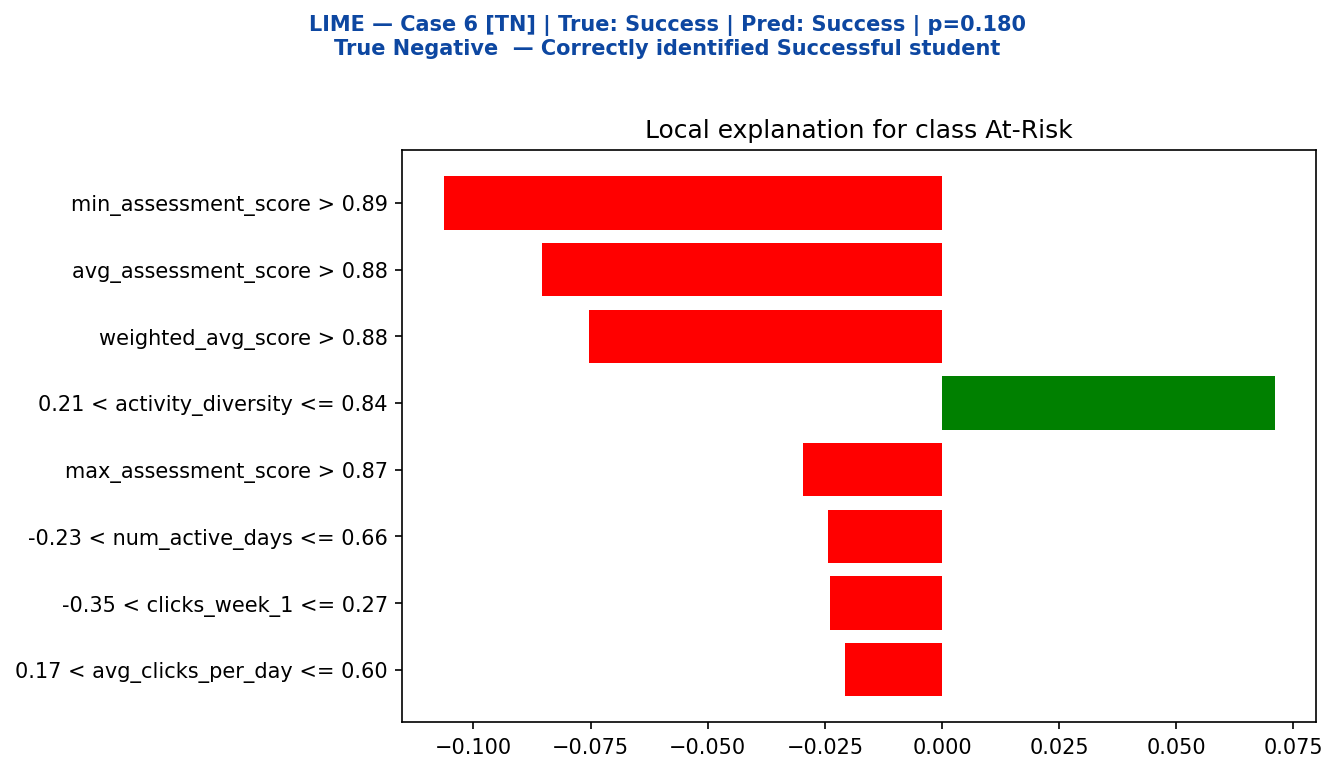

  Case 6 [TN] saved.


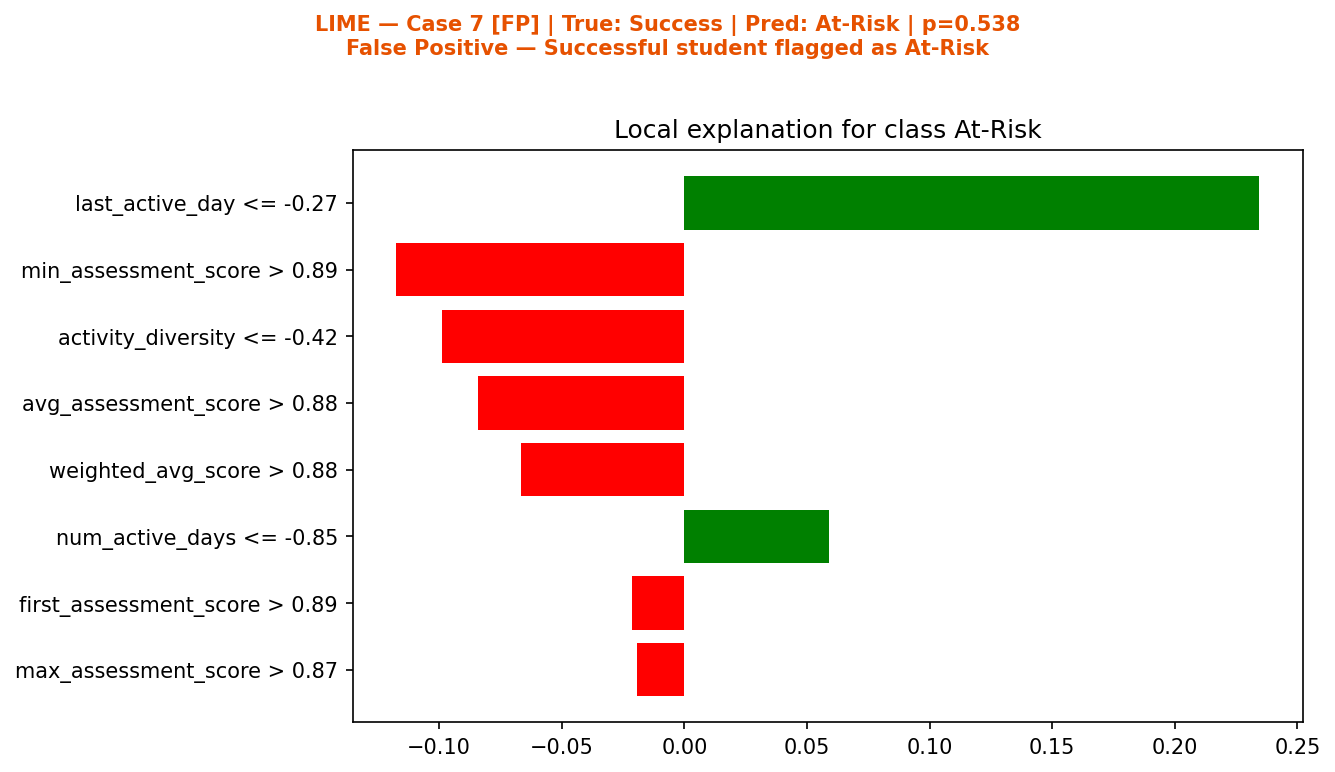

  Case 7 [FP] saved.


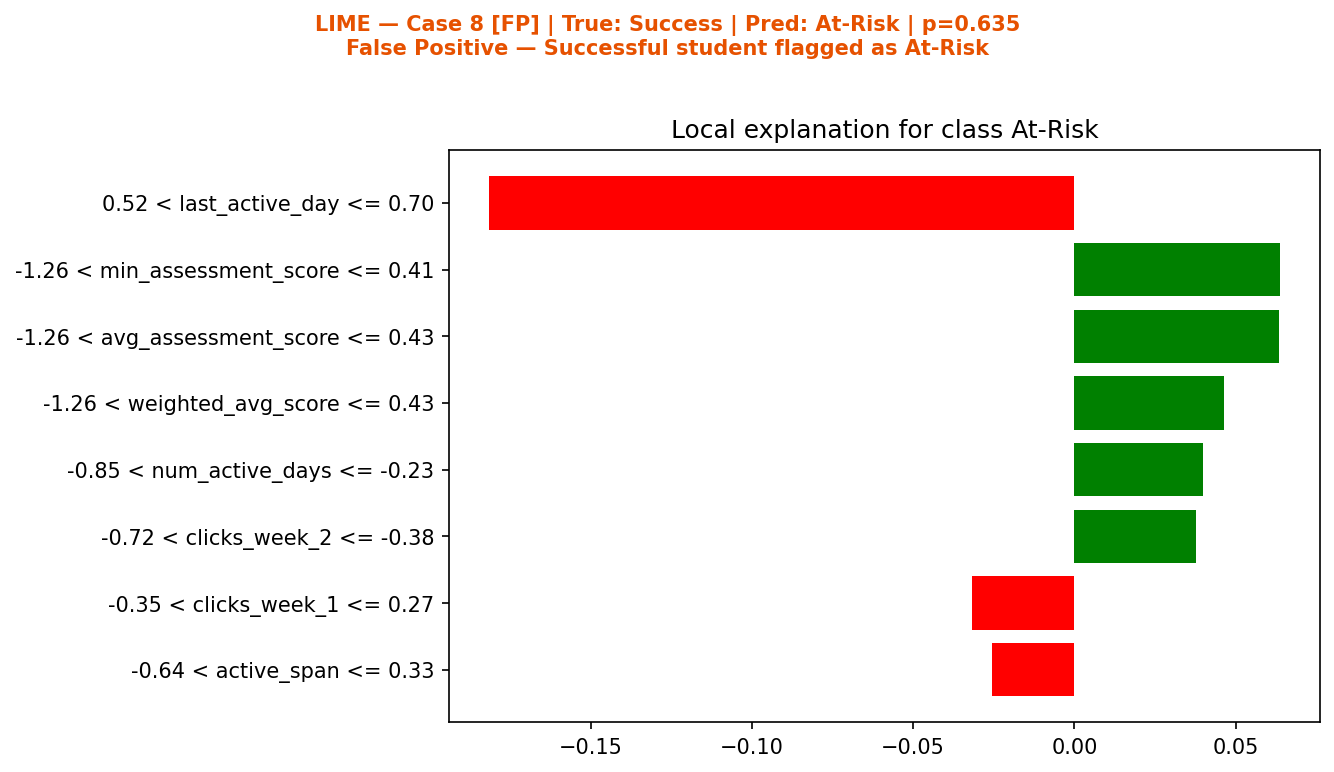

  Case 8 [FP] saved.


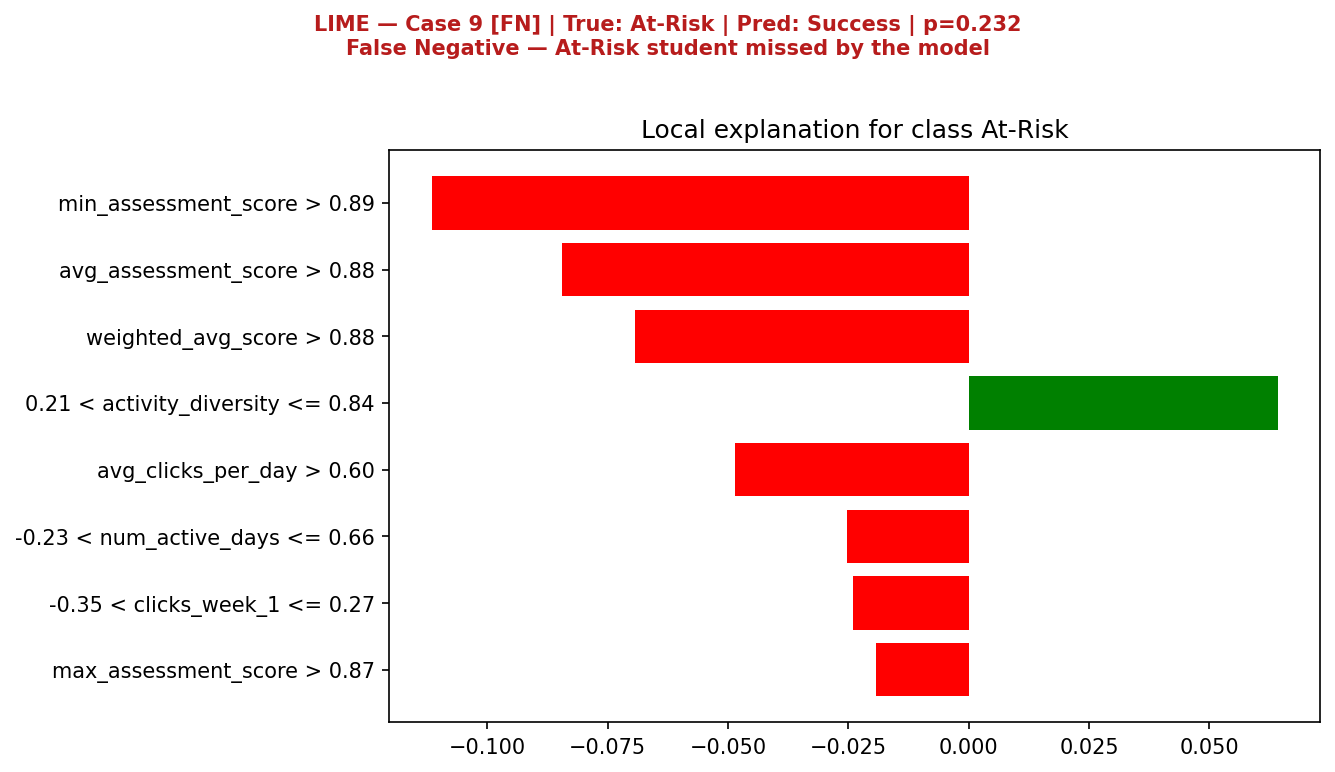

  Case 9 [FN] saved.


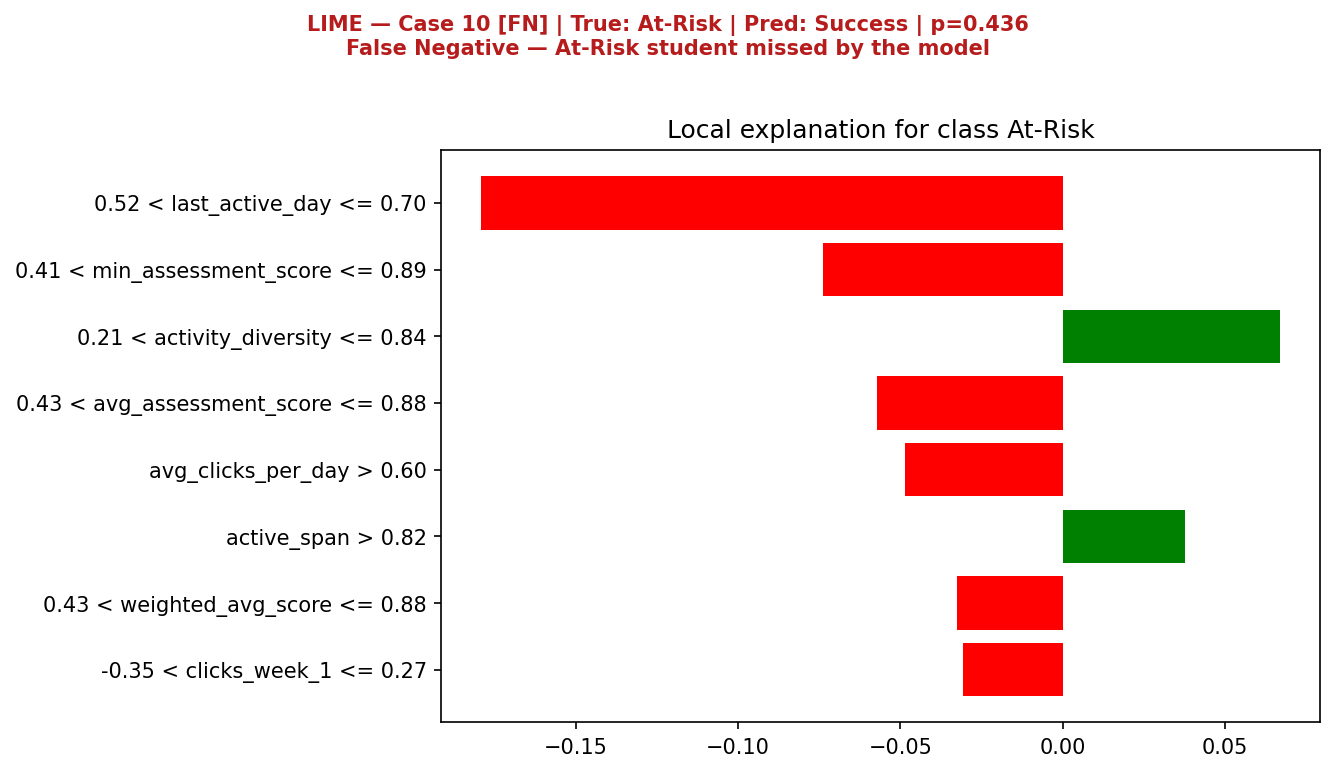

  Case 10 [FN] saved.


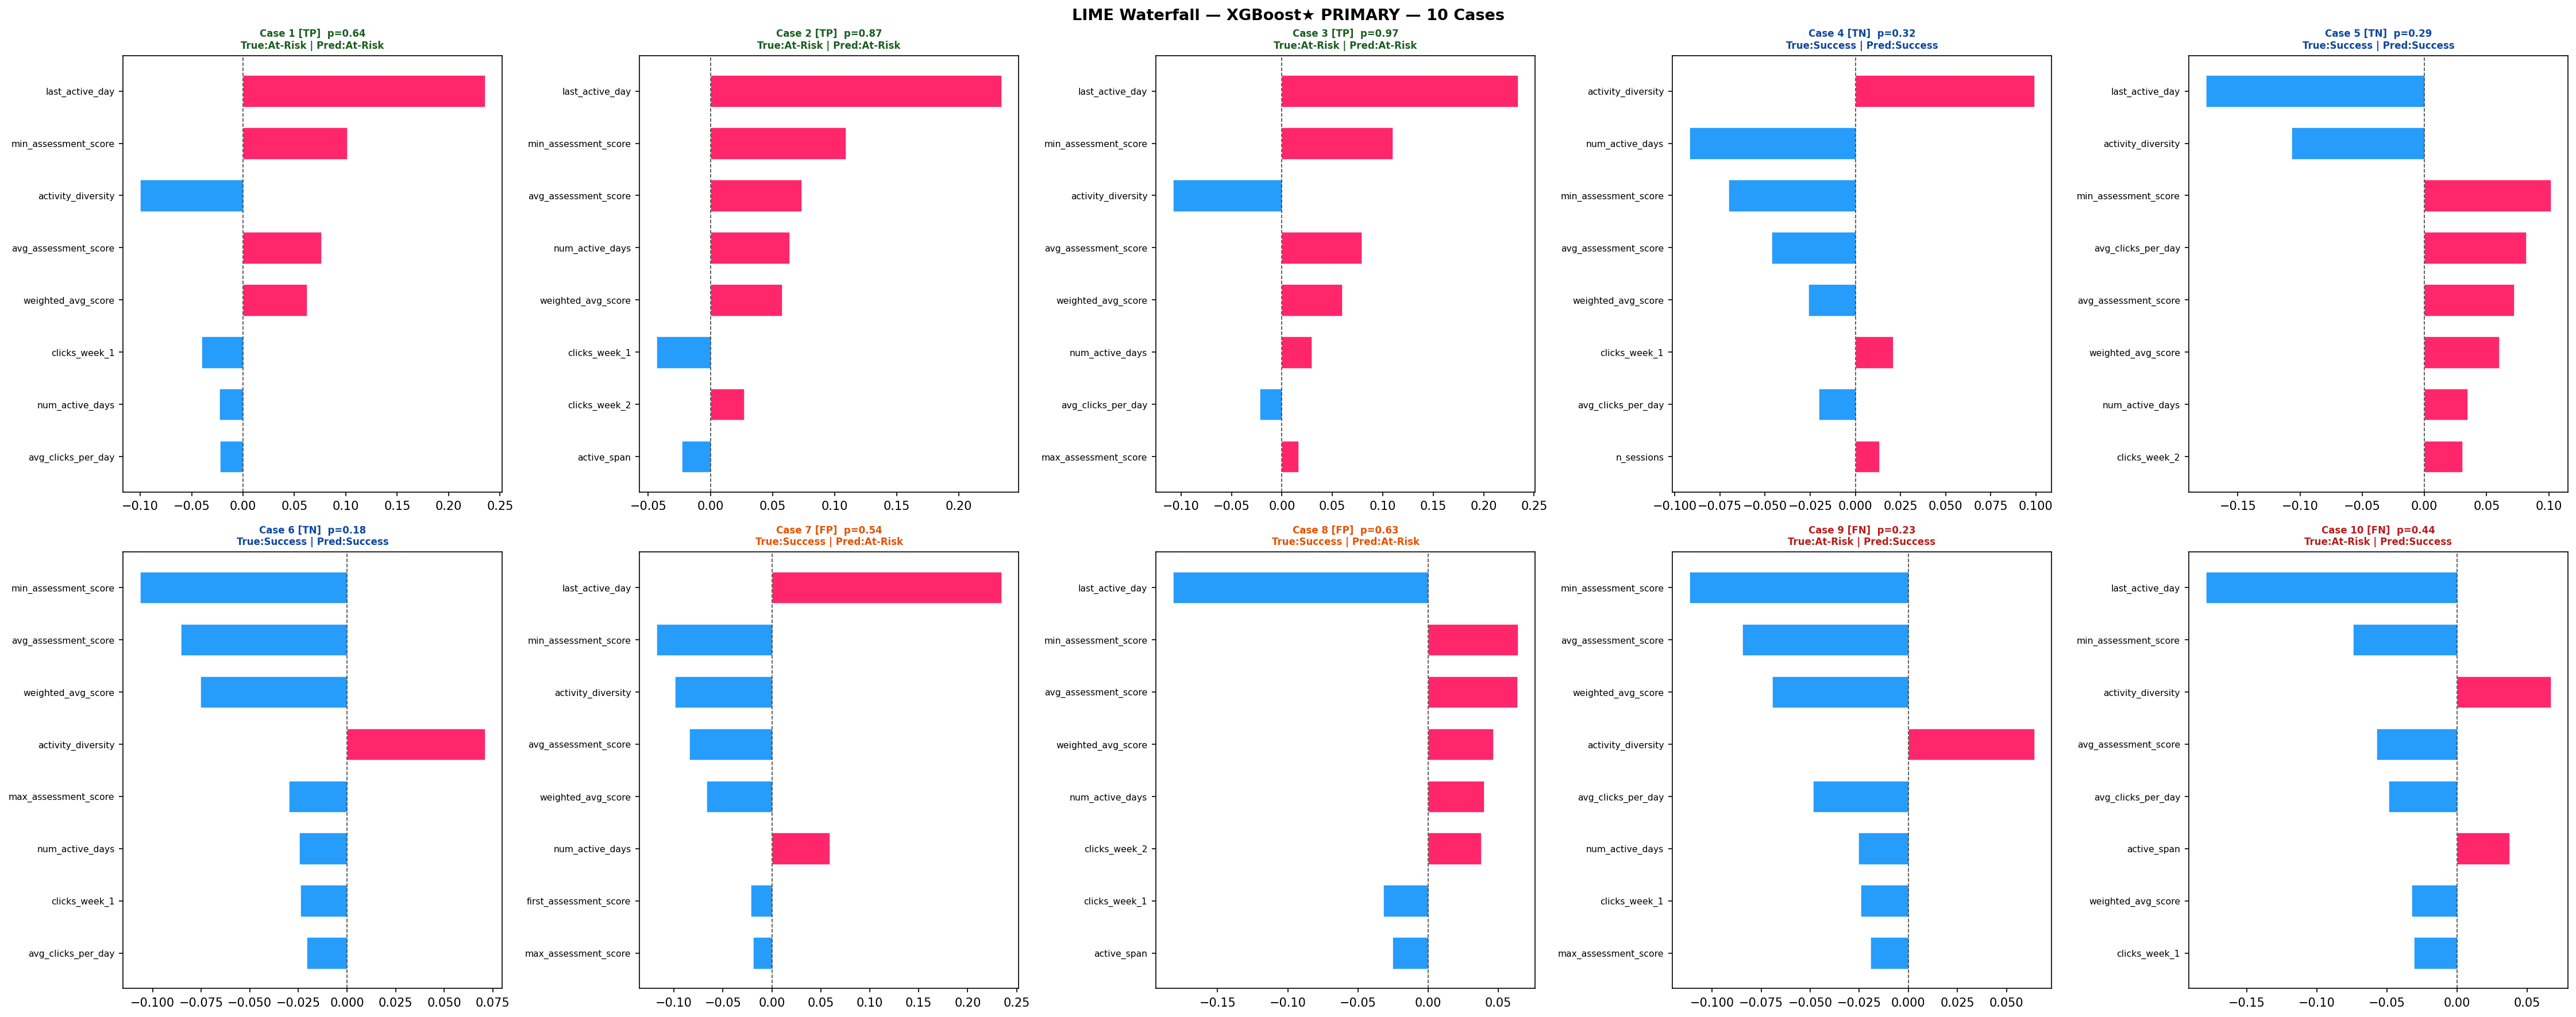


Global LIME — all 5 models (200 samples each) …
Global LIME done.
LIME auto-selected: XGB=8 RF=8 DT=8 LR=8 SVM=8


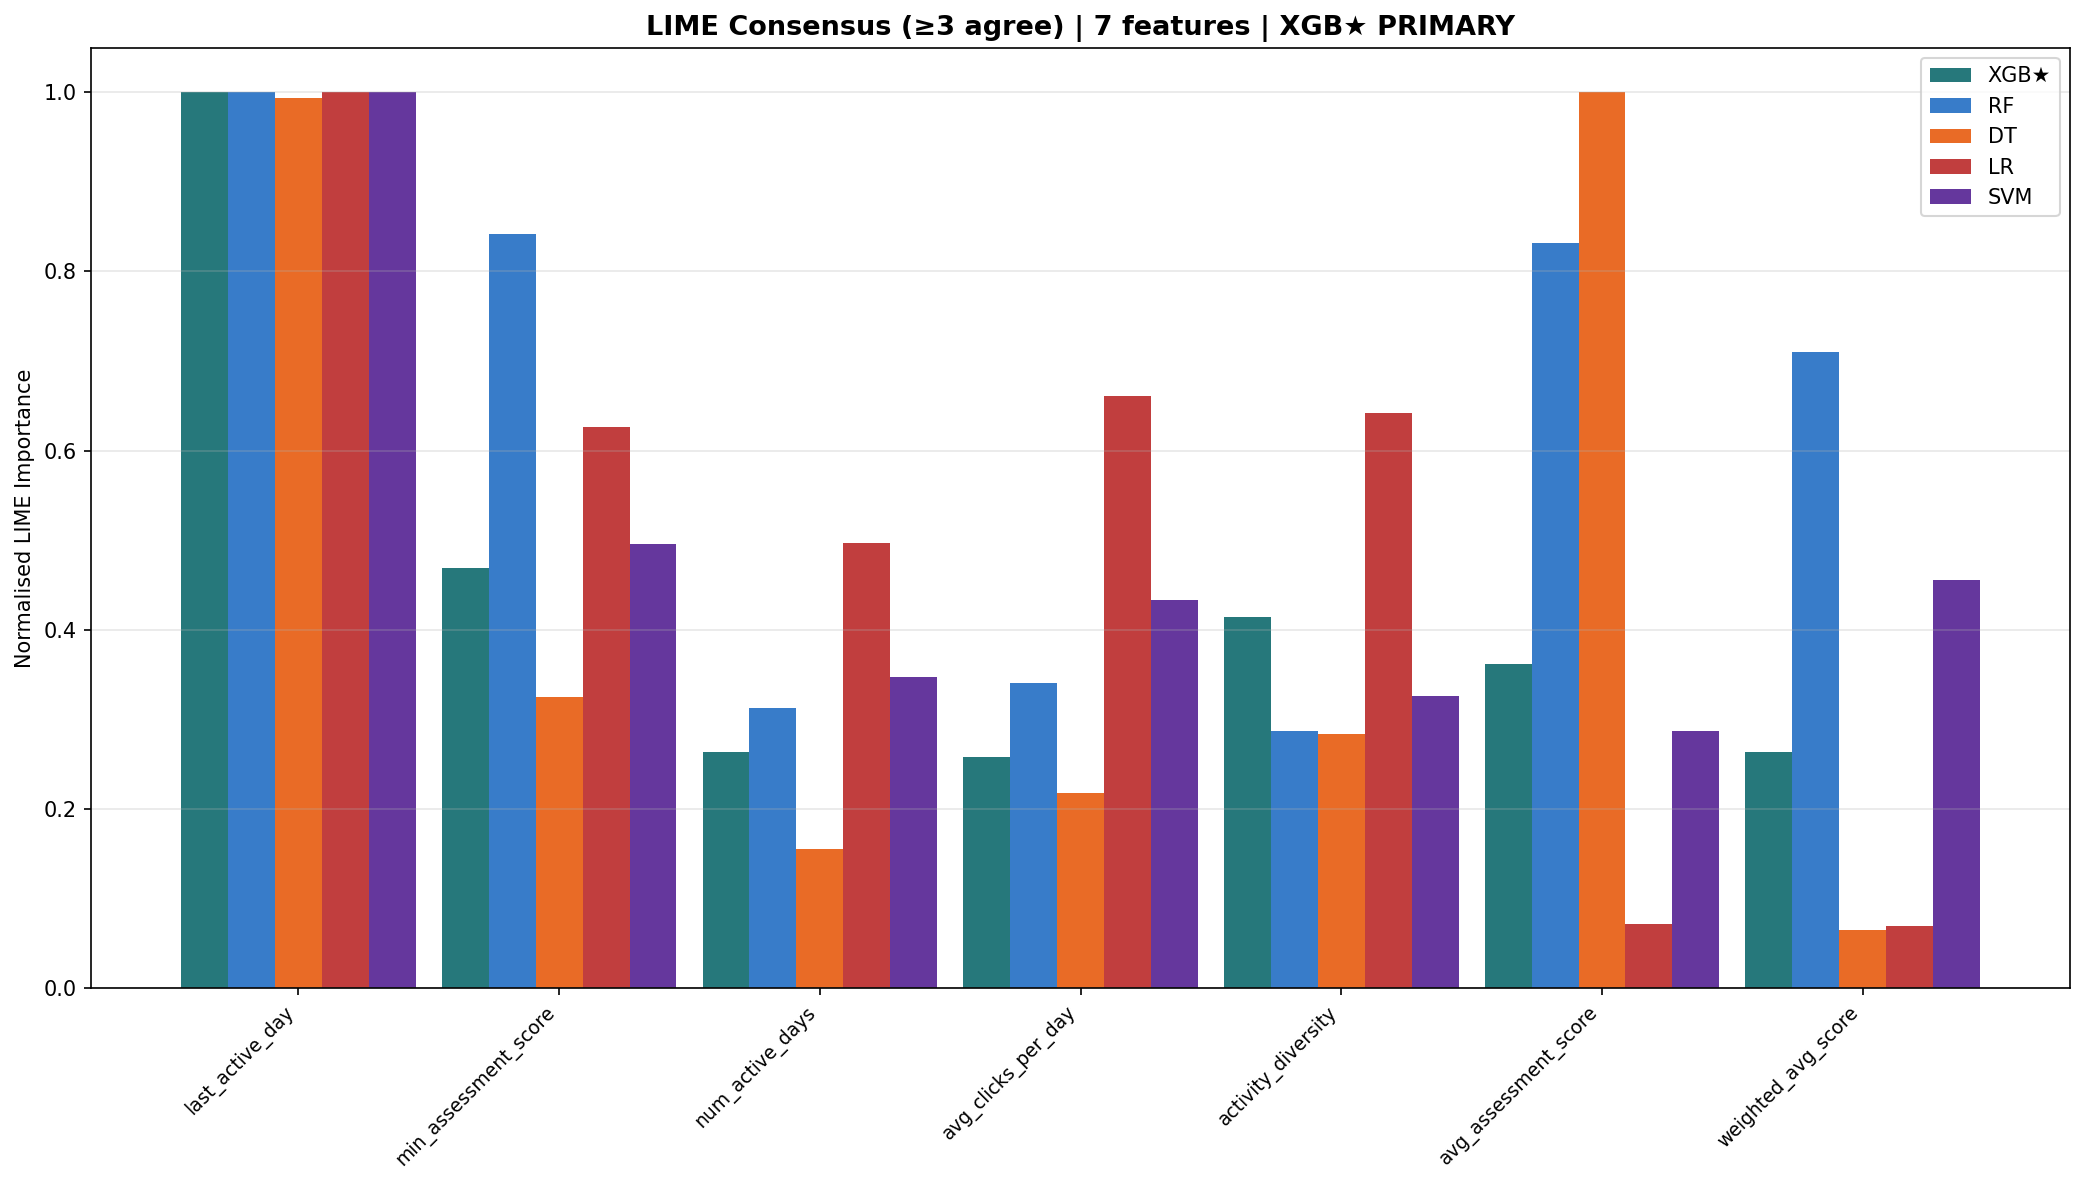

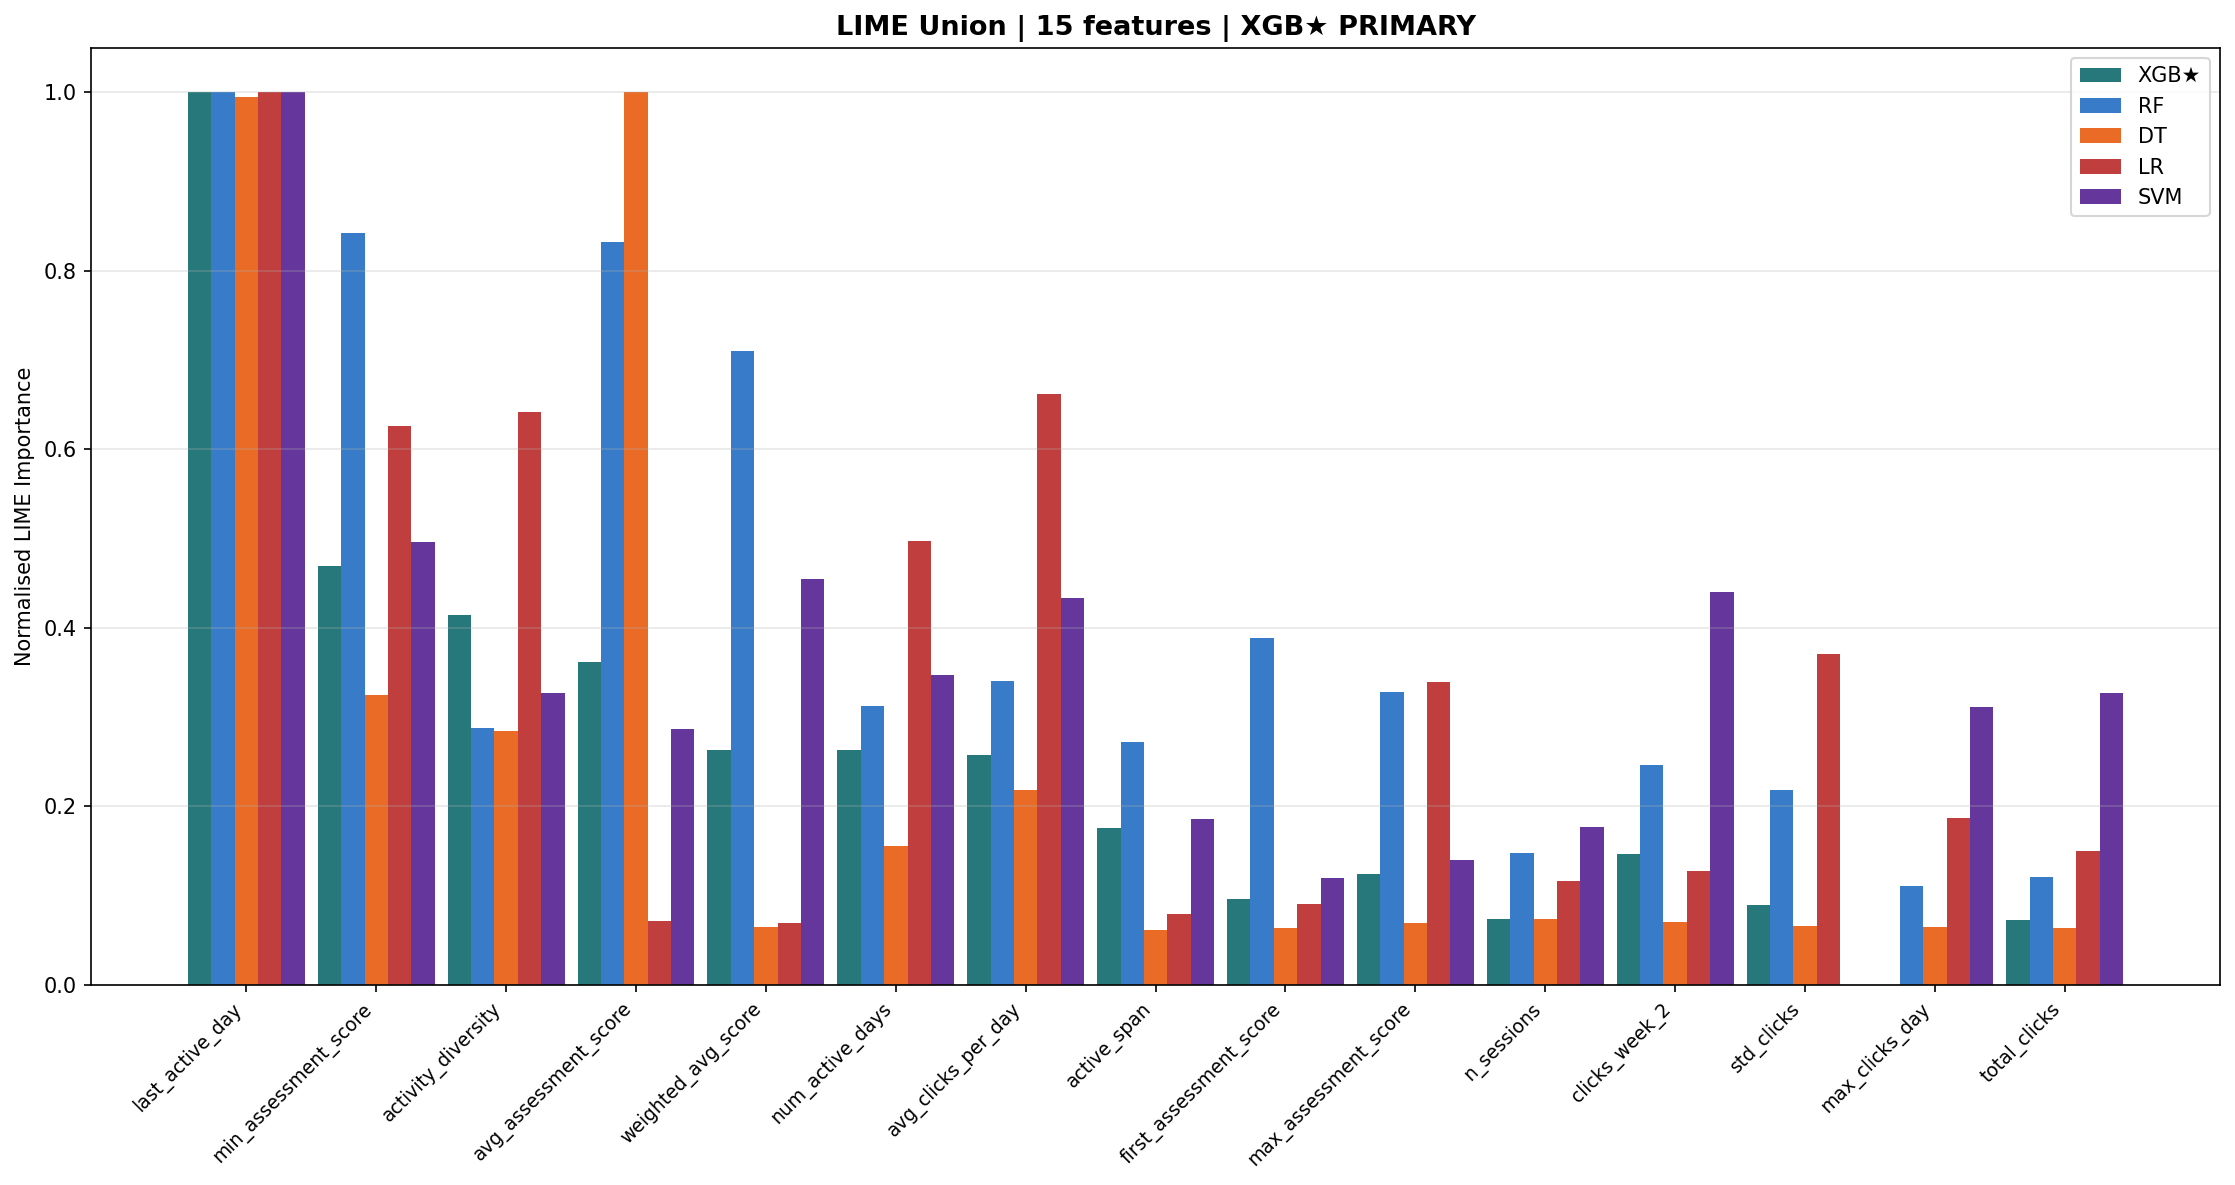

LIME analysis done.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 17 — LIME ANALYSIS — XGBoost★ PRIMARY
# ════════════════════════════════════════════════════════════════════════════
lime_exp = lime_tabular.LimeTabularExplainer(
    X_tr_p,feature_names=FEATURE_NAMES_SEL,
    class_names=['Success','At-Risk'],mode='classification',random_state=SEED)

def lime_fn(x): return xgb_pipe.named_steps['clf'].predict_proba(x)

LIME_POS = '#FF0051'; LIME_NEG = '#008BFB'

X_test_orig = pd.DataFrame(
    scl_global.inverse_transform(imp_global.transform(
        X_test_sel.reset_index(drop=True) if hasattr(X_test_sel,'reset_index') else X_test_sel)),
    columns=FEATURE_NAMES_SEL)
lime_base_prob = float(xgb_pipe.predict_proba(X_test_sel)[:,1].mean())

def _fmt_val(val): return f'{float(val):.3g}' if val is not None else ''
def _match_feature(feat_str,feature_names):
    for fn in feature_names:
        if fn in feat_str: return fn
    return feat_str[:30]

t0 = time.time()
lime_exps = []
for idx,ctype in zip(local_idx,case_types):
    e  = lime_exp.explain_instance(X_te_xgb[idx],lime_fn,
         num_features=len(auto_shap_xgb),num_samples=LIME_PERTURB_SAMPLES,labels=(1,))
    lime_exps.append(e)
print(f'10 LIME explanations: {time.time()-t0:.1f}s')

# ── Native LIME Style Plots ───────────────────────────────────────────────

print('Generating LIME local explanation plots (native LIME style) …')
for i,(idx,ctype) in enumerate(zip(local_idx,case_types)):
    exp = lime_exps[i]
    tl  = 'At-Risk' if y_test_arr[idx]==1 else 'Success'
    pl  = 'At-Risk' if y_pred_xgb[idx]==1 else 'Success'
    pp  = float(y_prob_xgb[idx])

    # Native LIME figure — label=1 means "At-Risk" class
    fig = exp.as_pyplot_figure(label=1)
    fig.set_size_inches(9, 5)

    fig.suptitle(
        f'LIME — Case {i+1} [{ctype}] | True: {tl} | Pred: {pl} | p={pp:.3f}\n'
        f'{type_label[ctype]}',
        fontsize=10, fontweight='bold',
        color=type_color[ctype], y=1.02
    )
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR/f'lime_local_xgb_case_{i+1}_{ctype}.png',
        dpi=300, bbox_inches='tight'
    )
    plt.show()
    plt.close()
    print(f'  Case {i+1} [{ctype}] saved.')

# Summary grid
fig,axes=plt.subplots(2,5,figsize=(30,12)); axes=axes.flatten()
for i,(idx,ctype) in enumerate(zip(local_idx,case_types)):
    exp=lime_exps[i]
    rows=sorted([(_match_feature(fs,FEATURE_NAMES_SEL),w) for fs,w in exp.as_list(label=1)],
                key=lambda r:abs(r[1]),reverse=True)
    shown=rows[:8]; nms=[r[0][:24] for r in reversed(shown)]; vals=[r[1] for r in reversed(shown)]
    axes[i].barh(range(len(nms)),vals,color=[LIME_POS if v>=0 else LIME_NEG for v in vals],
                 alpha=0.85,edgecolor='white',linewidth=0.3,height=0.6)
    axes[i].axvline(0,color='#444',lw=0.8,linestyle='--')
    axes[i].set_yticks(range(len(nms))); axes[i].set_yticklabels(nms,fontsize=7.5)
    axes[i].set_title(f'Case {i+1} [{ctype}]  p={y_prob_xgb[idx]:.2f}\n'
                      f'True:{"At-Risk" if y_test_arr[idx]==1 else "Success"} | '
                      f'Pred:{"At-Risk" if y_pred_xgb[idx]==1 else "Success"}',
                      fontsize=8,fontweight='bold',color=type_color[ctype])
plt.suptitle('LIME Waterfall — XGBoost★ PRIMARY — 10 Cases',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.savefig(FIGURES_DIR/'lime_local_xgb_10cases.png',dpi=150,bbox_inches='tight'); plt.show()

# Global LIME — all 5 models
print('\nGlobal LIME — all 5 models (200 samples each) …')
def compute_lime_global(predict_fn,X_eval,y_eval=None,n_samples=LIME_GLOBAL_N,n_features=8,n_lime_samples=LIME_PERTURB_SAMPLES,seed=42):
    np.random.seed(seed)
    le = lime_tabular.LimeTabularExplainer(X_tr_p,feature_names=FEATURE_NAMES_SEL,
         class_names=['Success','At-Risk'],mode='classification',random_state=seed)
    weights={f:[] for f in FEATURE_NAMES_SEL}
    if n_samples is None or n_samples >= len(X_eval):
        _eval_idx = np.arange(len(X_eval))
    elif y_eval is not None:
        _eval_idx = stratified_sample_indices(y_eval, n_samples, seed)
    else:
        _eval_idx = np.random.choice(len(X_eval), n_samples, replace=False)
    for idx2 in _eval_idx:
        e=le.explain_instance(X_eval[idx2],predict_fn,num_features=n_features,
                               num_samples=n_lime_samples,labels=(1,))
        for fs,w in e.as_list(label=1):
            fn=_match_feature(fs,FEATURE_NAMES_SEL)
            if fn in weights: weights[fn].append(abs(w))
    return pd.Series({k:np.mean(v) if v else 0.0 for k,v in weights.items()}).sort_values(ascending=False)

lime_global_xgb = compute_lime_global(lambda x:xgb_pipe.named_steps['clf'].predict_proba(x), X_te_xgb, y_test_arr, seed=SEED)
lime_global_rf  = compute_lime_global(lambda x:rf_pipe.named_steps['clf'].predict_proba(x), X_te_rf, y_test_arr, seed=SEED)
lime_global_dt  = compute_lime_global(lambda x:dt_pipe.named_steps['clf'].predict_proba(x), X_te_dt, y_test_arr, seed=SEED)
lime_global_lr  = compute_lime_global(lambda x:lr_pipe.named_steps['clf'].predict_proba(x), X_te_lr, y_test_arr, seed=SEED)
lime_global_svm = compute_lime_global(lambda x:svm_pipe.named_steps['clf'].predict_proba(x), X_te_svm, y_test_arr, seed=SEED)
print('Global LIME done.')

def auto_select_lime(s,min_f=MIN_FEATURES):
    sel=s[s>=s.mean()+s.std()]
    return sel if len(sel)>=min_f else s.iloc[:min_f]

auto_lime_xgb = auto_select_lime(lime_global_xgb)
auto_lime_rf  = auto_select_lime(lime_global_rf)
auto_lime_dt  = auto_select_lime(lime_global_dt)
auto_lime_lr  = auto_select_lime(lime_global_lr)
auto_lime_svm = auto_select_lime(lime_global_svm)
for name,s in [('xgb',auto_lime_xgb),('rf',auto_lime_rf),('dt',auto_lime_dt),
               ('lr',auto_lime_lr),('svm',auto_lime_svm)]:
    s.to_csv(CSV_DIR/f'lime_top_{name}.csv',header=['LIME_Importance'])
print(f'LIME auto-selected: XGB={len(auto_lime_xgb)} RF={len(auto_lime_rf)} '
      f'DT={len(auto_lime_dt)} LR={len(auto_lime_lr)} SVM={len(auto_lime_svm)}')

# LIME Consensus + Union plots
lime_all_feats=(list(auto_lime_xgb.index)+list(auto_lime_rf.index)+
                list(auto_lime_dt.index)+list(auto_lime_lr.index)+list(auto_lime_svm.index))
lime_vote=Counter(lime_all_feats)
lime_consensus=[f for f,c in sorted(lime_vote.items(),key=lambda x:-x[1]) if c>=3]
lime_ranks=[(lime_global_xgb,'XGB★','#006064'),(lime_global_rf,'RF','#1565C0'),
            (lime_global_dt,'DT','#E65100'),(lime_global_lr,'LR','#B71C1C'),
            (lime_global_svm,'SVM','#4A148C')]

_bar_w = 0.18
for feats,title,fname in [
    (lime_consensus,f'LIME Consensus (≥3 agree) | {len(lime_consensus)} features','lime_consensus_features'),
    (list(dict.fromkeys(lime_all_feats)),f'LIME Union | {len(list(dict.fromkeys(lime_all_feats)))} features','lime_all_models_comparison')
]:
    fig,ax=plt.subplots(figsize=(max(14,len(feats)),8))
    x=np.arange(len(feats))
    for i,(rank,label,color) in enumerate(lime_ranks):
        vals=[rank.get(f,0)/(rank.max()+1e-9) for f in feats]
        ax.bar(x+(i-2)*_bar_w,vals,_bar_w,label=label,color=color,alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels([f[:22] for f in feats],rotation=45,ha='right',fontsize=9)
    ax.set_ylabel('Normalised LIME Importance')
    ax.set_title(f'{title} | XGB★ PRIMARY',fontsize=13,fontweight='bold')
    ax.legend(fontsize=10); ax.grid(axis='y',alpha=0.3)
    plt.tight_layout(); plt.savefig(FIGURES_DIR/f'{fname}.png',dpi=150,bbox_inches='tight'); plt.show()
print('LIME analysis done.')


LIME Auto-Selected Features per Model (from Cell 17 — LIME Analysis):
  XGB★=8  RF=8  DT=8  LR=8  SVM=8

LIME Consensus (≥3 models): 7 features
LIME Union               : 15 features

LIME Consensus Ranking Table:
                      XGB★  RF  DT  LR  SVM  Vote_Count  Avg_Rank
last_active_day          1   1   2   1    1           5    1.2000
min_assessment_score     2   2   3   4    2           5    2.6000
avg_clicks_per_day       7   6   5   2    5           5    5.0000
activity_diversity       3   9   4   3    7           4    5.2000
num_active_days          6   8   6   5    6           5    6.2000
avg_assessment_score     4   3   1  15   10           3    6.6000
weighted_avg_score       5   4  13  16    3           3    8.2000


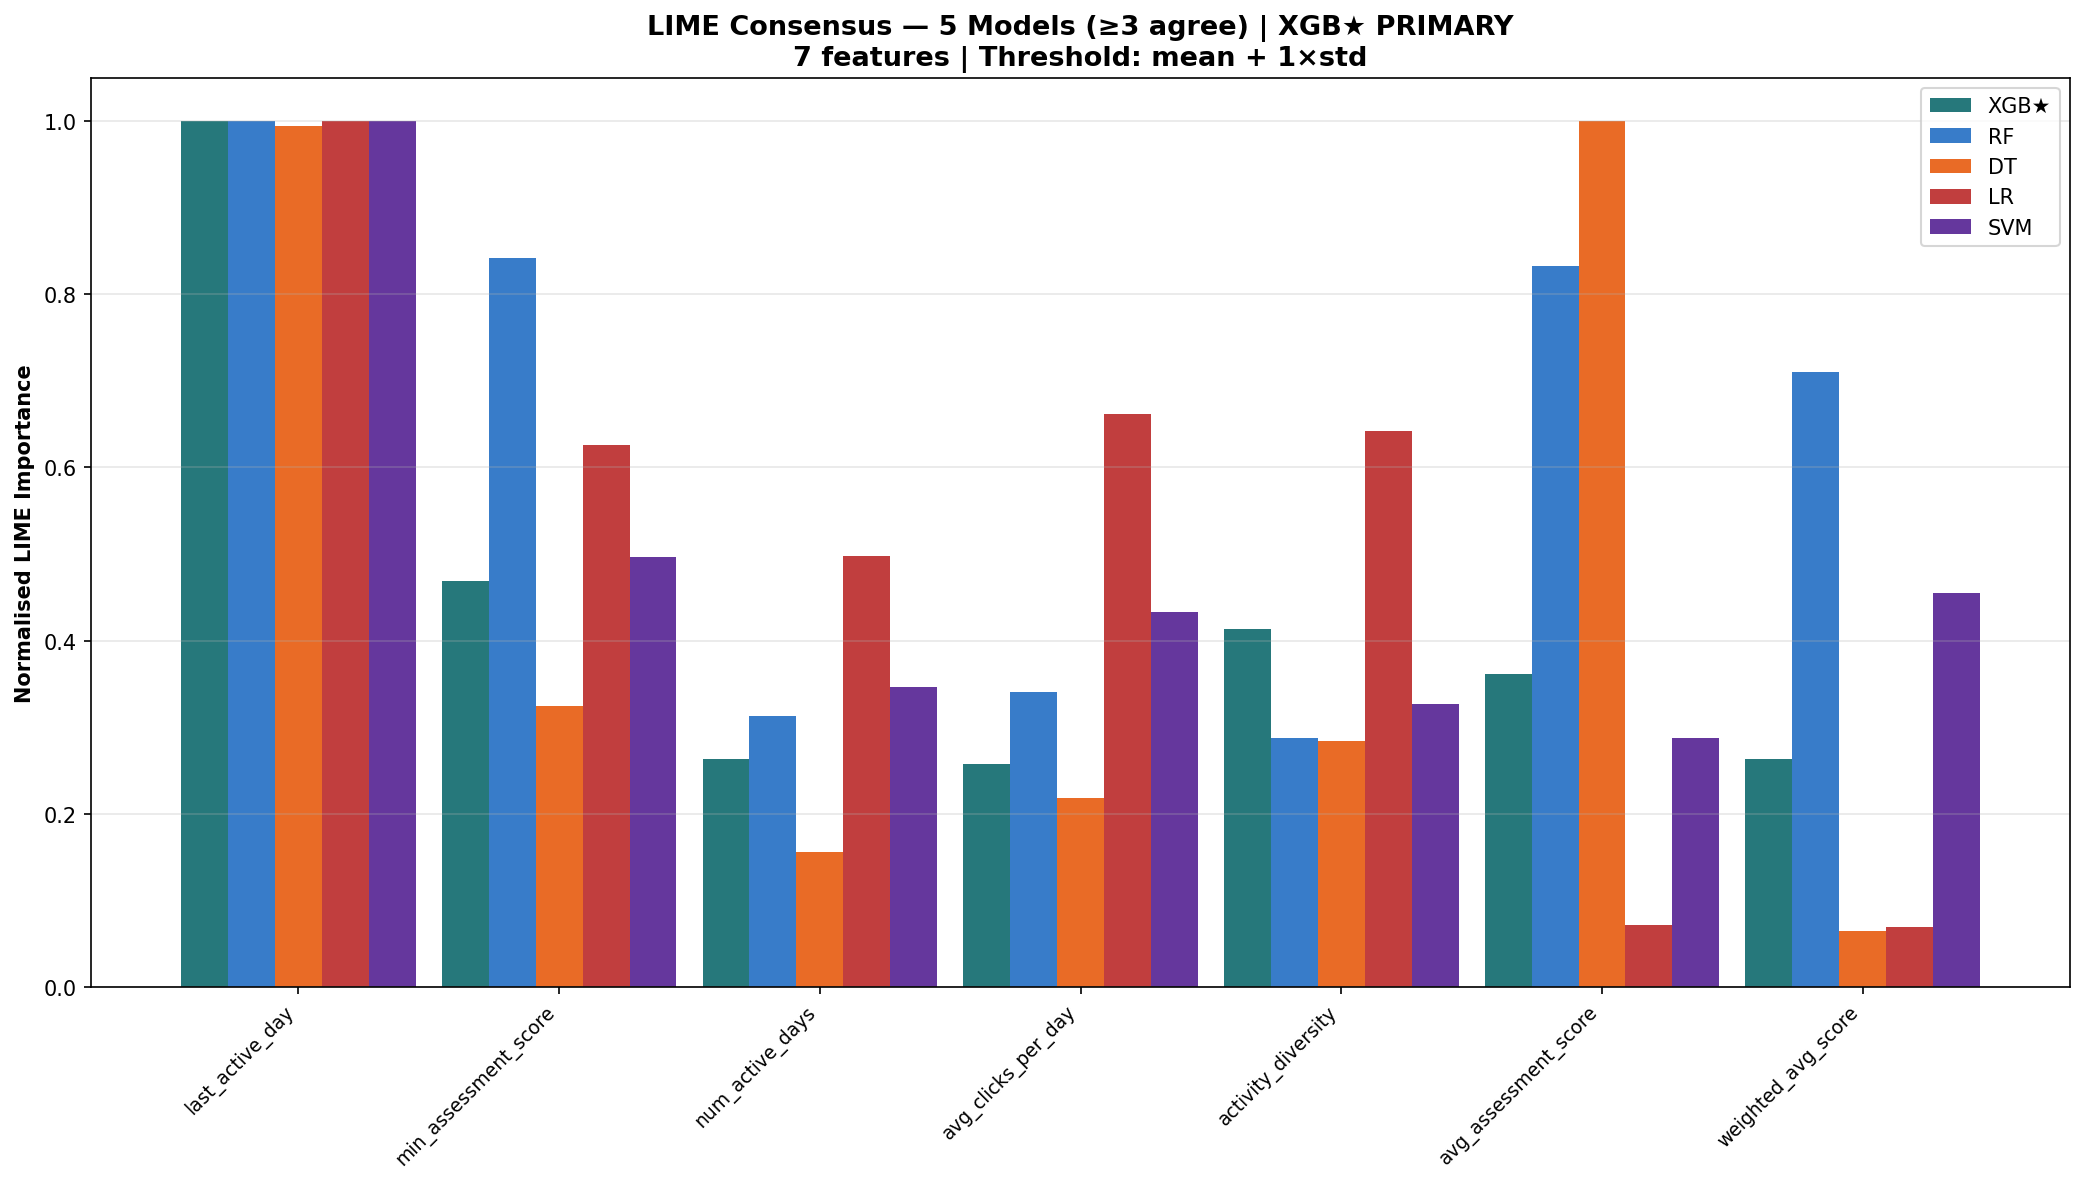

LIME Consensus plot saved.


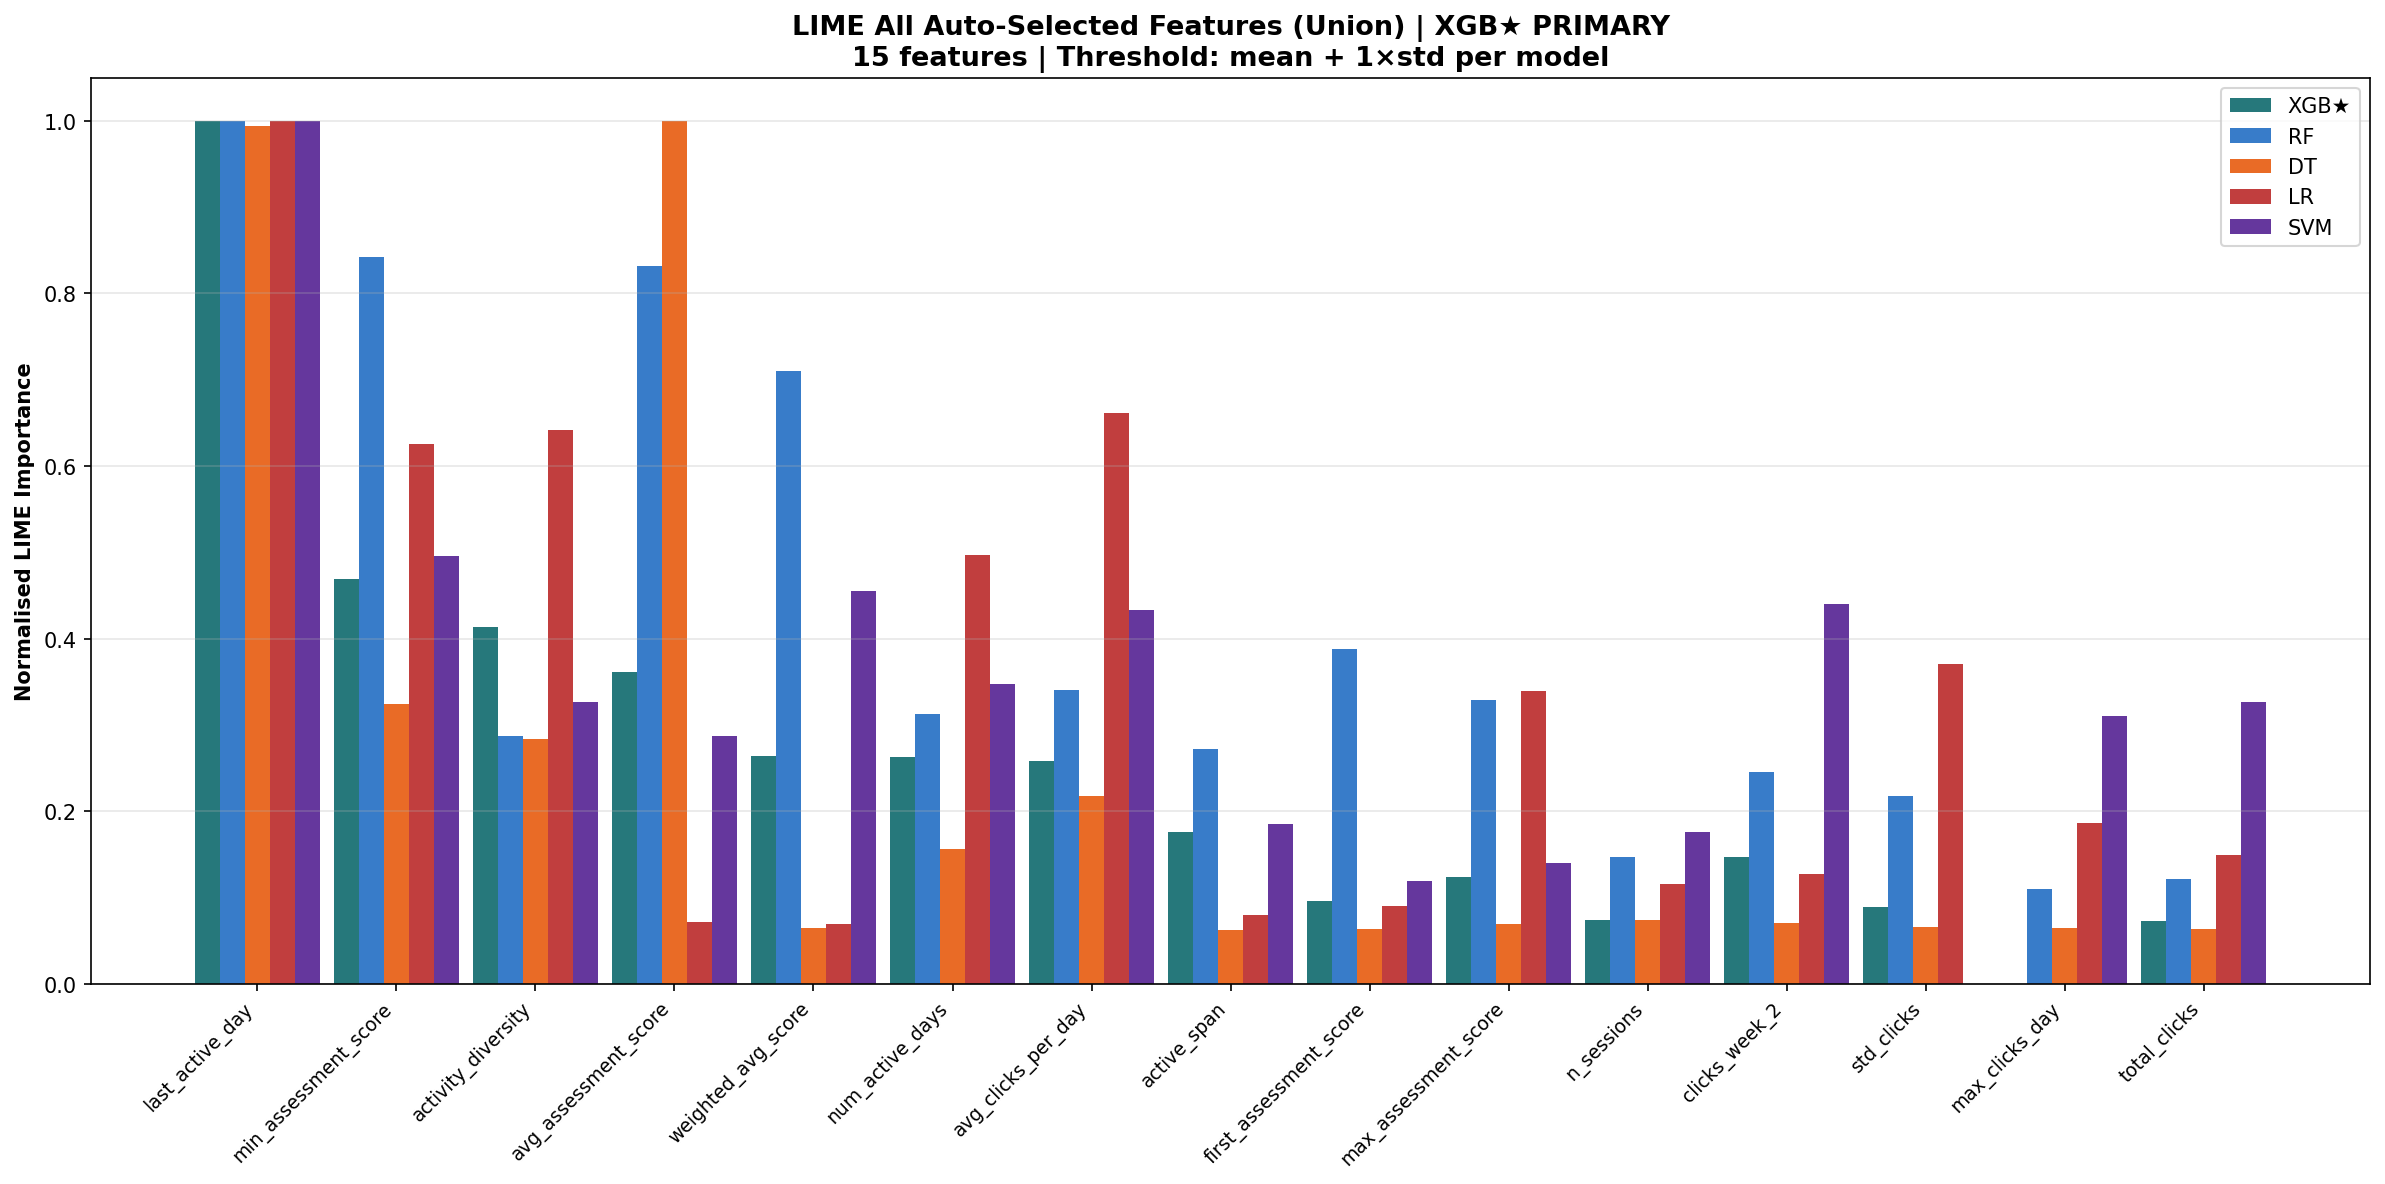

LIME Union plot saved.


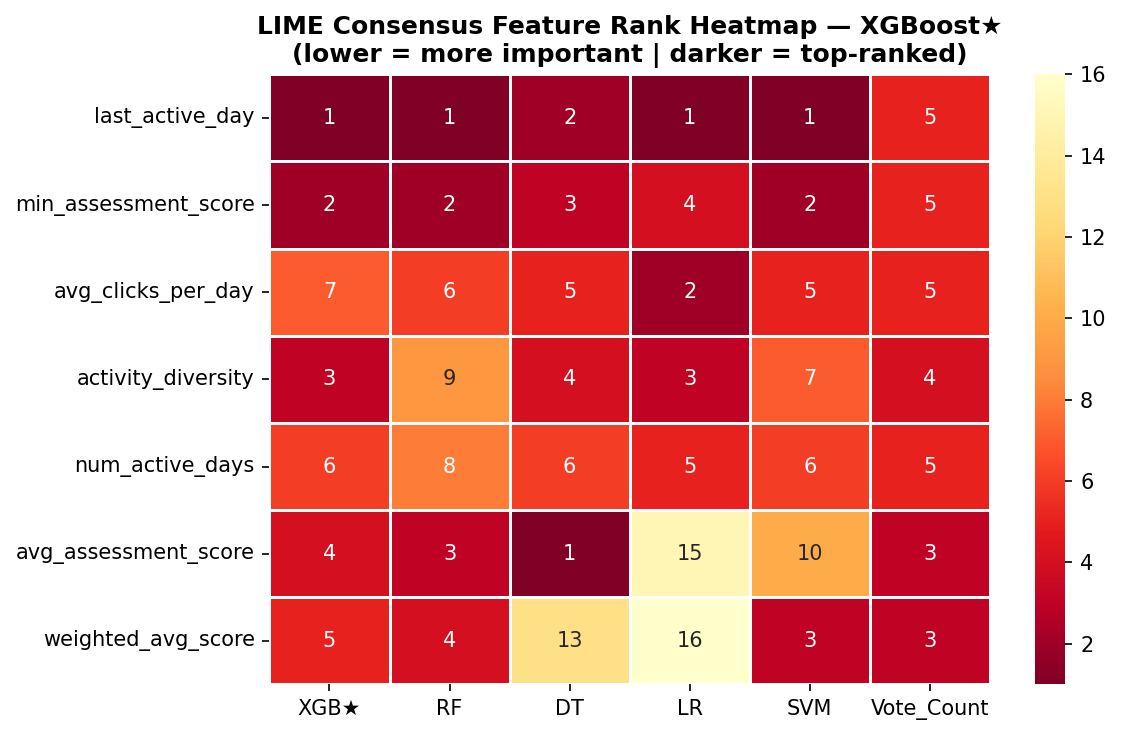

LIME Rank Heatmap saved.

LIME Rankings done — Consensus: 7 | Union: 15 features.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 17b — LIME AUTO-SELECTED RANKINGS + CONSENSUS (All 5 Models)
# ════════════════════════════════════════════════════════════════════════════

all_lime_feats_19 = (list(auto_lime_xgb.index) + list(auto_lime_rf.index) +
                     list(auto_lime_dt.index)  + list(auto_lime_lr.index) +
                     list(auto_lime_svm.index))
lime_union = list(dict.fromkeys(all_lime_feats_19))

print('LIME Auto-Selected Features per Model (from Cell 17 — LIME Analysis):')
print(f'  XGB★={len(auto_lime_xgb)}  RF={len(auto_lime_rf)}  '
      f'DT={len(auto_lime_dt)}  LR={len(auto_lime_lr)}  SVM={len(auto_lime_svm)}')
print(f'\nLIME Consensus (≥3 models): {len(lime_consensus)} features')
print(f'LIME Union               : {len(lime_union)} features')

# ── Ranking table ─────────────────────────────────────────────────────────
lime_model_ranks = [
    (lime_global_xgb, 'XGB★', '#006064'),
    (lime_global_rf,  'RF',   '#1565C0'),
    (lime_global_dt,  'DT',   '#E65100'),
    (lime_global_lr,  'LR',   '#B71C1C'),
    (lime_global_svm, 'SVM',  '#4A148C'),
]

if lime_consensus:
    rank_table_lime = pd.DataFrame({
        label: series.rank(ascending=False).astype(int)
        for series, label, _ in lime_model_ranks
    }, index=FEATURE_NAMES_SEL).loc[lime_consensus]
    rank_table_lime['Avg_Rank']   = rank_table_lime.mean(axis=1)
    rank_table_lime['Vote_Count'] = [lime_vote[f] for f in lime_consensus]
    rank_table_lime = rank_table_lime.sort_values('Avg_Rank')
    rank_table_lime.to_csv(CSV_DIR / 'lime_consensus_ranking.csv')
    print('\nLIME Consensus Ranking Table:')
    print(rank_table_lime[['XGB★','RF','DT','LR','SVM',
                            'Vote_Count','Avg_Rank']].to_string())

# ── Plot 1: Consensus ─────────────────────────────────────────────────────
w = 0.18
if lime_consensus:
    fig, ax = plt.subplots(figsize=(max(14, len(lime_consensus)), 8))
    x = np.arange(len(lime_consensus))
    for i, (rank, label, color) in enumerate(lime_model_ranks):
        vals = [rank.get(f, 0) / (rank.max() + 1e-9) for f in lime_consensus]
        ax.bar(x + (i - 2) * w, vals, w, label=label, color=color, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([f[:22] for f in lime_consensus],
                       rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Normalised LIME Importance', fontweight='bold')
    ax.set_title(
        f'LIME Consensus — 5 Models (≥3 agree) | XGB★ PRIMARY\n'
        f'{len(lime_consensus)} features | Threshold: mean + 1×std',
        fontsize=13, fontweight='bold')
    ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'lime_consensus_features.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('LIME Consensus plot saved.')

# ── Plot 2: Union ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(16, len(lime_union)), 8))
x = np.arange(len(lime_union))
for i, (rank, label, color) in enumerate(lime_model_ranks):
    vals = [rank.get(f, 0) / (rank.max() + 1e-9) for f in lime_union]
    ax.bar(x + (i - 2) * w, vals, w, label=label, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f[:22] for f in lime_union],
                   rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Normalised LIME Importance', fontweight='bold')
ax.set_title(
    f'LIME All Auto-Selected Features (Union) | XGB★ PRIMARY\n'
    f'{len(lime_union)} features | Threshold: mean + 1×std per model',
    fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'lime_all_models_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('LIME Union plot saved.')

# ── Heatmap ───────────────────────────────────────────────────────────────
if lime_consensus:
    fig, ax = plt.subplots(figsize=(8, max(5, len(lime_consensus) * 0.5)))
    sns.heatmap(
        rank_table_lime.sort_values('Avg_Rank')[
            ['XGB★','RF','DT','LR','SVM','Vote_Count']],
        annot=True, fmt='.0f', cmap='YlOrRd_r',
        linewidths=0.5, ax=ax)
    ax.set_title('LIME Consensus Feature Rank Heatmap — XGBoost★\n'
                 '(lower = more important | darker = top-ranked)',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'lime_rank_heatmap.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('LIME Rank Heatmap saved.')

print(f'\nLIME Rankings done — '
      f'Consensus: {len(lime_consensus)} | Union: {len(lime_union)} features.')


Kendall's τ = 0.5556  p = 0.0286
Statistically significant (p=0.029) — moderate rank agreement


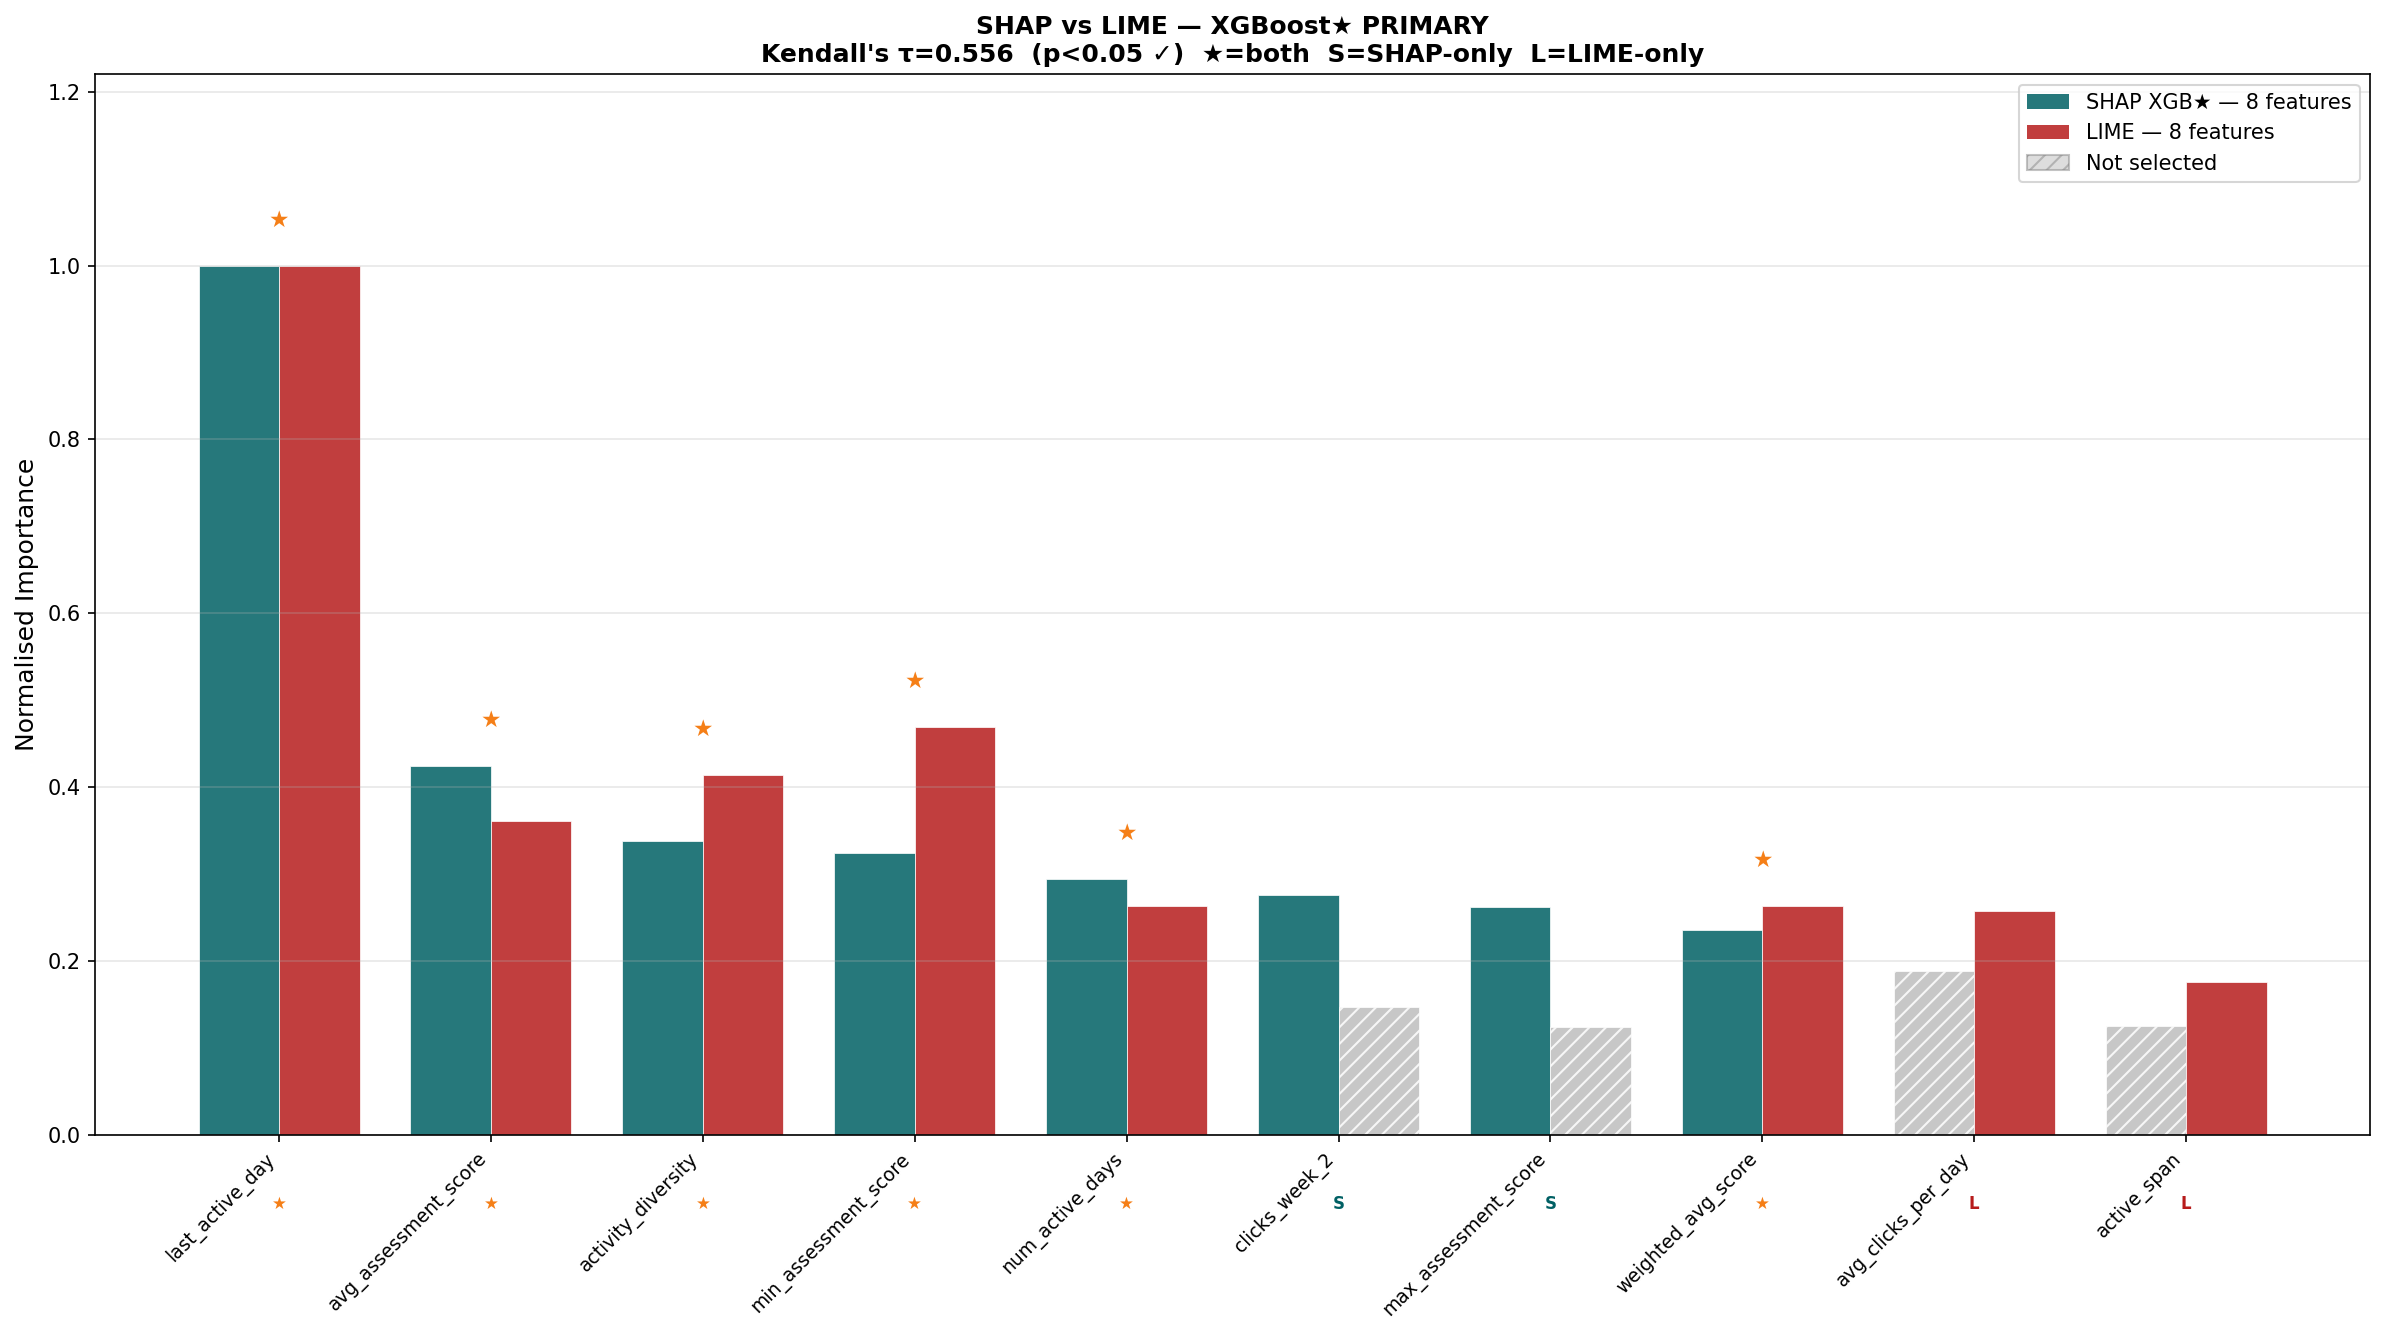


Comparison saved — 10 features.
★ Both: 6 | SHAP only: 2 | LIME only: 2


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 18 — SHAP vs LIME COMPARISON + Kendall's τ
# ════════════════════════════════════════════════════════════════════════════
union        = list(dict.fromkeys(list(auto_shap_xgb.index)+list(auto_lime_xgb.index)))
intersection = [f for f in union if f in auto_shap_xgb.index and f in auto_lime_xgb.index]
shap_only    = [f for f in union if f in auto_shap_xgb.index and f not in auto_lime_xgb.index]
lime_only    = [f for f in union if f in auto_lime_xgb.index and f not in auto_shap_xgb.index]

sr  = {f:i+1 for i,f in enumerate(shap_rank_xgb.index)}
lr2 = {f:i+1 for i,f in enumerate(lime_global_xgb.index)}
tau,pv = kendalltau([sr[f] for f in union],[lr2[f] for f in union])

if pv<0.05:
    strength = "strong" if abs(tau)>0.6 else "moderate" if abs(tau)>0.3 else "weak"
    sig_note = f"Statistically significant (p={pv:.3f}) — {strength} rank agreement"
else:
    sig_note = (f"Not statistically significant (p={pv:.3f})\n"
                "  → SHAP and LIME capture different explanatory perspectives; "
                "applying both methods in tandem is warranted.")
print(f"Kendall's τ = {tau:.4f}  p = {pv:.4f}\n{sig_note}")

shap_max = shap_rank_xgb[union].max() or 1.0
lime_max = lime_global_xgb[union].max() or 1.0
sv_p = (shap_rank_xgb.reindex(union).fillna(0)/shap_max).tolist()
lv_p = (lime_global_xgb.reindex(union).fillna(0)/lime_max).tolist()

from matplotlib.patches import Patch
SHAP_C=PRIMARY_COLOR; LIME_C='#B71C1C'; GREY_C='#BDBDBD'

fig,ax = plt.subplots(figsize=(max(16,len(union)),9))
x = np.arange(len(union)); w = 0.38
for j,f in enumerate(union):
    cat=('both' if f in intersection else 'shap_only' if f in shap_only else 'lime_only')
    sc=SHAP_C if cat in ('both','shap_only') else GREY_C
    lc=LIME_C if cat in ('both','lime_only') else GREY_C
    sh='' if cat in ('both','shap_only') else '///'
    lh='' if cat in ('both','lime_only') else '///'
    ax.bar(x[j]-w/2,sv_p[j],w,color=sc,alpha=0.85,hatch=sh,edgecolor='white',linewidth=0.4)
    ax.bar(x[j]+w/2,lv_p[j],w,color=lc,alpha=0.85,hatch=lh,edgecolor='white',linewidth=0.4)
    if cat=='both': ax.text(x[j],max(sv_p[j],lv_p[j])+0.045,'★',ha='center',fontsize=11,color='#F57F17',fontweight='bold')
ax.legend(handles=[Patch(facecolor=SHAP_C,alpha=0.85,label=f'SHAP XGB★ — {len(auto_shap_xgb)} features'),
                   Patch(facecolor=LIME_C,alpha=0.85,label=f'LIME — {len(auto_lime_xgb)} features'),
                   Patch(facecolor=GREY_C,alpha=0.5,hatch='///',edgecolor='#888',label='Not selected')],
          fontsize=10,loc='upper right')
for j,f in enumerate(union):
    label='★' if f in intersection else 'S' if f in shap_only else 'L'
    ax.text(x[j],-0.07,label,ha='center',fontsize=8,
            color='#F57F17' if f in intersection else SHAP_C if f in shap_only else LIME_C,
            fontweight='bold',transform=ax.get_xaxis_transform())
ax.set_xticks(x); ax.set_xticklabels([f[:25] for f in union],rotation=45,ha='right',fontsize=9)
ax.set_ylabel('Normalised Importance',fontsize=12); ax.set_ylim(0,1.22); ax.grid(axis='y',alpha=0.3)
sig_str=f"p<0.05 ✓" if pv<0.05 else f"p={pv:.3f} (n.s.)"
ax.set_title(f"SHAP vs LIME — XGBoost★ PRIMARY\n"
             f"Kendall's τ={tau:.3f}  ({sig_str})  ★=both  S=SHAP-only  L=LIME-only",
             fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'shap_lime_comparison_XGB.png',dpi=150,bbox_inches='tight')
plt.show()

comp=pd.DataFrame({'Feature':union,
    'Selected_By':['Both' if f in intersection else 'SHAP only' if f in shap_only else 'LIME only' for f in union],
    'SHAP_norm':sv_p,'LIME_norm':lv_p,
    'SHAP_rank':[sr[f] for f in union],'LIME_rank':[lr2[f] for f in union]})
comp.to_csv(CSV_DIR/'shap_lime_comparison_XGB.csv',index=False)
print(f'\nComparison saved — {len(comp)} features.')
print(f'★ Both: {len(intersection)} | SHAP only: {len(shap_only)} | LIME only: {len(lime_only)}')


  [F1] Fixed points (threshold 0.50): TP=8, TN=8, FP=7, FN=7  | total=30
  [F1] REPORT THESE COUNTS IN SECTIONS 3.6.3 AND 4.8.1
Bootstrap: 100 iters x 30 pts | SHAP=TreeExplainer | LIME=1000 samples
------------------------------------------------------------
  [ 10/100] done
  [ 20/100] done
  [ 30/100] done
  [ 40/100] done
  [ 50/100] done
  [ 60/100] done
  [ 70/100] done
  [ 80/100] done
  [ 90/100] done
  [100/100] done

[F5] No LIME explanation failures.

Median CV% — SHAP: 18.9%   LIME: 19.7%


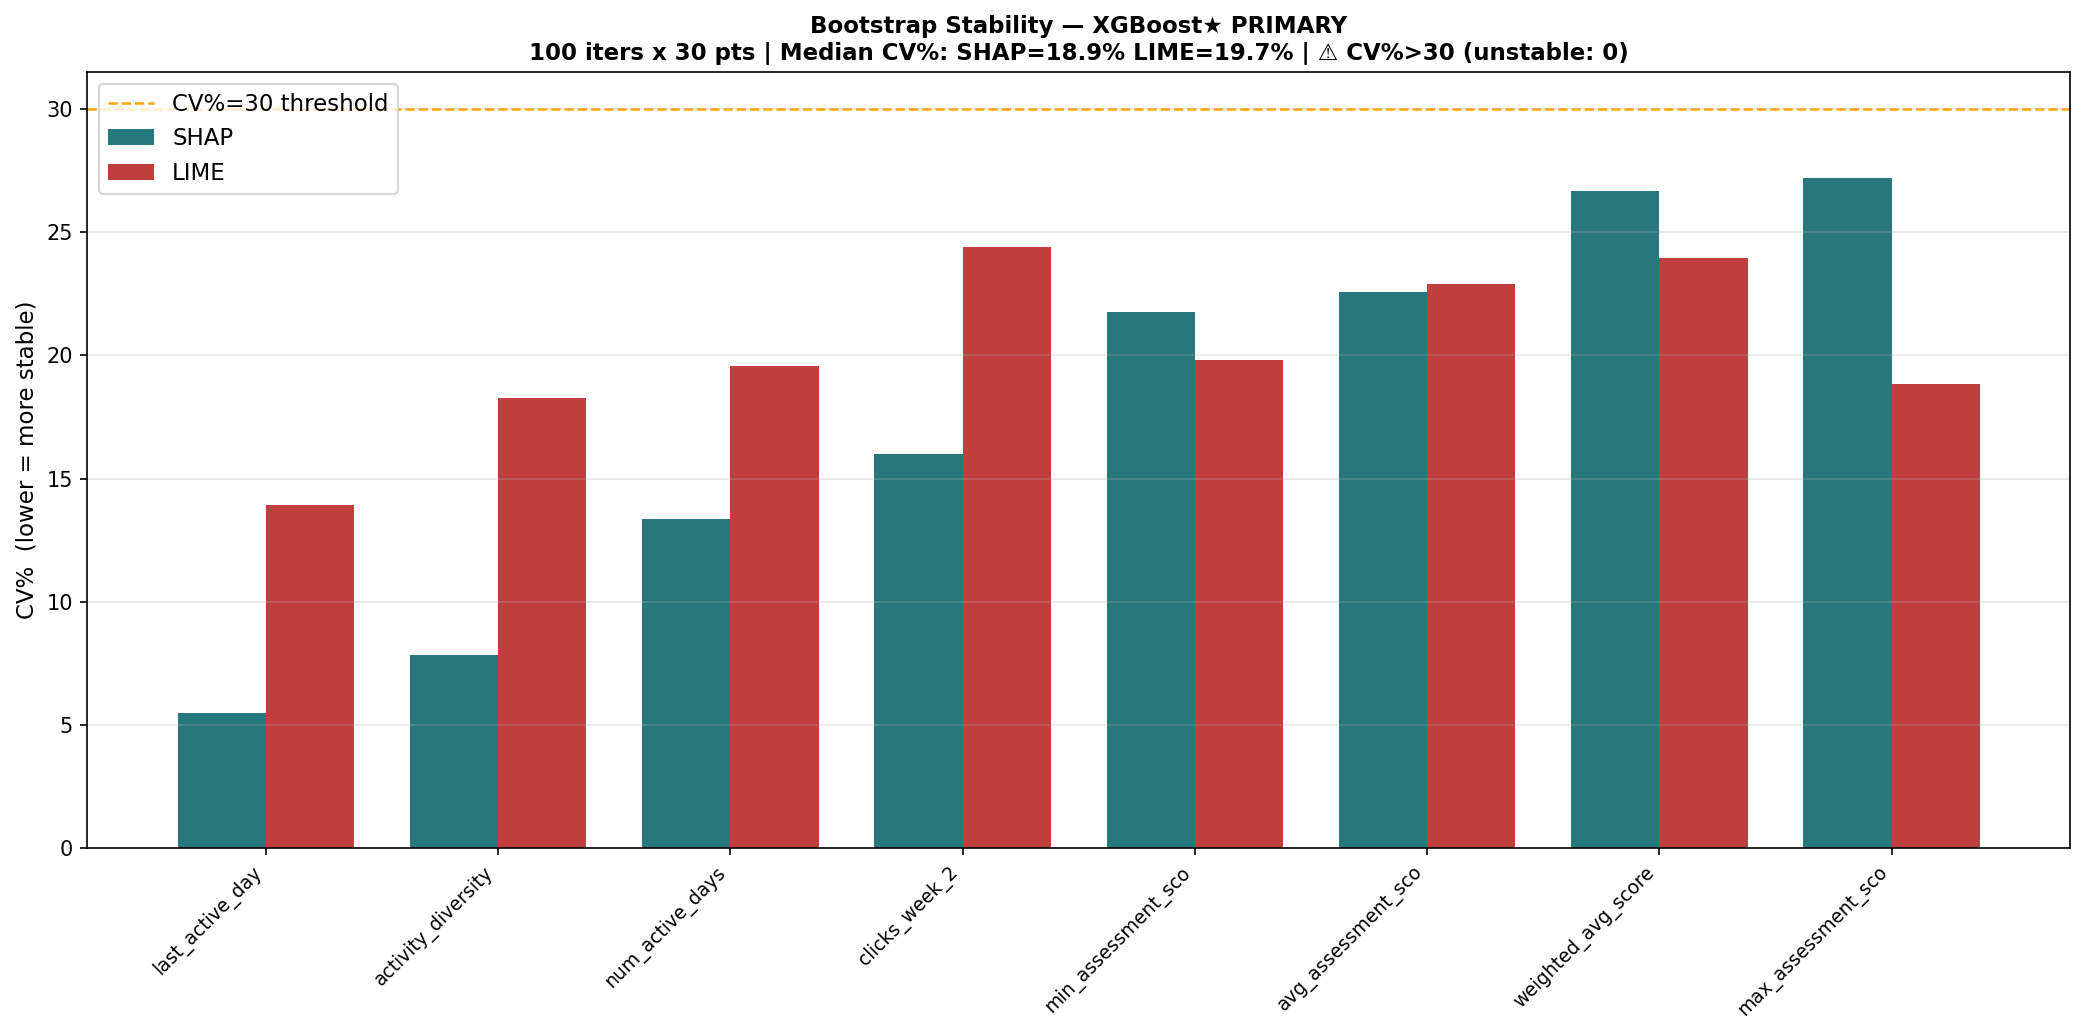

Stable (CV%≤30): 8 | Unstable: 0


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 19 — BOOTSTRAP STABILITY  (100 iterations × 30 fixed points)
# ════════════════════════════════════════════════════════════════════════════
N_BOOT=100; N_FIX=30; N_LIME_FEAT=len(auto_shap_xgb)
# 1000 = literature lower bound; full 5000 x (100 iters x 30 pts) is prohibitive.
# Single-shot global LIME uses the full 5000.
N_LIME_SAMP=1000
trk_feats=list(auto_shap_xgb.index)


# ── [FIX F1] Stratified selection of the fixed bootstrap evaluation points ──
# The previous version used np.random.choice(..., replace=False), i.e. a simple
# random sample. The methodology requires proportional representation of the
# four confusion-matrix categories (TP, TN, FP, FN) at the default threshold
# tau = 0.50, so that the stability estimate is not dominated by whichever
# category happens to be over-drawn. This helper enforces that quota and
# reports the realised composition, which is the number the thesis cites.
def stratified_fixed_points(y_true, y_prob, n_fix, thr=0.50, seed=SEED, verbose=True):
    """Pick n_fix test indices with ~equal representation of TP/TN/FP/FN."""
    y_true = np.asarray(y_true).astype(int)
    y_hat  = (np.asarray(y_prob) >= thr).astype(int)
    cats = {
        'TP': np.where((y_true == 1) & (y_hat == 1))[0],
        'TN': np.where((y_true == 0) & (y_hat == 0))[0],
        'FP': np.where((y_true == 0) & (y_hat == 1))[0],
        'FN': np.where((y_true == 1) & (y_hat == 0))[0],
    }
    rng = np.random.RandomState(seed)
    base, extra = divmod(n_fix, 4)
    quota = {k: base for k in cats}
    # distribute the remainder to the largest categories first, deterministically
    for k in sorted(cats, key=lambda c: -len(cats[c]))[:extra]:
        quota[k] += 1
    picked, realised = [], {}
    for k in ['TP', 'TN', 'FP', 'FN']:
        take = min(quota[k], len(cats[k]))
        if take > 0:
            picked.extend(rng.choice(cats[k], take, replace=False))
        realised[k] = take
    picked = np.array(picked)
    # if a category was too small to fill its quota, top up from the remainder
    if len(picked) < n_fix:
        pool = np.setdiff1d(np.arange(len(y_true)), picked)
        picked = np.concatenate([picked, rng.choice(pool, n_fix - len(picked),
                                                    replace=False)])
    picked = np.sort(picked)
    if verbose:
        print(f'  [F1] Fixed points (threshold {thr:.2f}): '
              + ', '.join(f'{k}={realised[k]}' for k in ["TP","TN","FP","FN"])
              + f'  | total={len(picked)}')
        print(f'  [F1] REPORT THESE COUNTS IN SECTIONS 3.6.3 AND 4.8.1')
    return picked, realised

np.random.seed(SEED)
Xta=np.array(X_tr_p,dtype=np.float32); yta=np.array(y_train_arr,dtype=np.int64)
fix_idx, fix_composition = stratified_fixed_points(
    y_test_arr, y_prob_xgb, N_FIX, thr=0.50, seed=SEED)
X_fix = X_te_xgb[fix_idx]

sb={f:[] for f in trk_feats}; lb={f:[] for f in trk_feats}
n_lime_fail = 0                                     # [FIX F5]

print(f'Bootstrap: {N_BOOT} iters x {N_FIX} pts | SHAP=TreeExplainer | LIME={N_LIME_SAMP} samples')
print('-'*60)

for b in range(N_BOOT):
    bi=np.random.choice(len(Xta),len(Xta),replace=True); Xb,yb=Xta[bi],yta[bi]

    _best_p = trained_models['XGBoost'].named_steps['clf'].get_params()
    xgbb=XGBClassifier(
        n_estimators   = _best_p.get('n_estimators',100),
        max_depth      = _best_p.get('max_depth',6),
        learning_rate  = _best_p.get('learning_rate',0.1),
        subsample      = _best_p.get('subsample',0.8),
        eval_metric='logloss', scale_pos_weight=spw,
        random_state=SEED+b, n_jobs=-1)
    xgbb.fit(Xb,yb)

    # SHAP
    sv_b = shap.TreeExplainer(xgbb).shap_values(X_fix)
    sv_b = np.array(sv_b[1]) if isinstance(sv_b,list) else (sv_b[:,:,1] if np.array(sv_b).ndim==3 else sv_b)
    ms   = np.abs(sv_b).mean(0)
    for f in trk_feats:
        if f in FEATURE_NAMES_SEL: sb[f].append(ms[FEATURE_NAMES_SEL.index(f)])

    # LIME
    le_b=lime_tabular.LimeTabularExplainer(Xb.astype(np.float32),feature_names=FEATURE_NAMES_SEL,
         class_names=['Success','At-Risk'],mode='classification',random_state=SEED+b)
    lw_iter={f:[] for f in trk_feats}
    for j in range(N_FIX):
        try:
            ex=le_b.explain_instance(X_fix[j].astype(np.float32),xgbb.predict_proba,
               num_features=N_LIME_FEAT,num_samples=N_LIME_SAMP,labels=(1,))
            for feat_str,w in ex.as_list(label=1):
                # [FIX F4] use the same matcher as compute_lime_global
                fn = _match_feature(feat_str, FEATURE_NAMES_SEL)
                if fn in lw_iter: lw_iter[fn].append(abs(w))
        except Exception as e:                      # [FIX F5] count, don't swallow
            n_lime_fail += 1
            if n_lime_fail <= 3:
                print(f'    [warn] LIME failed (iter {b}, point {j}): '
                      f'{type(e).__name__}: {e}')
    for f in trk_feats:
        if lw_iter[f]: lb[f].append(np.mean(lw_iter[f]))

    if (b+1)%10==0: print(f'  [{b+1:3d}/{N_BOOT}] done')

def cv_percent(values):
    arr=np.array(values,dtype=float)
    if len(arr)<5 or arr.mean()==0: return np.nan
    return arr.std()/arr.mean()*100

stab_rows=[]
for f in trk_feats:
    stab_rows.append({'Feature':f,'SHAP_n':len(sb[f]),
        'SHAP_Mean':np.mean(sb[f]) if sb[f] else np.nan,
        'SHAP_CV%' :cv_percent(sb[f]),
        'LIME_n'   :len(lb[f]),
        'LIME_Mean':np.nanmean(lb[f]) if lb[f] else np.nan,
        'LIME_CV%' :cv_percent(lb[f])})
stab=pd.DataFrame(stab_rows).sort_values('SHAP_CV%')
stab.to_csv(CSV_DIR/'stability_XGB.csv',index=False)

if n_lime_fail:                                     # [FIX F5]
    print(f'\n[F5] LIME explanations that failed: {n_lime_fail} '
          f'of {N_BOOT*N_FIX} ({100*n_lime_fail/(N_BOOT*N_FIX):.2f}%) '
          f'- report this figure if non-zero.')
else:
    print('\n[F5] No LIME explanation failures.')

shap_cv_med=stab['SHAP_CV%'].dropna().median()
lime_cv_med=stab['LIME_CV%'].dropna().median()
print(f'\nMedian CV% — SHAP: {shap_cv_med:.1f}%   LIME: {lime_cv_med:.1f}%')

fig,ax=plt.subplots(figsize=(14,7))
x=np.arange(len(stab)); w=0.38
ax.bar(x-w/2,stab['SHAP_CV%'].fillna(0),w,label='SHAP',color=PRIMARY_COLOR,alpha=0.85)
lime_bars=ax.bar(x+w/2,stab['LIME_CV%'].fillna(0),w,label='LIME',color='#B71C1C',alpha=0.85)
for j,lv in enumerate(stab['LIME_CV%']):
    if np.isnan(lv):
        lime_bars[j].set_hatch('///'); lime_bars[j].set_edgecolor('#888')
        lime_bars[j].set_facecolor('#CCCCCC')
        ax.text(x[j]+w/2,1.5,'N/A',ha='center',va='bottom',fontsize=7,color='#555',style='italic')
ax.axhline(30,color='orange',linestyle='--',linewidth=1.2,label='CV%=30 threshold')
stab_r=stab.reset_index(drop=True)
for j,row in stab_r.iterrows():
    if not np.isnan(row['SHAP_CV%']) and row['SHAP_CV%']>30:
        ax.text(x[j]-w/2,row['SHAP_CV%']+0.5,'⚠',ha='center',fontsize=10,color='#B71C1C')
ax.set_xticks(x)
ax.set_xticklabels([f[:18] for f in stab['Feature']],rotation=45,ha='right',fontsize=9)
ax.set_ylabel('CV%  (lower = more stable)',fontsize=11)
n_stable=(stab['SHAP_CV%'].dropna()<=30).sum(); n_unstable=(stab['SHAP_CV%'].dropna()>30).sum()
ax.set_title(f'Bootstrap Stability — XGBoost★ PRIMARY\n'
             f'{N_BOOT} iters x {N_FIX} pts | Median CV%: SHAP={shap_cv_med:.1f}% LIME={lime_cv_med:.1f}% | '
             f'⚠ CV%>30 (unstable: {n_unstable})',fontweight='bold',fontsize=11)
ax.legend(fontsize=11); ax.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR/'stability_XGB.png',dpi=150,bbox_inches='tight')
plt.show()
print(f'Stable (CV%≤30): {n_stable} | Unstable: {n_unstable}')


Method  Total_s  Per_Instance_ms
  SHAP    0.013            0.131
  LIME    3.734           37.341

SHAP (TreeExplainer) is 284.6x faster than LIME


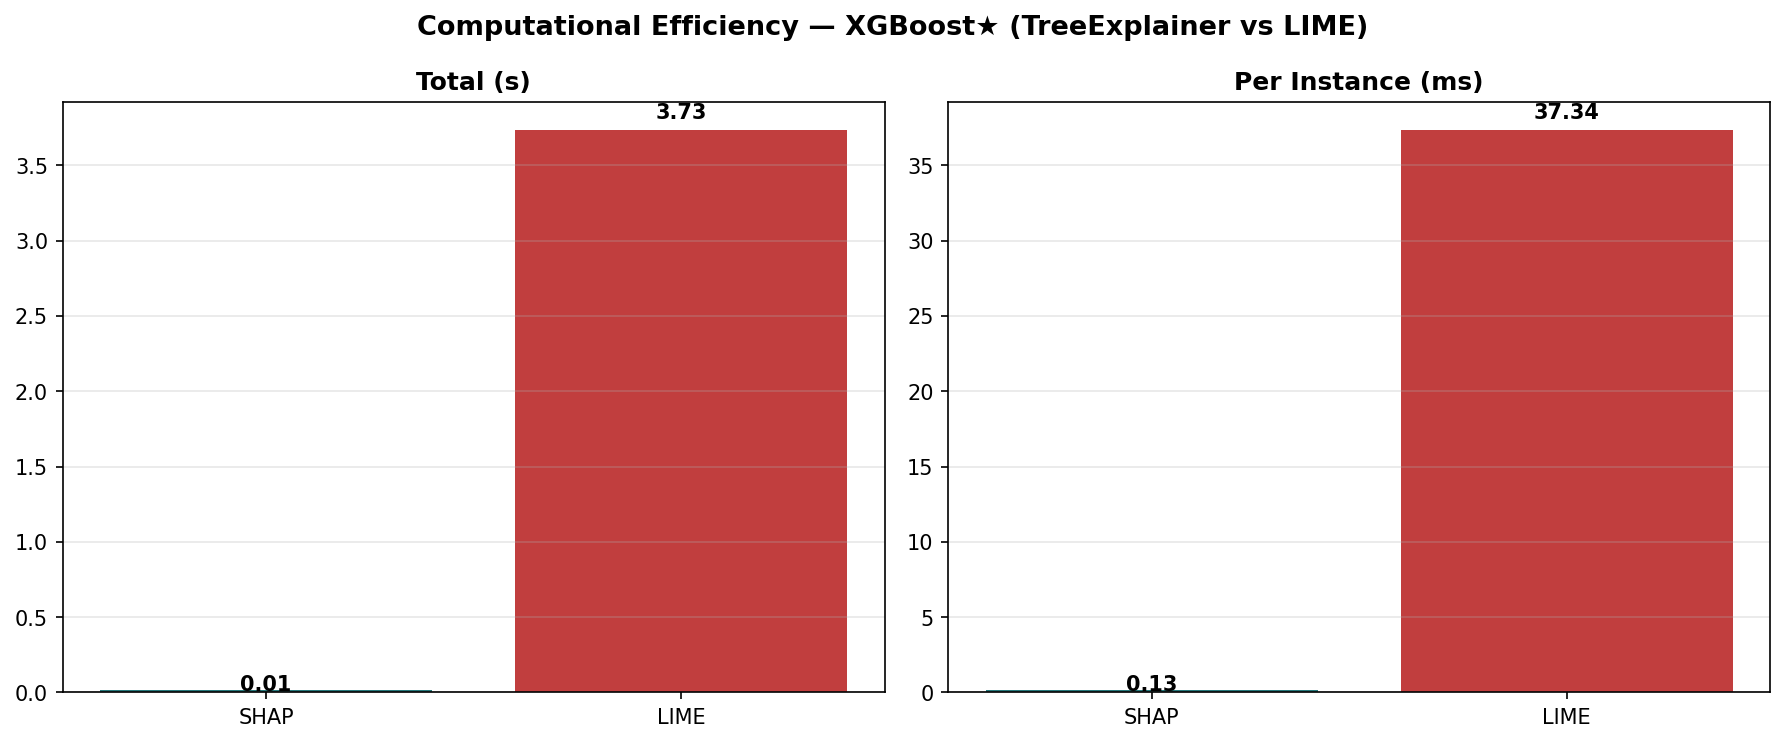


All XGBoost analyses complete.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 20 — COMPUTATIONAL EFFICIENCY (SHAP TreeExplainer vs LIME)
# ════════════════════════════════════════════════════════════════════════════
N_EFF=100; N_LIME_SAMP_EFF=LIME_PERTURB_SAMPLES
np.random.seed(SEED)
eff_idx=np.random.choice(len(X_te_xgb),N_EFF,replace=False); Xe=X_te_xgb[eff_idx]

se_speed=shap.TreeExplainer(xgb_clf)
# Warm-up
se_speed.shap_values(Xe[:5])
_=lime_exp.explain_instance(Xe[0],lime_fn,num_features=len(auto_shap_xgb),
                             num_samples=N_LIME_SAMP_EFF,labels=(1,))

t0=time.time(); se_speed.shap_values(Xe); shap_eff=time.time()-t0
t0=time.time()
for i in range(N_EFF):
    lime_exp.explain_instance(Xe[i],lime_fn,num_features=len(auto_shap_xgb),
                               num_samples=N_LIME_SAMP_EFF,labels=(1,))
lime_eff=time.time()-t0

eff=pd.DataFrame({'Method':['SHAP','LIME'],'Total_s':[shap_eff,lime_eff],
    'Per_Instance_ms':[shap_eff/N_EFF*1000,lime_eff/N_EFF*1000]})
eff.to_csv(CSV_DIR/'efficiency_XGB.csv',index=False)
print(eff.to_string(index=False,float_format='{:.3f}'.format))
print(f'\nSHAP (TreeExplainer) is {lime_eff/shap_eff:.1f}x faster than LIME')

fig,(a1,a2)=plt.subplots(1,2,figsize=(12,5))
for ax,vals,title in[(a1,[shap_eff,lime_eff],'Total (s)'),
                     (a2,[shap_eff/N_EFF*1000,lime_eff/N_EFF*1000],'Per Instance (ms)')]:
    bars=ax.bar(['SHAP','LIME'],vals,color=[PRIMARY_COLOR,'#B71C1C'],alpha=0.85)
    for b,v in zip(bars,vals):
        ax.text(b.get_x()+b.get_width()/2,v+v*0.02,f'{v:.2f}',ha='center',fontweight='bold')
    ax.set_title(title,fontweight='bold'); ax.grid(axis='y',alpha=0.3)
plt.suptitle('Computational Efficiency — XGBoost★ (TreeExplainer vs LIME)',
             fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'efficiency_XGB.png',dpi=150,bbox_inches='tight')
plt.show()
print('\nAll XGBoost analyses complete.')


LIME sensitivity analysis (primary model only, for tractability) ...
     Setting  vs_reference_tau      p
perturb=1000            0.9167 0.0000
perturb=2500            0.9500 0.0000
perturb=5000            1.0000 0.0000
global_n=150            0.9333 0.0000
global_n=300            1.0000 0.0000


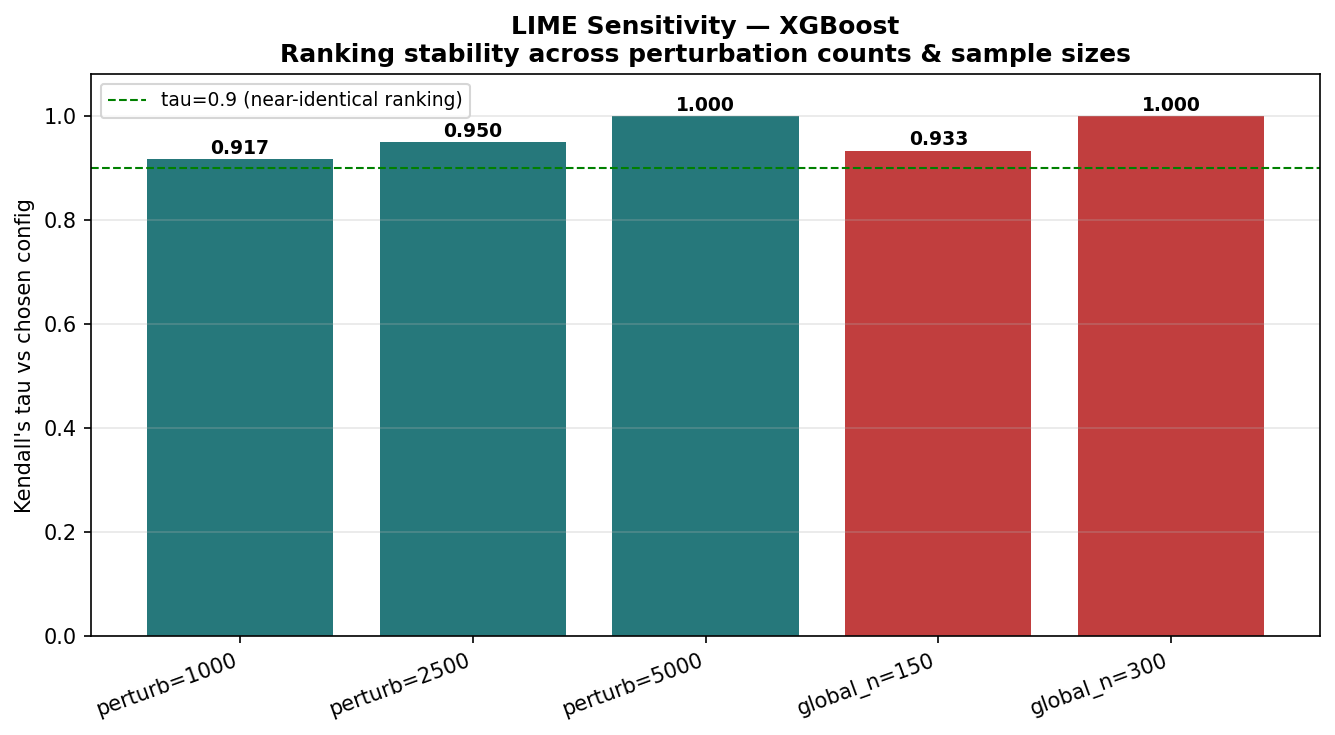


Interpretation: tau close to 1.0 => global LIME ranking barely changes,
so n_lime_samples=5000 and the stratified sample size are empirically justified.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# LIME SENSITIVITY ANALYSIS — justifies n_lime_samples (perturbations) & sample size
# Shows the global LIME feature RANKING is stable across perturbation counts
# {1000, 2500, 5000} and global sample sizes {150, 300}, so the chosen defaults
# are empirically justified — a defensible answer to "why these numbers?".
# Rank agreement vs the chosen config is measured with Kendall's tau.
# ════════════════════════════════════════════════════════════════════════════
print('LIME sensitivity analysis (primary model only, for tractability) ...')
_sens_predict = lambda x:xgb_pipe.named_steps['clf'].predict_proba(x)
_ref_order = list(lime_global_xgb.index)

sens_rows = []
for ns in [1000, 2500, 5000]:
    r = compute_lime_global(_sens_predict, X_te_xgb, y_test_arr, n_samples=LIME_GLOBAL_N, n_lime_samples=ns, seed=SEED)
    tau_s, p_s = kendalltau([_ref_order.index(f) for f in _ref_order],
                            [list(r.index).index(f) for f in _ref_order])
    sens_rows.append({'Setting': f'perturb={ns}', 'vs_reference_tau': tau_s, 'p': p_s})
for gn in [150, 300]:
    r = compute_lime_global(_sens_predict, X_te_xgb, y_test_arr, n_samples=gn, n_lime_samples=LIME_PERTURB_SAMPLES, seed=SEED)
    tau_s, p_s = kendalltau([_ref_order.index(f) for f in _ref_order],
                            [list(r.index).index(f) for f in _ref_order])
    sens_rows.append({'Setting': f'global_n={gn}', 'vs_reference_tau': tau_s, 'p': p_s})

sens_df = pd.DataFrame(sens_rows)
try:
    sens_df.to_csv(CSV_DIR / 'lime_sensitivity.csv', index=False)
except Exception:
    sens_df.to_csv('lime_sensitivity.csv', index=False)
print(sens_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#006064' if 'perturb' in s else '#B71C1C' for s in sens_df['Setting']]
bars = ax.bar(sens_df['Setting'], sens_df['vs_reference_tau'], color=colors, alpha=0.85)
for bar, v in zip(bars, sens_df['vs_reference_tau']):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)
ax.axhline(0.9, color='green', linestyle='--', linewidth=1, label='tau=0.9 (near-identical ranking)')
ax.set_ylabel("Kendall's tau vs chosen config"); ax.set_ylim(0, 1.08)
ax.set_title('LIME Sensitivity — XGBoost\nRanking stability across perturbation counts & sample sizes', fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3); plt.xticks(rotation=20, ha='right')
plt.tight_layout()
try:
    plt.savefig(FIGURES_DIR / 'lime_sensitivity.png', dpi=150, bbox_inches='tight')
except Exception:
    plt.savefig('lime_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nInterpretation: tau close to 1.0 => global LIME ranking barely changes,')
print('so n_lime_samples=5000 and the stratified sample size are empirically justified.')


In [ ]:
perf = pd.read_csv(CSV_DIR/'model_performance_XGB.csv')
print(perf[['Model','Best_Params','CV_AUC']].to_string(index=False))

              Model                                                                                        Best_Params  CV_AUC
            XGBoost {'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 200, 'clf__subsample': 0.8}  0.8084
Logistic Regression                                                                {'clf__C': 1, 'clf__penalty': 'l1'}  0.7707
      Decision Tree                      {'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_split': 10}  0.7823
      Random Forest                      {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}  0.8063
                SVM                                        {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}  0.7924
    Voting Ensemble                                                                                                NaN     NaN
  Stacking Ensemble                                                                                            

In [ ]:
import joblib
from pathlib import Path

for p in sorted(Path('models_XGB').glob('*.pkl')):
    m = joblib.load(p)
    clf = m.named_steps['clf'] if hasattr(m, 'named_steps') else m
    print(f'\n--- {p.stem} ---')
    for k, v in clf.get_params().items():
        if v is not None and k not in ('random_state','n_jobs','verbose'):
            print(f'  {k}: {v}')


--- Decision_Tree ---
  ccp_alpha: 0.0
  class_weight: balanced
  criterion: gini
  max_depth: 5
  min_impurity_decrease: 0.0
  min_samples_leaf: 1
  min_samples_split: 10
  min_weight_fraction_leaf: 0.0
  splitter: best

--- Logistic_Regression ---
  C: 1
  class_weight: balanced
  dual: False
  fit_intercept: True
  intercept_scaling: 1
  max_iter: 1000
  multi_class: deprecated
  penalty: l1
  solver: saga
  tol: 0.0001
  warm_start: False

--- Random_Forest ---
  bootstrap: True
  ccp_alpha: 0.0
  class_weight: balanced
  criterion: gini
  max_depth: 10
  max_features: sqrt
  min_impurity_decrease: 0.0
  min_samples_leaf: 1
  min_samples_split: 5
  min_weight_fraction_leaf: 0.0
  n_estimators: 200
  oob_score: False
  warm_start: False

--- SVM ---
  C: 10
  break_ties: False
  cache_size: 200
  class_weight: balanced
  coef0: 0.0
  decision_function_shape: ovr
  degree: 3
  gamma: scale
  kernel: rbf
  max_iter: -1
  probability: True
  shrinking: True
  tol: 0.001

--- Stacking_

In [ ]:
print(pd.crosstab(df['code_module'], df['code_presentation'], margins=True))

code_presentation  2013B  2013J  2014B  2014J    All
code_module                                         
AAA                    0    383      0    365    748
BBB                 1767   2237   1613   2292   7909
CCC                    0      0   1936   2498   4434
DDD                 1303   1938   1228   1803   6272
EEE                    0   1052    694   1188   2934
FFF                 1614   2283   1500   2365   7762
GGG                    0    952    833    749   2534
All                 4684   8845   7804  11260  32593


In [ ]:
print('rows:', len(df), '| unique students:', df['id_student'].nunique())
print(df['code_presentation'].value_counts().sort_index())

rows: 32593 | unique students: 28785
code_presentation
2013B     4684
2013J     8845
2014B     7804
2014J    11260
Name: count, dtype: int64


In [ ]:
tr_ids = set(df.loc[train_mask, 'id_student'])
te_ids = set(df.loc[test_mask,  'id_student'])
print('students in both train and test:', len(tr_ids & te_ids))

students in both train and test: 1605
